In [ ]:
# -- Colab bootstrap: locate the data files when running on Google Colab --
# Local Jupyter: this cell does nothing (train.csv already sits beside the
# notebook). Colab: sessions start in an empty /content directory, so we
# mount Google Drive and switch into the shared "M4 Assignment" folder.
#
# One-time setup per person (only if the error below fires): open the shared
# "M4 Assignment" folder in Drive -> right-click -> Organize -> Add shortcut
# -> My Drive. Then re-run this cell.
import os, sys

if "google.colab" in sys.modules and not os.path.exists("train.csv"):
    from google.colab import drive
    drive.mount("/content/drive")

    import glob
    hits = (glob.glob("/content/drive/MyDrive/Final Project") +
            glob.glob("/content/drive/MyDrive/*/Final Project") +
            glob.glob("/content/drive/MyDrive/*/*/Final Project"))
    assert hits, ("Could not find 'Final Project' in your Drive. One-time fix: open the "
                  "shared folder -> right-click -> Organize -> Add shortcut -> My Drive, "
                  "then re-run this cell.")
    os.chdir(hits[0])
    print(f"Working directory: {os.getcwd()}")

print("Data files present:", [f for f in ("train.csv", "test.csv") if os.path.exists(f)])


Mounted at /content/drive
Working directory: /content/drive/.shortcut-targets-by-id/1Cotl4VoKg83RcnnHJ8YoQbbngEG29lsG/MSDS 422 Group 2/Final Project
Data files present: ['train.csv']


# Final Project: Adult Census Income (Kaggle)

Dataset: Kaggle *Adult Census Income* (`adult.csv`).
This dataset was renamed `train.csv` in internal files.

## Executive Summary

This project builds a binary classification model to predict whether an individual's annual income exceeds \$50,000, using the Adult Census Income dataset of 32,561 records and 14 predictor variables. The exploratory analysis produced three findings that shape the approach.

- **The target is moderately imbalanced:** roughly 76% of individuals earn \$50K or less and 24% earn more, which justifies evaluating with precision, recall, F1 score, and ROC AUC rather than accuracy alone.
- **Missingness is disguised and plausibly non random:** values coded as `?` masked about 1,800 missing entries in `workclass` and `occupation`, which appear absent in the same rows and are retained as an explicit "Unknown" category.
- **A clear set of features discriminates income:** higher earners tend to be older, more educated, and working longer hours, with `education`, `occupation`, `marital.status`, `relationship`, and `sex` most predictive, while `fnlwgt`, `race`, and `native.country` add little.

Guided by these results, the pipeline consolidated high cardinality fields, combined the skewed capital variables into a signed log feature, binned continuous variables, one hot encoded categoricals, and standardized numeric features, yielding an analysis ready dataset of 32,561 rows and 55 features. **Key insight:** predictive value comes from the combination of numeric and categorical attributes rather than any single dominant feature, so disciplined preprocessing and appropriate metrics matter more than accuracy alone.

## Problem Statement

The objective is to predict whether an individual earns more than \$50,000 per year from demographic, educational, and employment attributes. Income is a central measure of economic well being yet is often unavailable or unreliably reported, so estimating it from more observable characteristics carries practical value for policy and market analysis.

Formally, this is a binary classification task that assigns each record to `>50K` or `<=50K` using 14 predictors. Three characteristics define the core challenges.

- **Class imbalance shapes evaluation:** the 76% to 24% split requires precision, recall, F1 score, and ROC AUC, and may call for class weighting or resampling.
- **Data quality must be addressed first:** disguised missing values and highly skewed capital variables require deliberate treatment before modeling.
- **Mixed feature types require careful encoding:** 6 numeric and 8 categorical predictors of varying strength and high cardinality call for thoughtful consolidation rather than naive transformation.

**Overall takeaway:** success is measured primarily by the model's ability to correctly identify high income individuals, with F1 score and ROC AUC leading and accuracy reported only as a secondary reference.

## Setup and High-Level Dataset Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_theme(style="whitegrid")
%matplotlib inline

In [ ]:
# train.csv sits in the same folder as this notebook (portable relative path)
df = pd.read_csv("train.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [ ]:
df.replace("?", np.nan, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


### Analysis
- There are 32,561 observations and 15 columns. Within these columns, there are 14 predictor variables and 1 dependant/target variable, `income`. This target variable is categorical (determining whether annual income is or is not above a threashold of 50K) and represents a binary classification problem.
- There are 6 numeric variables: `age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, and `hours.per.week`.
- There are 9 categorial variables: `workclass`, `education`, `martial.status`, `occupation`, `relationship`, `race`, `sex`, `native.country`, and `income`.
- Based on initially running df.info(), there are no missing values. However, looking at the first few rows reveals that some values have been filled with `?`, indicating that there are actually missing values in some of the rows. I replaced those with NaN, to make identifying missing values easier.

## Investigate `income`

In [ ]:
# Raw counts and percentage distribution of `income` values
(
    df["income"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

,proportion
income,
<=50K,75.92
>50K,24.08


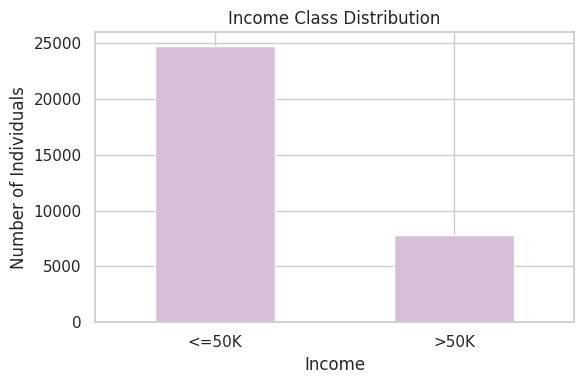

In [ ]:
income_counts = df["income"].value_counts()

plt.figure(figsize=(6,4))
income_counts.plot(kind='bar', color='thistle')

plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Analysis
The target variable (`income`) is moderately imbalanced. Approximately 76% of individuals in the dataset earn 50K or less annually, while about 24% earn more than 50K. Although the imbalance is not severe, it is sufficient to warrant evaluation metrics beyond overall accuracy. During model development, metrics such as precision, recall, F1-score, and ROC-AUC should be considered to ensure that the minority class (>50K) is predicted effectively.

## Investigate Numerical Variables

In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


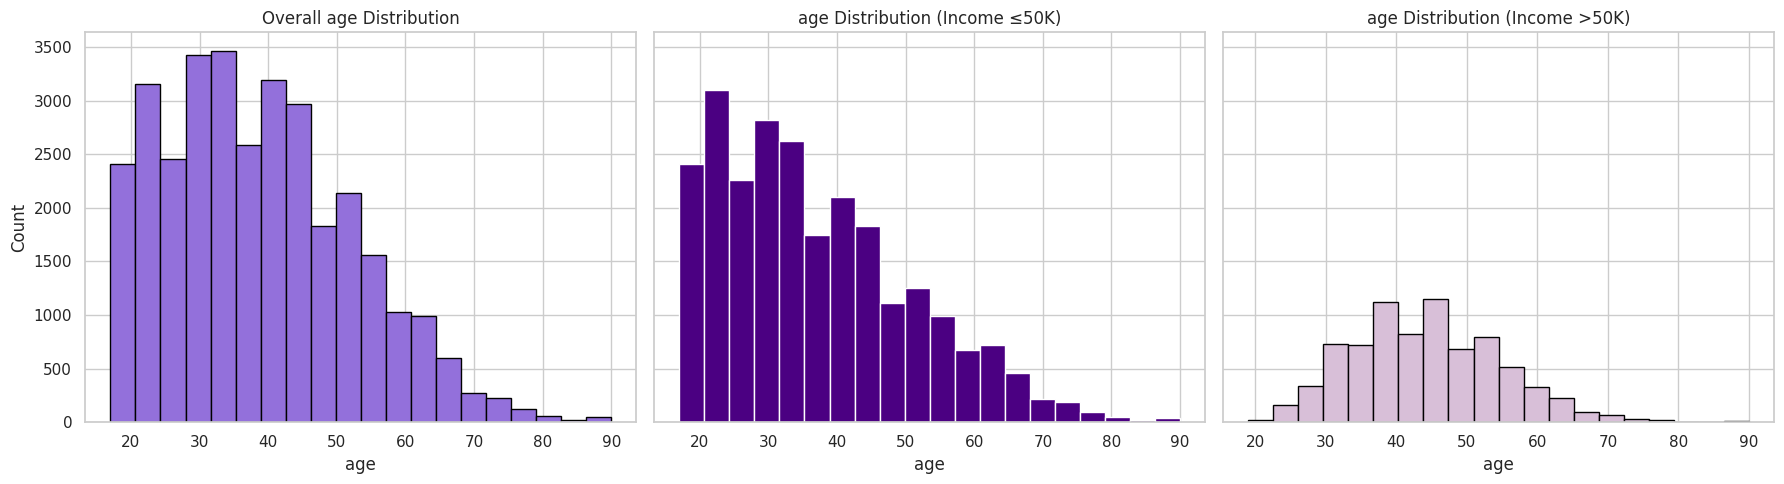

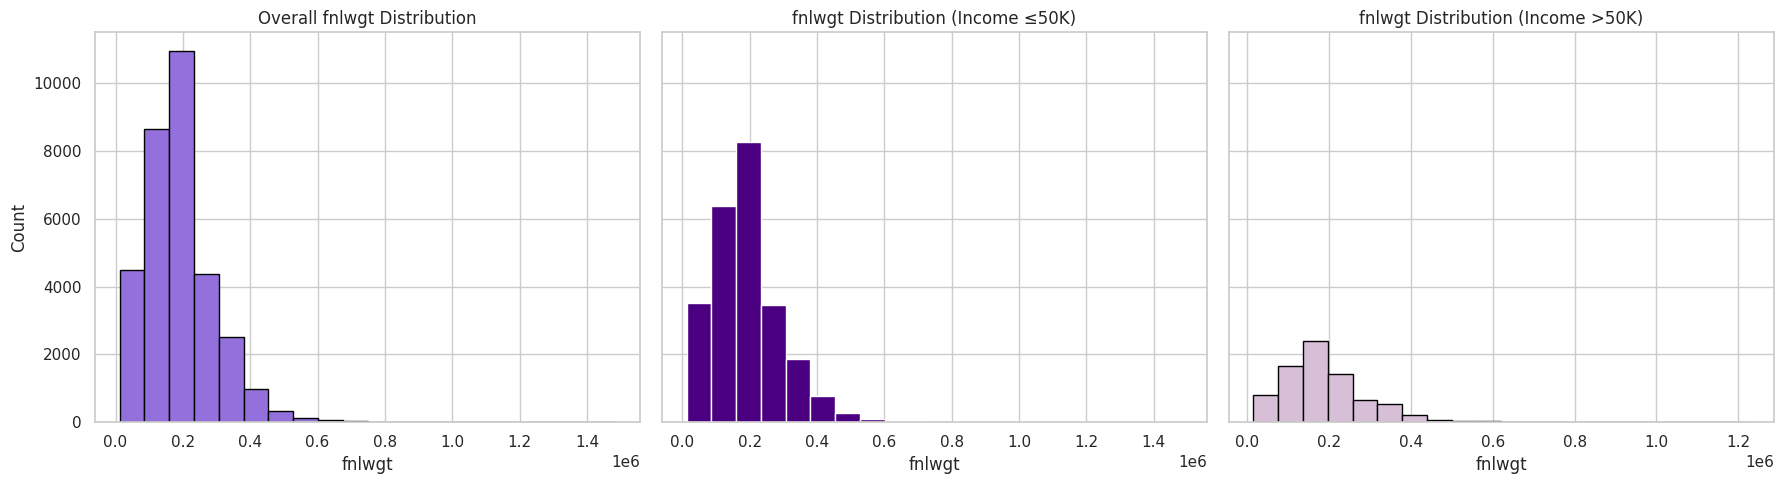

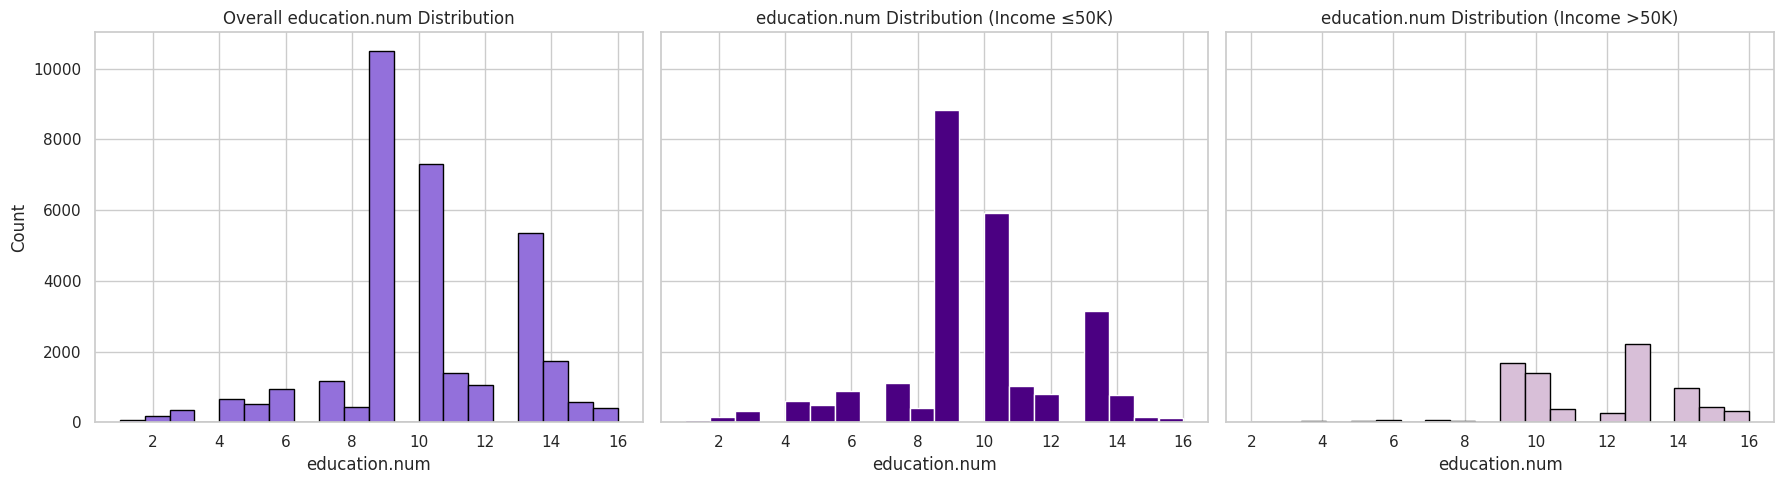

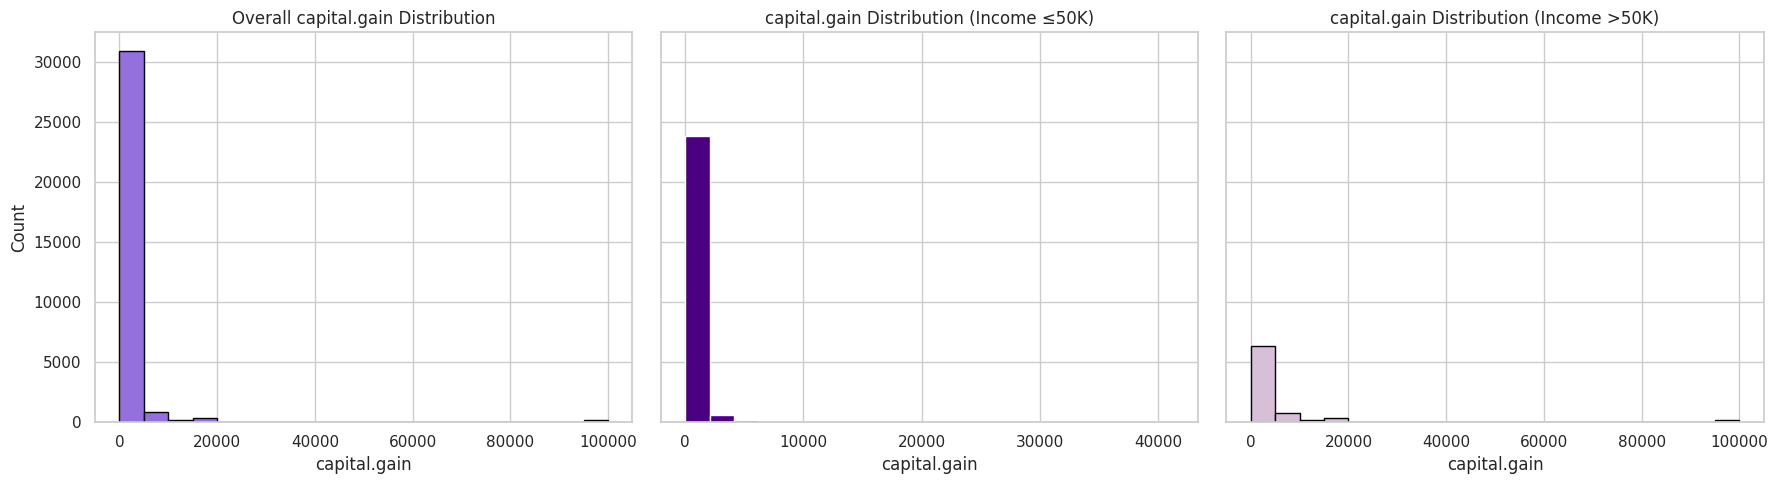

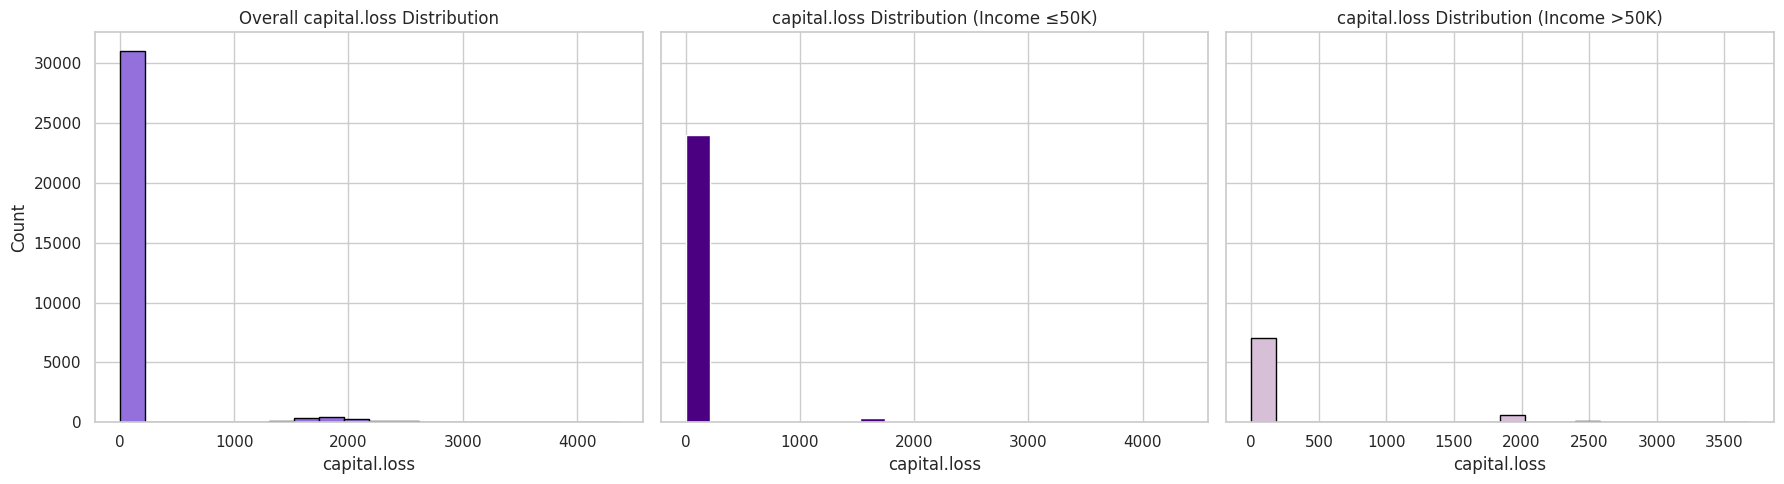

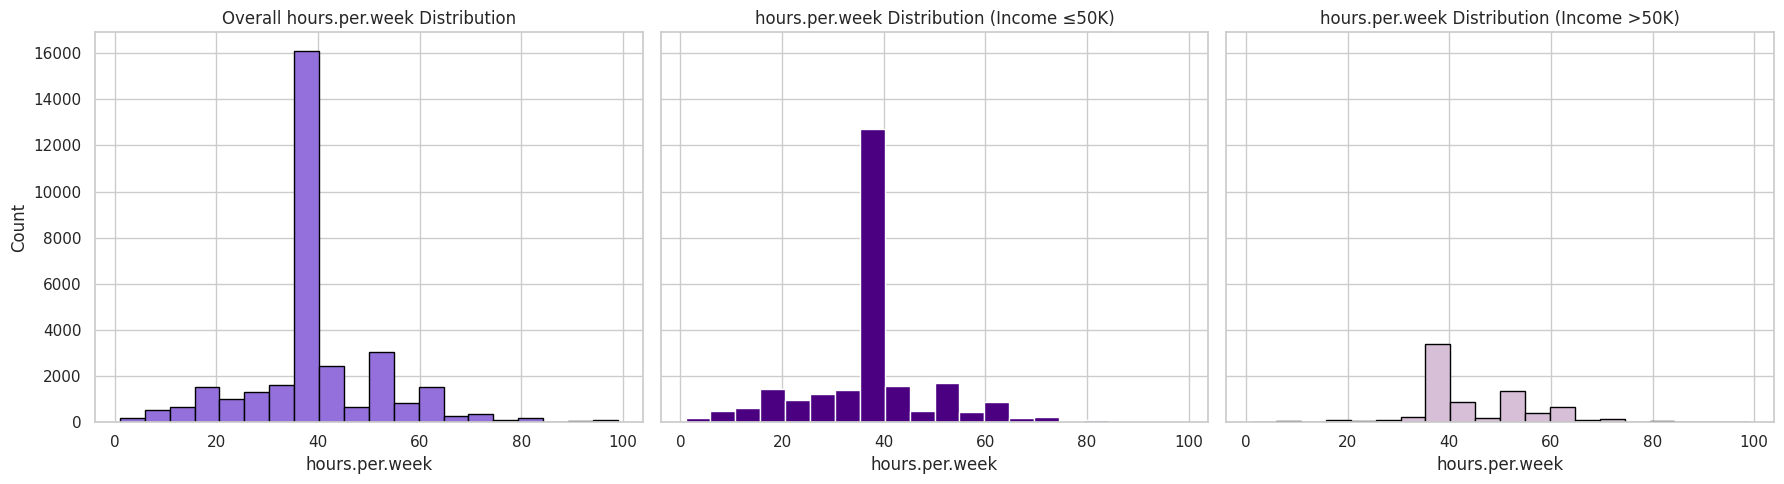

In [ ]:
# Histograms of each numerical variable: overall, with incomes <=50K, and with incomes >50K
numeric_cols = [
    "age",
    "fnlwgt",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

for col in numeric_cols:

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    # Overall
    axes[0].hist(
        df[col],
        bins=20,
        color="mediumpurple",
        edgecolor="black"
    )
    axes[0].set_title(f"Overall {col} Distribution")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    # Income <=50K
    axes[1].hist(
        df[df["income"] == "<=50K"][col],
        bins=20,
        color="indigo",
        edgecolor="white"
    )
    axes[1].set_title(f"{col} Distribution (Income ≤50K)")
    axes[1].set_xlabel(col)

    # Income >50K
    axes[2].hist(
        df[df["income"] == ">50K"][col],
        bins=20,
        color="thistle",
        edgecolor="black"
    )
    axes[2].set_title(f"{col} Distribution (Income >50K)")
    axes[2].set_xlabel(col)

    plt.tight_layout()
    plt.show()

In [ ]:
# Calculate skewness
df[numeric_cols].skew().sort_values(ascending=False)

,0
capital.gain,11.953848
capital.loss,4.594629
fnlwgt,1.446980
age,0.558743
hours.per.week,0.227643
education.num,-0.311676


### age Analysis
The age distribution is moderately right-skewed, with most individuals between 20 and 50 years old. Individuals earning <=$50K are concentrated primarily in their 20 to mid-40s, while those earning >50K are more concentrated between their 30s and mid-50s. This shift suggests that age is positively associated with higher income.

### fnlwgt Analysis
The fnlwgt distributions are all positively skewed, with most observations concentrated between approximately 100,000 and 250,000 and relatively few individuals having very large sampling weights. The distributions for the ≤50K and >50K income groups are very similar in shape, indicating that fnlwgt does not differ substantially across income levels. Because fnlwgt is a census sampling weight rather than a personal characteristic, these results suggest it is unlikely to be a strong predictor of income on its own.

### education.num Analysis
The distribution of education.num is discrete, with most individuals clustered around values 9 (high school graduate), 10–11 (some college/associate education), and 13 (bachelor's degree). Individuals earning ≤$50K are concentrated at lower education levels, particularly around values 9 and 10, while those earning >50K are concentrated at higher education levels, especially around value 13. These distributions indicate a positive relationship between educational attainment and income.

### capital.gain Analysis
The capital.gain variable is extremely right-skewed, with the vast majority of individuals reporting no capital gains and only a small number having very large values. Individuals earning ≤50K almost exclusively have zero or very low capital gains, whereas the >50K group contains a noticeably larger proportion of individuals with positive and higher capital gains.

### capital.loss Analysis
The capital.loss variable is extremely right-skewed, with nearly all individuals reporting no capital losses and only a small number having positive loss values. Individuals earning ≤50K rarely report capital losses, whereas the >50K group contains a noticeably higher proportion of individuals with positive capital losses, particularly around values near 2,000.

### hours.per.week Analysis
The hours.per.week distribution is centered around the standard 40-hour workweek, with a sharp peak at 40 hours and smaller peaks at longer workweeks such as 50 and 60 hours. Individuals earning ≤50K are more concentrated around standard full-time hours, while those earning >$50K are more likely to work longer hours, with a greater proportion working 50 hours or more per week.

### Correlation Matrix

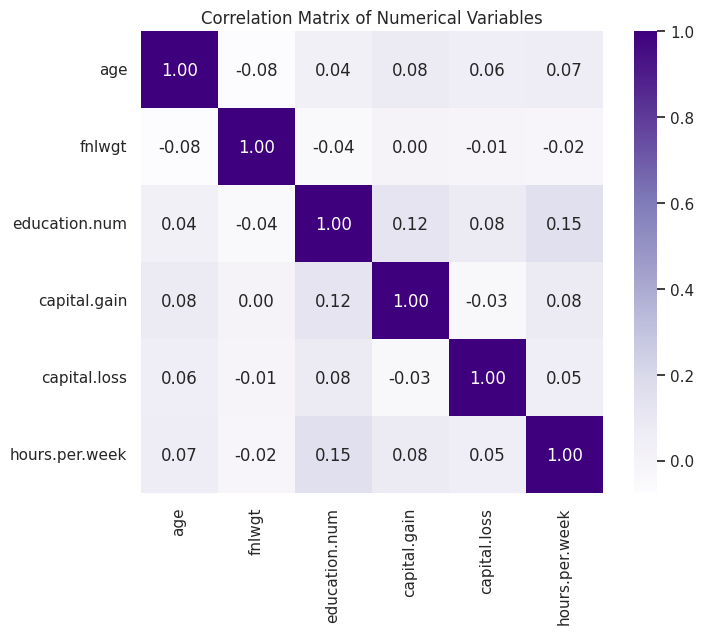

In [ ]:
plt.figure(figsize=(8,6))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="Purples",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

### Correlation Matrix Analysis
The correlation matrix indicates that the numerical variables have generally weak linear relationships with one another, as all off-diagonal correlation coefficients are below 0.20. The low correlations indicate that the numerical features capture largely distinct aspects of an individual's characteristics, reducing concerns about multicollinearity and supporting the inclusion of multiple numerical predictors in the predictive model.

## Investigate Categorical Variables

In [ ]:
categorical_cols = [
    "workclass",
    "education",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native.country"
]

In [ ]:
# Frequency Breakdown of Each Categorical Variable by Income Group
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(col)

    print(
        pd.crosstab(
            df[col],
            df["income"],
            dropna=False
        )
    )


workclass
income            <=50K  >50K
workclass                    
Federal-gov         589   371
Local-gov          1476   617
Never-worked          7     0
Private           17733  4963
Self-emp-inc        494   622
Self-emp-not-inc   1817   724
State-gov           945   353
Without-pay          14     0
NaN                1645   191

education
income        <=50K  >50K
education                
10th            871    62
11th           1115    60
12th            400    33
1st-4th         162     6
5th-6th         317    16
7th-8th         606    40
9th             487    27
Assoc-acdm      802   265
Assoc-voc      1021   361
Bachelors      3134  2221
Doctorate       107   306
HS-grad        8826  1675
Masters         764   959
Preschool        51     0
Prof-school     153   423
Some-college   5904  1387

marital.status
income                 <=50K  >50K
marital.status                    
Divorced                3980   463
Married-AF-spouse         13    10
Married-civ-spouse      

In [ ]:
# Percentage Distribution Within Each Income Group
for col in categorical_cols:
    print(f"\n{'='*60}")
    print(col)

    print(
        (
            pd.crosstab(
                df[col],
                df["income"],
                normalize="columns",
                dropna=False
            ) * 100
        ).round(2)
    )


workclass
income            <=50K   >50K
workclass                     
Federal-gov        2.38   4.73
Local-gov          5.97   7.87
Never-worked       0.03   0.00
Private           71.74  63.30
Self-emp-inc       2.00   7.93
Self-emp-not-inc   7.35   9.23
State-gov          3.82   4.50
Without-pay        0.06   0.00
NaN                6.65   2.44

education
income        <=50K   >50K
education                 
10th           3.52   0.79
11th           4.51   0.77
12th           1.62   0.42
1st-4th        0.66   0.08
5th-6th        1.28   0.20
7th-8th        2.45   0.51
9th            1.97   0.34
Assoc-acdm     3.24   3.38
Assoc-voc      4.13   4.60
Bachelors     12.68  28.33
Doctorate      0.43   3.90
HS-grad       35.70  21.36
Masters        3.09  12.23
Preschool      0.21   0.00
Prof-school    0.62   5.39
Some-college  23.88  17.69

marital.status
income                 <=50K   >50K
marital.status                     
Divorced               16.10   5.90
Married-AF-spouse       0.0

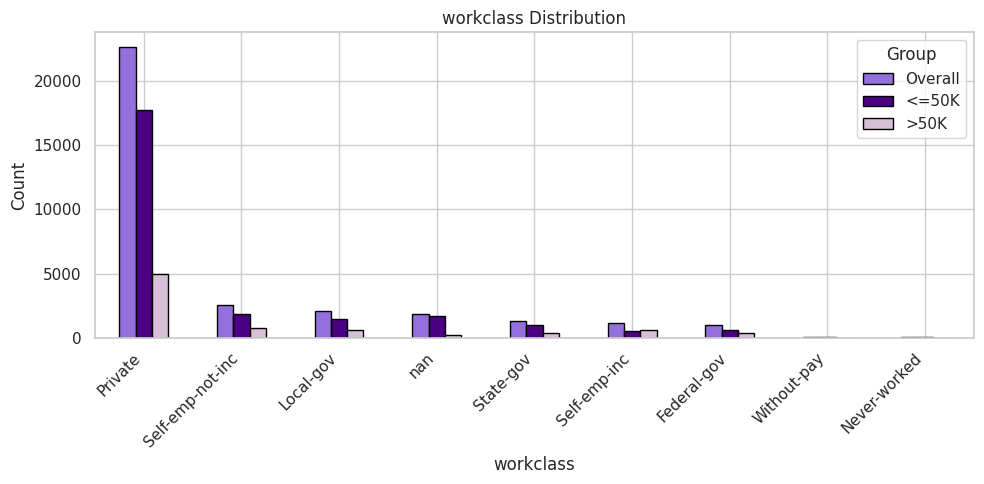

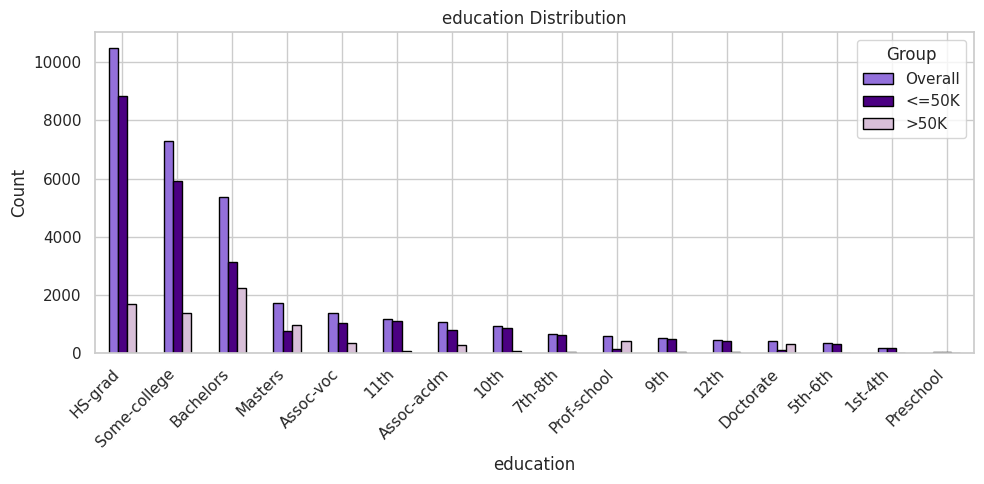

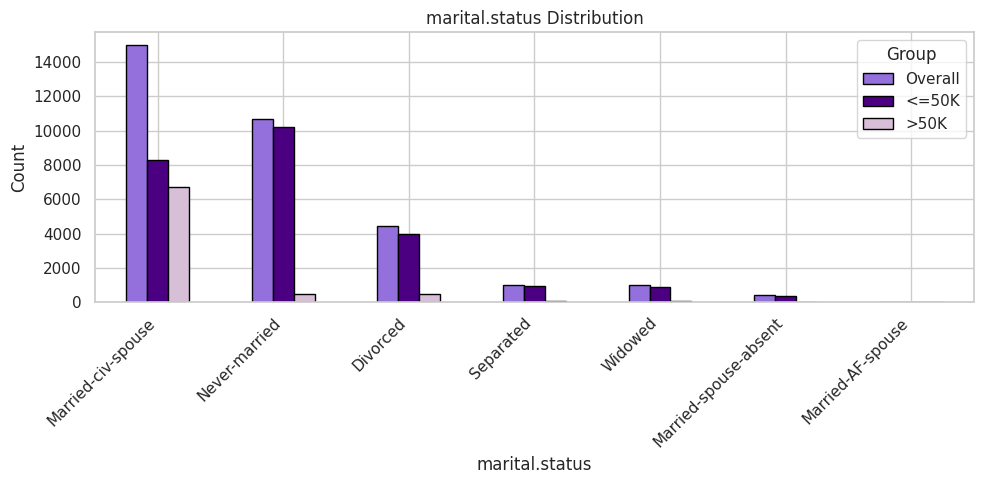

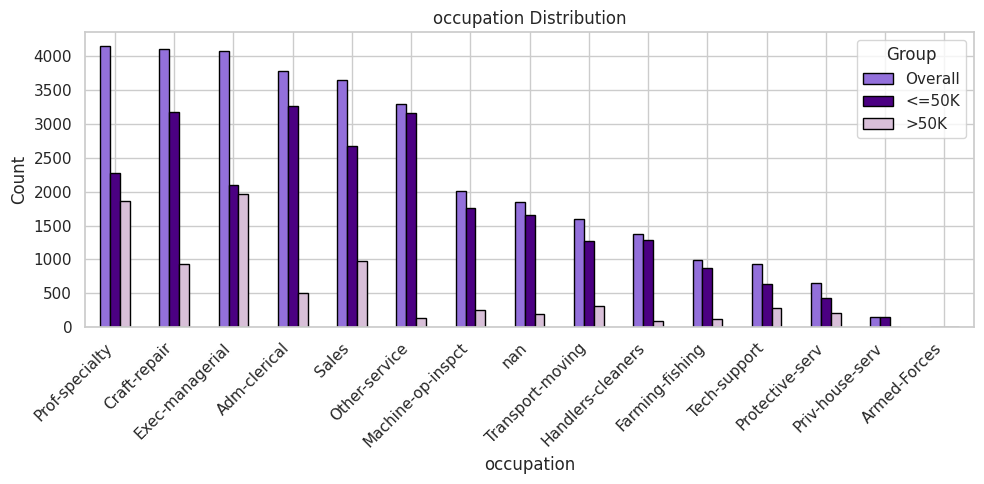

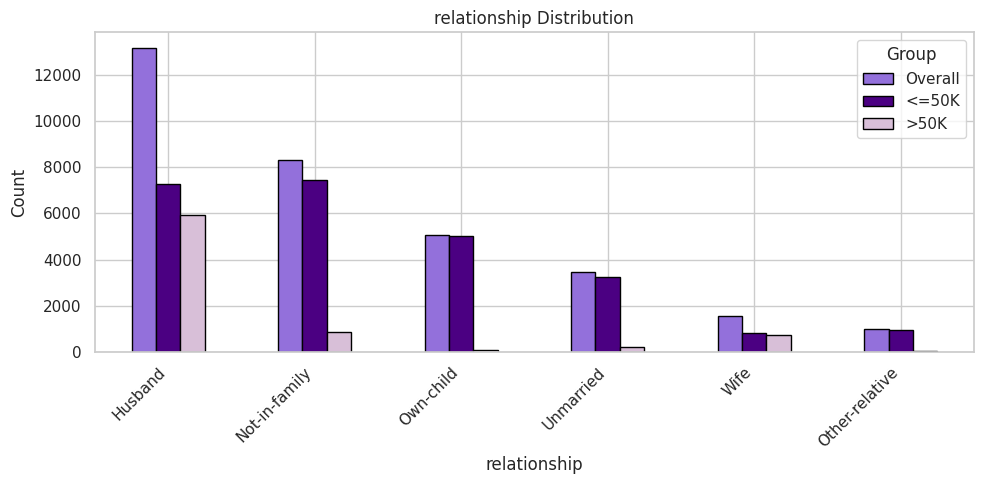

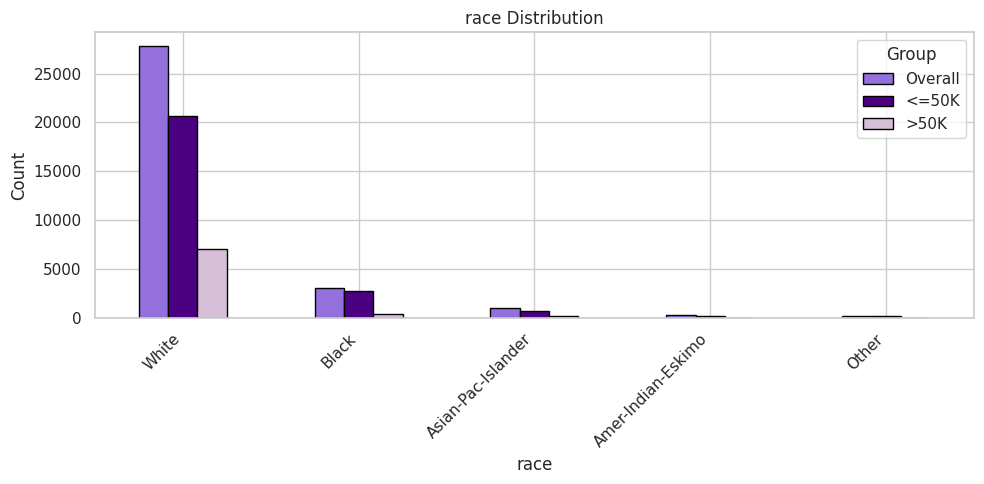

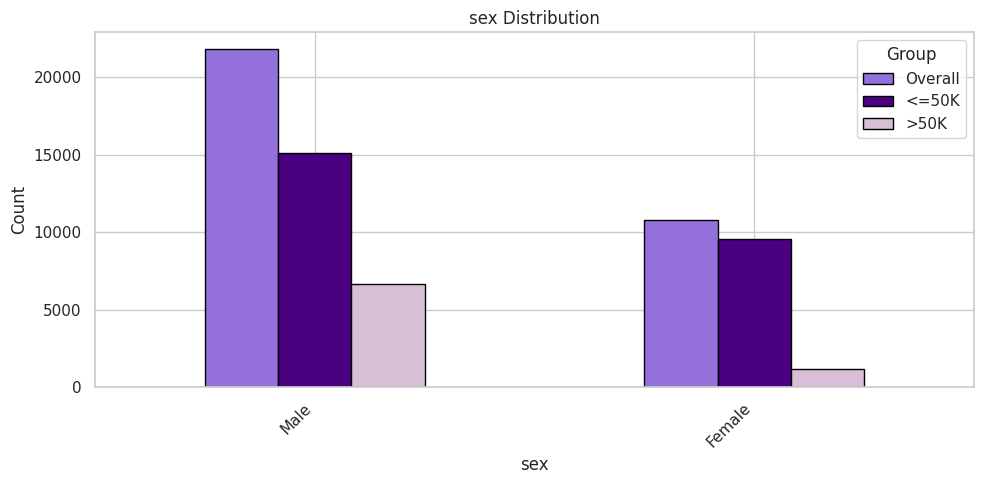

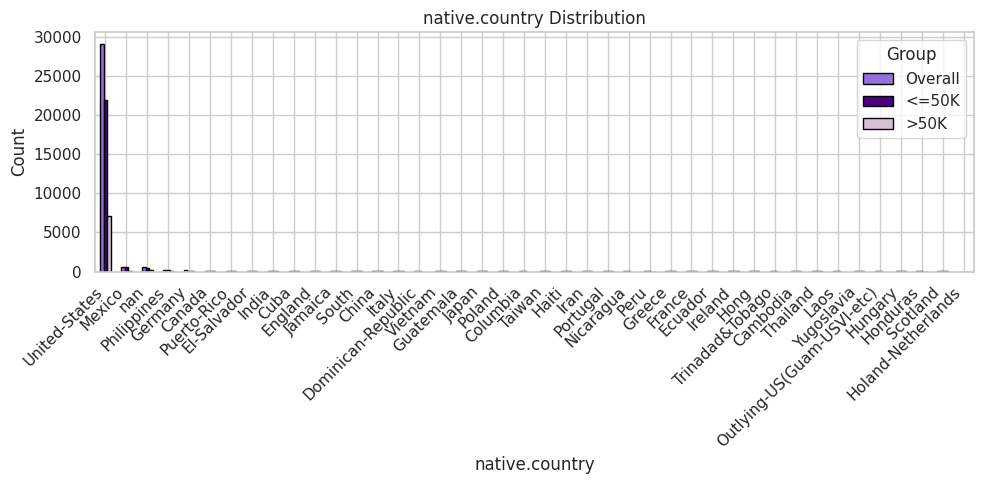

In [ ]:
# Plot categorical variables by income groups
for col in categorical_cols:

    # Overall counts
    overall = df[col].value_counts(dropna=False)

    # Counts by income group
    low_income = (
        df[df["income"] == "<=50K"][col]
        .value_counts(dropna=False)
    )

    high_income = (
        df[df["income"] == ">50K"][col]
        .value_counts(dropna=False)
    )

    # Combine into one DataFrame
    plot_df = pd.concat(
        [overall, low_income, high_income],
        axis=1
    )

    plot_df.columns = ["Overall", "<=50K", ">50K"]
    plot_df = plot_df.fillna(0)

    # Plot
    plot_df.plot(
        kind="bar",
        figsize=(10, 5),
        color=["mediumpurple", "indigo", "thistle"],
        edgecolor="black"
    )

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Group")
    plt.tight_layout()
    plt.show()

### Workclass Analysis
Private-sector employment is the most common work class in both income groups, accounting for the majority of observations. Individuals working in the federal government and self-employed in incorporated businesses are more represented among those earning >50K relative to their overall frequencies. Missing workclass values occur primarily in the lower-income group.

### Education Analysis
High school graduates and individuals with some college make up the largest portion of the lower-income group, while Bachelor's, Master's, Professional School, and Doctorate degree holders are much more common among higher-income individuals. Advanced educational attainment is noticeably associated with earning >50K. Lower levels of education are concentrated in the lower-income group.

### Marital Status Analysis
Married-civilian spouses constitute the largest group among individuals earning >50K, whereas never-married individuals are the largest lower-income group. Divorced, separated, and widowed individuals are also more common among those earning <=50K.

### Occupation Analysis
Executive-managerial and professional specialty occupations have the highest representation among higher-income individuals. Administrative support, service, machine operation, and manual labor occupations are much more concentrated in the lower-income group.

### Relationship Analysis
Individuals identified as husbands make up the majority of the higher-income group, while own-child, not-in-family, and unmarried relationships are primarily found among lower-income earners. Wives are relatively balanced between the two income groups compared to other relationship categories.

### Race Analysis
White individuals comprise the majority of both income groups, reflecting the overall composition of the dataset. Every racial group contains more individuals earning <=50K than >50K, although Asian-Pacific Islanders have a relatively larger proportion of higher-income individuals than several other groups.

### Sex Analysis
Men substantially outnumber women in the higher-income group, while women are much more concentrated among individuals earning <=50K. Although males also make up the majority of the lower-income group, the disparity becomes much larger among higher earners.

### Native Country Analysis
The United States accounts for the overwhelming majority of observations in both income groups, with all other countries contributing relatively small sample sizes. Most countries have considerably more individuals earning <=50K than >50K, though countries such as India, Taiwan, Japan, and Canada show comparatively larger higher-income representation. Because many countries have few observations, native country is likely to be a weaker predictor than variables such as education, occupation, or marital status.


## EDA Summary
The EDA provided a comprehensive understanding of the Adult Census Income dataset and identified several patterns related to income level. Within the target variable, substantially more individuals earn <=50K than those earning >50K. Numerical analyses showed that higher-income individuals generally tend to be older, have more years of education, work more hours per week, and report higher capital gains. The capital.gain and capital.loss variables exhibit strong positive skewness. The correlation analysis showed only weak relationships among the numerical variables, indicating that they capture largely distinct information and present little concern for multicollinearity. Categorical analyses revealed that education, occupation, marital status, relationship, and sex have clear associations with income, whereas race and native country appear to be less discriminative. Overall, the EDA suggests that a combination of numerical and categorical features will be important for predicting income. The findings can be used as a foundation for subsequent data preparation, feature engineering, and model development.

In [ ]:
df_prep = df.copy()
df_prep[["workclass", "occupation", "native.country"]].isnull().sum()



,0
workclass,1836
occupation,1843
native.country,583


In [ ]:
df_prep["workclass"] = df_prep["workclass"].fillna("Unknown")
df_prep["occupation"] = df_prep["occupation"].fillna("Unknown")

df_prep["native.country"] = df_prep["native.country"].fillna(
    df_prep["native.country"].mode()[0]
)

df_prep.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


### Analysis
workclass and occupation are missing in the same rows which are consistent with unemployed or never-worked individuals. This insinuates that this may not be randm. Filling with "Unknown" preserves this information as its own category. native.country is filled with the mode because its missingness is small and heavily skewed toward one value

In [ ]:
df_prep["native.country"].value_counts().head(10)

,count
native.country,
United-States,29753
Mexico,643
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100
Cuba,95


In [ ]:
df_prep["native.country"] = np.where(
    df_prep["native.country"] == "United-States", "United-States", "Other"
)

df_prep["native.country"].value_counts()

,count
native.country,
United-States,29753
Other,2808


In [ ]:
df_prep["marital.status"] = df_prep["marital.status"].replace({
    "Married-AF-spouse": "Married-civ-spouse",
    "Married-spouse-absent": "Separated"
})

df_prep["marital.status"].value_counts()

,count
marital.status,
Married-civ-spouse,14999
Never-married,10683
Divorced,4443
Separated,1443
Widowed,993


## High Cardinality Categories
native.country contains over 40 levels making one-hot encoding inefficient because it would make many sparse columns which most would be too small to be predictors. Sorting between United States and not would align with the EDA and bring better predictive value. marital.status also contains subcategories within umbrella terms that can be condensed without losing its meaning. Condensing rather than using one hot encoding helps us keep the important information without the risk of overfitting.

# Capital Gain and Capital Loss


In [ ]:
df_prep["net.capital"] = df_prep["capital.gain"] - df_prep["capital.loss"]

df_prep["has.capital.change"] = (df_prep["net.capital"] != 0).astype(int)

df_prep[["capital.gain", "capital.loss", "net.capital", "has.capital.change"]].head()

,capital.gain,capital.loss,net.capital,has.capital.change
0,0,4356,-4356,1
1,0,4356,-4356,1
2,0,4356,-4356,1
3,0,3900,-3900,1
4,0,3900,-3900,1


Capital gain and capital loss are usually small and mostly zero so combining the two to create net.capital would condense the sparse data without losing its information. The binary addition also allows for flagging any capital activity.

# Continuous Variables

In [ ]:
df_prep["age.group"] = pd.cut(
    df_prep["age"],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

df_prep["hours.group"] = pd.cut(
    df_prep["hours.per.week"],
    bins=[0, 20, 39, 40, 60, 100],
    labels=["part-time (<=20)", "under-40", "40", "41-60", "60+"]
)

df_prep[["age", "age.group", "hours.per.week", "hours.group"]].head()

,age,age.group,hours.per.week,hours.group
0,90,65+,40,40
1,82,65+,18,part-time (<=20)
2,66,65+,40,40
3,54,46-55,40,40
4,41,36-45,40,40


Binning age and hours.per.week allows us to categorize the nonlinear relationships that these variables have. This will aid for models that assume a linear relationship while still allowing models that handle nonlinearity to use.

# Skewed Features

In [ ]:
from scipy.stats import skew

skew_before = df_prep[["age", "hours.per.week", "net.capital"]].apply(skew)
skew_before

,0
age,0.558718
hours.per.week,0.227632
net.capital,11.871387


In [ ]:
df_prep["net.capital.log"] = np.sign(df_prep["net.capital"]) * np.log1p(
    np.abs(df_prep["net.capital"])
)

skew_after = df_prep[["age", "hours.per.week", "net.capital.log"]].apply(skew)
skew_after

,0
age,0.558718
hours.per.week,0.227632
net.capital.log,1.070800


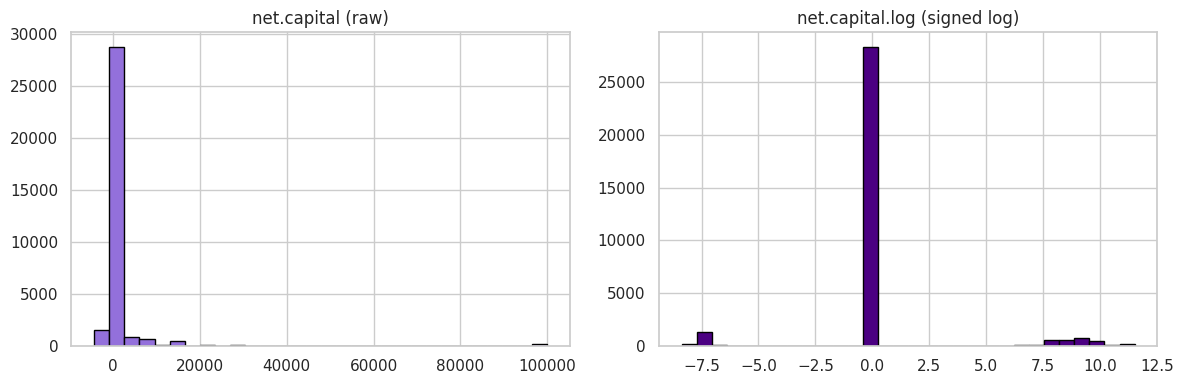

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_prep["net.capital"], bins=30, color="mediumpurple", edgecolor="black")
axes[0].set_title("net.capital (raw)")
axes[1].hist(df_prep["net.capital.log"], bins=30, color="indigo", edgecolor="black")
axes[1].set_title("net.capital.log (signed log)")
plt.tight_layout()
plt.show()

# Analysis
A signed log1p transformation is applied to net.capital reduces the skewness and reduces the number of extreme values that would originally dominate the models.

# Encoding Categorical Variables

In [ ]:
categorical_final = [
    "workclass", "marital.status", "occupation", "relationship",
    "race", "sex", "native.country", "age.group", "hours.group"
]

df_encoded = pd.get_dummies(df_prep, columns=categorical_final, drop_first=True)

df_encoded["income"] = (df_encoded["income"] == ">50K").astype(int)

df_encoded.shape

(32561, 57)

# Analysis
One-hot encoding is used rather than ordinal/label encoding because none of these categorical variables have a natural order. Assigning arbitrary integers would imply a false ranking that may mislead models. income is converted to a binary integer for classification algorithms or standard evaluation metrics.

# Scaling Numeric Features

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_final = ["age", "education.num", "hours.per.week", "net.capital.log"]

scaler = StandardScaler()
df_encoded[numeric_final] = scaler.fit_transform(df_encoded[numeric_final])

df_encoded[numeric_final].describe().round(2)

,age,education.num,hours.per.week,net.capital.log
count,32561.00,32561.00,32561.00,32561.00
mean,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.58,-3.53,-3.19,-2.91
25%,-0.78,-0.42,-0.04,-0.13
50%,-0.12,-0.03,-0.04,-0.13
75%,0.69,0.75,0.37,-0.13
max,3.77,2.30,4.74,3.70


# Analysis
Standardization is applied only to the numeric predictors, not the one-hot-encoded categorical columns. This is important for models such as logistic regression, SVM, or KNN that are sensitive to feature scale — without it, education.num and net.capital.log would contribute unevenly to distance or coefficient calculations. Tree-based models don't strictly need this step, but scaling is done here to keep the dataset usable across multiple model types without a separate preprocessing branch.

# Feature Engineering Summary
Missing values in workclass and occupation were treated as a meaningful "Unknown" category rather than dropped or naively imputed, since their missingness pattern reflects unemployment rather than random noise. Redundant and uninformative columns were removed, and high-cardinality categoricals were consolidated to reduce sparsity. New features were engineered directly from patterns identified in the EDA. The heavily skewed net.capital variable was corrected with a signed log transformation, categorical variables were one-hot encoded, and numeric features were standardized for scale-sensitive models.

# <span style="color:red"> *----- Midpoint work ends here. Final submission work begins here -----* </span>

# Phase 1 — Common Model Evaluation Framework

The prepared dataset `df_encoded` contains the engineered and encoded features from the midpoint analysis. The target variable, `income`, is already encoded as 0 for income <=50K and 1 for income >50K.

For consistent comparison across all four classification models, the same predictors, target, train/test split, cross-validation strategy, and evaluation metrics will be used.

In [ ]:
# Separate predictors and target
X = df_encoded.drop(columns="income")
y = df_encoded["income"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget distribution (%):")
print((y.value_counts(normalize=True) * 100).round(2))

X shape: (32561, 56)
y shape: (32561,)

Target distribution:
income
0    24720
1     7841
Name: count, dtype: int64

Target distribution (%):
income
0    75.92
1    24.08
Name: proportion, dtype: float64


## Phase 0 — Corrections needed to midpoint notebook
The shape is different than what is expected. I'll investigate it.

In [ ]:
print("All columns in df_encoded:")
print(df_encoded.columns.tolist())

print("\nNumber of columns:", len(df_encoded.columns))

print("\nColumns in X:")
print(X.columns.tolist())

All columns in df_encoded:
['age', 'fnlwgt', 'education', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'income', 'net.capital', 'has.capital.change', 'net.capital.log', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Unknown', 'workclass_Without-pay', 'marital.status_Married-civ-spouse', 'marital.status_Never-married', 'marital.status_Separated', 'marital.status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'occupation_Unknown', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relation

In [ ]:
# Check data types in the current modeling dataset
print("Non-numeric columns in X:")
print(X.select_dtypes(exclude="number").columns.tolist())

print("\nNumeric columns:")
print(X.select_dtypes(include="number").columns.tolist())

print("\nNumber of predictors:", X.shape[1])

Non-numeric columns in X:
['education', 'workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Unknown', 'workclass_Without-pay', 'marital.status_Married-civ-spouse', 'marital.status_Never-married', 'marital.status_Separated', 'marital.status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'occupation_Unknown', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White', 'sex_Male', 'native.country_United-States', 

### Findings:
There are problems with the dataset. In the midpoint notebook, categorical_final does not include education, and education is still a string. Also, the one-hot columns are booleans instead of integers.

### 0.1 Preparing and encoding `education`

In [ ]:
# Education distribution
education_dist = (
    df["education"]
    .value_counts(dropna=False)
    .rename_axis("education")
    .reset_index(name="count")
)

education_dist["percent"] = (
    education_dist["count"] / len(df) * 100
).round(2)

education_dist

,education,count,percent
0,HS-grad,10501,32.25
1,Some-college,7291,22.39
2,Bachelors,5355,16.45
3,Masters,1723,5.29
4,Assoc-voc,1382,4.24
5,11th,1175,3.61
6,Assoc-acdm,1067,3.28
7,10th,933,2.87
8,7th-8th,646,1.98
9,Prof-school,576,1.77


In [ ]:
# Education distribution by income
education_income = pd.crosstab(
    df["education"],
    df["income"],
    margins=True
)

education_income

income,<=50K,>50K,All
education,,,
10th,871,62,933
11th,1115,60,1175
12th,400,33,433
1st-4th,162,6,168
5th-6th,317,16,333
7th-8th,606,40,646
9th,487,27,514
Assoc-acdm,802,265,1067
Assoc-voc,1021,361,1382


In [ ]:
# Income rate within each education category
education_income_rate = (
    pd.crosstab(
        df["education"],
        df["income"],
        normalize="index"
    ) * 100
).round(2)

education_income_rate["Total"] = (
    df["education"].value_counts()
)

education_income_rate.sort_values(
    ">50K",
    ascending=False
)

income,<=50K,>50K,Total
education,,,
Doctorate,25.91,74.09,413
Prof-school,26.56,73.44,576
Masters,44.34,55.66,1723
Bachelors,58.52,41.48,5355
Assoc-voc,73.88,26.12,1382
Assoc-acdm,75.16,24.84,1067
Some-college,80.98,19.02,7291
HS-grad,84.05,15.95,10501
12th,92.38,7.62,433


In [ ]:
education_summary = pd.DataFrame({
    "count": df["education"].value_counts(),
    "percent": df["education"].value_counts(normalize=True) * 100,
    "pct_over_50k": (
        pd.crosstab(
            df["education"],
            df["income"],
            normalize="index"
        )[" >50K" if " >50K" in df["income"].unique() else ">50K"]
        * 100
    )
})

education_summary = education_summary.round(2)
education_summary = education_summary.sort_values("pct_over_50k", ascending=False)

education_summary

,count,percent,pct_over_50k
education,,,
Doctorate,413,1.27,74.09
Prof-school,576,1.77,73.44
Masters,1723,5.29,55.66
Bachelors,5355,16.45,41.48
Assoc-voc,1382,4.24,26.12
Assoc-acdm,1067,3.28,24.84
Some-college,7291,22.39,19.02
HS-grad,10501,32.25,15.95
12th,433,1.33,7.62


In [ ]:
# Create grouped education feature
education_mapping = {
    "Preschool": "Below-HS",
    "1st-4th": "Below-HS",
    "5th-6th": "Below-HS",
    "7th-8th": "Below-HS",
    "9th": "Below-HS",
    "10th": "Below-HS",
    "11th": "Below-HS",
    "12th": "Below-HS",
    "HS-grad": "HS-grad",
    "Some-college": "Some-college",
    "Assoc-voc": "Some-college",
    "Assoc-acdm": "Some-college",
    "Bachelors": "Bachelors",
    "Masters": "Masters",
    "Prof-school": "Graduate/Professional",
    "Doctorate": "Graduate/Professional"
}

df_model = df_encoded.copy()

# Recover education from the original df because df_encoded
# no longer contains it as a categorical column.
df_model["education"] = df["education"]

df_model["education.group"] = df_model["education"].map(education_mapping)

In [ ]:
print(
    df_model["education.group"]
    .value_counts()
)

print("\nIncome rate by education group:")
print(
    df_model.groupby("education.group")["income"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

education.group
HS-grad                  10501
Some-college              9740
Bachelors                 5355
Below-HS                  4253
Masters                   1723
Graduate/Professional      989
Name: count, dtype: int64

Income rate by education group:
education.group
Graduate/Professional    73.71
Masters                  55.66
Bachelors                41.48
Some-college             20.67
HS-grad                  15.95
Below-HS                  5.74
Name: income, dtype: float64


### Notes:
Education was consolidated from 16 detailed categories into 6 groups based on observed income patterns, reducing sparse categories while preserving meaningful differences in income attainment.

### Create the engineered feature and encode `education.group`

In [ ]:
# Start from the frozen midpoint dataset
df_model = df_encoded.copy()

# Bring the original education variable back from df
df_model["education"] = df["education"]

# Create grouped education feature
education_mapping = {
    "Preschool": "Below-HS",
    "1st-4th": "Below-HS",
    "5th-6th": "Below-HS",
    "7th-8th": "Below-HS",
    "9th": "Below-HS",
    "10th": "Below-HS",
    "11th": "Below-HS",
    "12th": "Below-HS",
    "HS-grad": "HS-grad",
    "Some-college": "Some-college",
    "Assoc-voc": "Some-college",
    "Assoc-acdm": "Some-college",
    "Bachelors": "Bachelors",
    "Masters": "Masters",
    "Prof-school": "Graduate/Professional",
    "Doctorate": "Graduate/Professional"
}

df_model["education.group"] = df_model["education"].map(education_mapping)

# Remove the original education variable
df_model = df_model.drop(columns="education")

# Verify
print("df_model shape:", df_model.shape)

print("\nEducation groups:")
print(df_model["education.group"].value_counts())

print("\nMissing education groups:")
print(df_model["education.group"].isna().sum())

df_model shape: (32561, 57)

Education groups:
education.group
HS-grad                  10501
Some-college              9740
Bachelors                 5355
Below-HS                  4253
Masters                   1723
Graduate/Professional      989
Name: count, dtype: int64

Missing education groups:
0


In [ ]:
df_model = pd.get_dummies(
    df_model,
    columns=["education.group"],
    drop_first=True
)

print("df_model shape:", df_model.shape)

print("\nEducation dummy columns:")
print([
    col for col in df_model.columns
    if col.startswith("education.group_")
])

df_model shape: (32561, 61)

Education dummy columns:
['education.group_Below-HS', 'education.group_Graduate/Professional', 'education.group_HS-grad', 'education.group_Masters', 'education.group_Some-college']


### Evaluate whether to retain `education.num` alongside the new `education.group` variables

In [ ]:
print("Education-related columns:")
print([
    col for col in df_model.columns
    if col == "education.num" or col.startswith("education.group_")
])

Education-related columns:
['education.num', 'education.group_Below-HS', 'education.group_Graduate/Professional', 'education.group_HS-grad', 'education.group_Masters', 'education.group_Some-college']


In [ ]:
# Check the relationship between education.num and education.group
education_check_df = df[["education", "education.num"]].copy()

education_check_df["education.group"] = (
    education_check_df["education"].map(education_mapping)
)

education_check = (
    education_check_df.groupby("education.group")["education.num"]
    .agg(["min", "max", "mean", "count"])
    .round(2)
)

education_check

,min,max,mean,count
education.group,,,,
Bachelors,13,13,13.00,5355
Below-HS,1,8,5.60,4253
Graduate/Professional,15,16,15.42,989
HS-grad,9,9,9.00,10501
Masters,14,14,14.00,1723
Some-college,10,12,10.36,9740


### Analysis
This confirms that the `education.group` buckets correspond exactly to specific `education.num` values. There is redundant information here. For example, education.num = 13 tells the model someone is at the Bachelor's level, while education.group_Bachelors = 1 says essentially the same thing. We are good to remove `education.num` and use `education.group` to allow logistic regression to estimate a distinct effect for each education tier rather than a single linear effect across `education.num`.

In [ ]:
df_model = df_model.drop(columns="education.num")

print("education-related columns:")
print([
    col for col in df_model.columns
    if col.startswith("education.group_")
])

education-related columns:
['education.group_Below-HS', 'education.group_Graduate/Professional', 'education.group_HS-grad', 'education.group_Masters', 'education.group_Some-college']


### 0.1 Summary
Education was transformed from 16 original categories into six groups based on observed income rates. The resulting categorical representation was retained for modeling, while education.num was removed to avoid redundant encoding of the same underlying education attainment.

### 0.2 Changing the one-hot columns from booleans to integers

In [ ]:
# Check the data types of the one-hot encoded columns
bool_columns = df_model.select_dtypes(include="bool").columns

print("Number of Boolean columns:", len(bool_columns))
print("\nBoolean columns:")
print(bool_columns.tolist())

Number of Boolean columns: 51

Boolean columns:
['workclass_Local-gov', 'workclass_Never-worked', 'workclass_Private', 'workclass_Self-emp-inc', 'workclass_Self-emp-not-inc', 'workclass_State-gov', 'workclass_Unknown', 'workclass_Without-pay', 'marital.status_Married-civ-spouse', 'marital.status_Never-married', 'marital.status_Separated', 'marital.status_Widowed', 'occupation_Armed-Forces', 'occupation_Craft-repair', 'occupation_Exec-managerial', 'occupation_Farming-fishing', 'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct', 'occupation_Other-service', 'occupation_Priv-house-serv', 'occupation_Prof-specialty', 'occupation_Protective-serv', 'occupation_Sales', 'occupation_Tech-support', 'occupation_Transport-moving', 'occupation_Unknown', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White', 'sex_Male', 'native.country_United-

In [ ]:
# Verify the values in the Boolean one-hot columns
bool_values = pd.unique(
    df_model[bool_columns].values.ravel()
)

print("Unique values in Boolean columns:")
print(bool_values)

Unique values in Boolean columns:
[False  True]


In [ ]:
# Convert Boolean one-hot columns from True/False to 1/0
df_model[bool_columns] = df_model[bool_columns].astype(int)

print("Number of Boolean columns remaining:",
      len(df_model.select_dtypes(include="bool").columns))

print("\nData types of converted columns:")
print(df_model[bool_columns].dtypes.value_counts())

Number of Boolean columns remaining: 0

Data types of converted columns:
int64    51
Name: count, dtype: int64


In [ ]:
print("Object columns:")
print(df_model.select_dtypes(include="object").columns.tolist())

print("\nBoolean columns:")
print(df_model.select_dtypes(include="bool").columns.tolist())

print("\nData types:")
print(df_model.dtypes.value_counts())

Object columns:
[]

Boolean columns:
[]

Data types:
int64      57
float64     3
Name: count, dtype: int64


In [ ]:
float_columns = df_model.select_dtypes(include="float64").columns

print("Float64 columns:")
print(float_columns.tolist())

print("\nNumber of float64 columns:", len(float_columns))

Float64 columns:
['age', 'hours.per.week', 'net.capital.log']

Number of float64 columns: 3


## 1.1 Final Modeling Dataset
### Rationale

The midpoint dataset was further prepared for model development by consolidating the original `education` categories into six groups based on their observed relationship with income. The categorical features were one-hot encoded, and Boolean dummy variables were converted to integer values so that all predictors use a consistent numeric representation. The target variable, `income`, was separated from the predictors for classification modeling.

In [ ]:
# Separate predictors and target
X_model = df_model.drop(columns="income")
y = df_model["income"]

print("X_model shape:", X_model.shape)
print("y shape:", y.shape)

print("\nTarget name:", y.name)
print("Target dtype:", y.dtype)

print("\nTarget values:")
print(y.unique())

print("\nNumber of predictors:", X_model.shape[1])

X_model shape: (32561, 59)
y shape: (32561,)

Target name: income
Target dtype: int64

Target values:
[0 1]

Number of predictors: 59


In [ ]:
print("Missing values in X_model:", X_model.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

print("\nNon-numeric columns:")
print(X_model.select_dtypes(exclude="number").columns.tolist())

print("\nTarget values:")
print(sorted(y.unique()))

print("\nFinal shapes:")
print("X_model:", X_model.shape)
print("y:", y.shape)

Missing values in X_model: 0
Missing values in y: 0

Non-numeric columns:
[]

Target values:
[np.int64(0), np.int64(1)]

Final shapes:
X_model: (32561, 59)
y: (32561,)


### Analysis

The resulting modeling dataset contains 32,561 observations and 59 predictors with no missing values or non-numeric variables. The target variable contains two classes, representing income of `<=50K` and `>50K`, with the original class distribution preserved. This finalized dataset provides a consistent foundation for evaluating all four classification models under the same modeling and validation framework.

## 1.2 Train/Test Split
### Rationale

A stratified 80/20 train/test split is used to separate the data available for model development from an independent holdout set for final evaluation. Stratification preserves the existing income-class proportions in both subsets, which is appropriate given the moderate class imbalance identified during the midpoint analysis. A fixed `random_state=42` ensures that all four models use the same training and holdout observations for consistent comparison.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training set shape: (26048, 59)
Test set shape: (6513, 59)

Training target distribution:
income
0    75.92
1    24.08
Name: proportion, dtype: float64

Test target distribution:
income
0    75.93
1    24.07
Name: proportion, dtype: float64


### Analysis

The stratified split produced 26,048 training observations (80%) and 6,513 holdout test observations (20%), with all 59 predictors retained in both sets. The income-class distribution was preserved almost exactly: the training set contains 75.92% `<=50K` and 24.08% `>50K`, while the test set contains 75.93% and 24.07%, respectively. This confirms that stratification successfully maintained the original class balance and provides a consistent holdout set for final evaluation of all four models.

## 1.3 Cross-Validation Strategy
### Rationale
Five-fold stratified cross-validation will be used during model development to provide a more reliable estimate of model performance than a single training split. Each fold preserves the income-class distribution, which is appropriate for the project's moderately imbalanced binary target. The same folds and random seed will be used for Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting so that model performance can be compared consistently.

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:", cv)
print("Number of folds:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

Cross-validation strategy: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
Number of folds: 5
Shuffle: True
Random state: 42


### Analysis

The cross-validation framework is configured to use **5 stratified folds**, with shuffling enabled and `random_state=42`. This means each fold maintains a similar proportion of the two income classes while shuffling the observations before creating the folds. Using the same fixed configuration for all four models will provide a consistent basis for comparing their cross-validation performance.

## 1.4 Evaluation Metrics
### Rationale

Because the target variable is moderately imbalanced, accuracy alone may not adequately describe model performance. The common evaluation framework will therefore report accuracy, precision, recall, F1 score, and ROC-AUC for every model. F1 and ROC-AUC will receive greater emphasis because the midpoint analysis identified the need to evaluate performance on the minority >50K class rather than relying on overall accuracy alone.

In [ ]:
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("Evaluation metrics:")
for metric in scoring:
    print("-", metric)

Evaluation metrics:
- accuracy
- precision
- recall
- f1
- roc_auc


### Analysis

The common evaluation framework now includes five metrics: **accuracy, precision, recall, F1, and ROC-AUC**. This provides both an overall measure of classification accuracy and measures focused on the `>50K` class, allowing us to evaluate different aspects of model performance consistently across all four models.

## 1.5 Common Evaluation Functions
### Rationale
Reusable evaluation functions will apply the same cross-validation and holdout evaluation procedures to all four classification models without imposing the same preprocessing on every algorithm. Model-specific preprocessing, such as standardization for Logistic Regression, will remain inside the individual model pipeline, while the evaluation functions will use the common cross-validation strategy and evaluation metrics established in Sections 1.3 and 1.4.

In [ ]:
# CV evaluation function

from sklearn.model_selection import cross_validate

def evaluate_model_cv(model, X_train, y_train, cv=cv):
    """
    Evaluate a classification model using the team's
    common 5-fold StratifiedKFold cross-validation framework.

    Any model-specific preprocessing should be included
    inside the model pipeline passed to this function.
    """

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    summary = {
        "Accuracy": cv_results["test_accuracy"].mean(),
        "Precision": cv_results["test_precision"].mean(),
        "Recall": cv_results["test_recall"].mean(),
        "F1": cv_results["test_f1"].mean(),
        "ROC-AUC": cv_results["test_roc_auc"].mean()
    }

    return cv_results, summary

In [ ]:
# Holdout evaluation function

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model_test(model, X_train, y_train, X_test, y_test):
    """
    Fit a model on the full training set and evaluate it
    on the untouched holdout test set.

    Any model-specific preprocessing should be included
    inside the model pipeline passed to this function.
    """

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = None

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

    if y_prob is not None:
        results["ROC-AUC"] = roc_auc_score(y_test, y_prob)

    return results, y_pred, y_prob

The functions now accept any model:

Logistic Regression

X_train -> StandardScaler -> Logistic Regression

while:

Decision Tree

X_train -> Decision Tree

and likewise for Random Forest and Gradient Boosting

In [ ]:
print("CV evaluation function:", callable(evaluate_model_cv))
print("Holdout evaluation function:", callable(evaluate_model_test))

CV evaluation function: True
Holdout evaluation function: True


In [ ]:
# Test with the logistic regression pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_test_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

cv_results_test, cv_summary_test = evaluate_model_cv(
    logistic_test_pipeline,
    X_train,
    y_train
)

test_results_test, y_pred_test, y_prob_test = evaluate_model_test(
    logistic_test_pipeline,
    X_train,
    y_train,
    X_test,
    y_test
)

print("CV Summary:")
for metric, value in cv_summary_test.items():
    print(f"{metric}: {value:.4f}")

print("\nHoldout Test Results:")
for metric, value in test_results_test.items():
    print(f"{metric}: {value:.4f}")

print("\nPrediction shape:", y_pred_test.shape)
print("Probability shape:", y_prob_test.shape)

CV Summary:
Accuracy: 0.8582
Precision: 0.7480
Recall: 0.6203
F1: 0.6781
ROC-AUC: 0.9148

Holdout Test Results:
Accuracy: 0.8589
Precision: 0.7502
Recall: 0.6205
F1: 0.6792
ROC-AUC: 0.9086

Prediction shape: (6513,)
Probability shape: (6513,)


### Analysis

The common evaluation functions successfully evaluated a Logistic Regression pipeline using the established 5-fold StratifiedKFold and holdout test procedures. Standardization was applied within the Logistic Regression pipeline, which resolved the earlier convergence warning while leaving the shared modeling dataset unchanged. The evaluation produced consistent cross-validation and holdout results, with similar performance across all reported metrics and predictions generated for all 6,513 holdout observations. The framework is therefore ready to be applied consistently to Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting.

# Phase 2 — Logistic Regression
## 2.1 — Model Setup
### Rationale

Logistic Regression is used as an interpretable baseline classification model for predicting whether an individual earns more than $50,000. Because the predictors are on different scales, StandardScaler will be included inside the Logistic Regression pipeline so that scaling is learned only from the training data during cross-validation and model fitting. The model will use the same training data, cross-validation framework, and evaluation metrics established in Phase 1.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print(logistic_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic',
                 LogisticRegression(max_iter=1000, random_state=42))])


### Analysis

The Logistic Regression model was configured within a pipeline that applies `StandardScaler` before model fitting. This approach keeps the scaling step within the modeling workflow and ensures that the transformation is learned from the training data rather than applied to the entire dataset in advance. The Logistic Regression estimator is configured with a maximum of 1,000 iterations and a fixed random state of 42 for reproducibility.

## 2.2 — Cross-Validation Evaluation

In [ ]:
# Evaluate Logistic Regression using 5-fold stratified cross-validation
logistic_cv_results, logistic_cv_summary = evaluate_model_cv(
    logistic_model,
    X_train,
    y_train
)

print("Logistic Regression — 5-Fold CV Results:")
for metric, value in logistic_cv_summary.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression — 5-Fold CV Results:
Accuracy: 0.8582
Precision: 0.7480
Recall: 0.6203
F1: 0.6781
ROC-AUC: 0.9148


### Analysis

The Logistic Regression model achieved a mean 5-fold cross-validation accuracy of 85.82%, with precision of 74.80%, recall of 62.03%, and F1 score of 67.81%. The model achieved a ROC-AUC of 91.48%, indicating strong overall discrimination between the <=50K and >50K income classes. The results provide a baseline for comparing Logistic Regression with the other classification models under the same stratified cross-validation framework.

## 2.3 — Holdout Test Evaluation

In [ ]:
# Final Logistic Regression evaluation on the holdout test set
logistic_test_results, logistic_y_pred, logistic_y_prob = evaluate_model_test(
    logistic_model,
    X_train,
    y_train,
    X_test,
    y_test
)

print("Logistic Regression — Holdout Test Results:")
for metric, value in logistic_test_results.items():
    print(f"{metric}: {value:.4f}")

Logistic Regression — Holdout Test Results:
Accuracy: 0.8589
Precision: 0.7502
Recall: 0.6205
F1: 0.6792
ROC-AUC: 0.9086


### Analysis

The Logistic Regression model achieved 85.89% accuracy, 75.02% precision, 62.05% recall, and an F1 score of 67.92% on the holdout test set. The ROC-AUC of 90.86% indicates that the model has strong ability to distinguish between the <=50K and >50K income classes. The holdout results are very close to the 5-fold cross-validation results, suggesting that model performance is relatively consistent and that there is no substantial indication of overfitting.

### Model Performance Summary

| Model | CV Accuracy | CV Precision | CV Recall | CV F1 | CV ROC-AUC | Test Accuracy | Test Precision | Test Recall | Test F1 | Test ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8582 | 0.7480 | 0.6203 | 0.6781 | 0.9148 | 0.8589 | 0.7502 | 0.6205 | 0.6792 | 0.9086 |
| Decision Tree | — | — | — | — | — | — | — | — | — | — |
| Random Forest | — | — | — | — | — | — | — | — | — | — |
| Gradient Boosting | — | — | — | — | — | — | — | — | — | — |

## 2.4 — Confusion Matrix
### Rationale
A confusion matrix will be used to examine the types of classification errors made by the Logistic Regression model on the holdout test set. It separates true positives, true negatives, false positives, and false negatives, providing more detail than aggregate metrics and showing how effectively the model identifies individuals earning more than $50K.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
logistic_cm = confusion_matrix(y_test, logistic_y_pred)

print("Logistic Regression — Confusion Matrix:")
print(logistic_cm)

Logistic Regression — Confusion Matrix:
[[4621  324]
 [ 595  973]]


### Analysis

The confusion matrix shows that the Logistic Regression model correctly classified 4,621 individuals earning <=50K and 973 individuals earning >50K. The model produced 324 false positives and 595 false negatives, meaning it missed more >50K individuals than it incorrectly classified as >50K. This pattern is consistent with the model's 62.05% recall on the holdout set and indicates that identifying the minority >50K class remains more difficult than classifying the majority class.

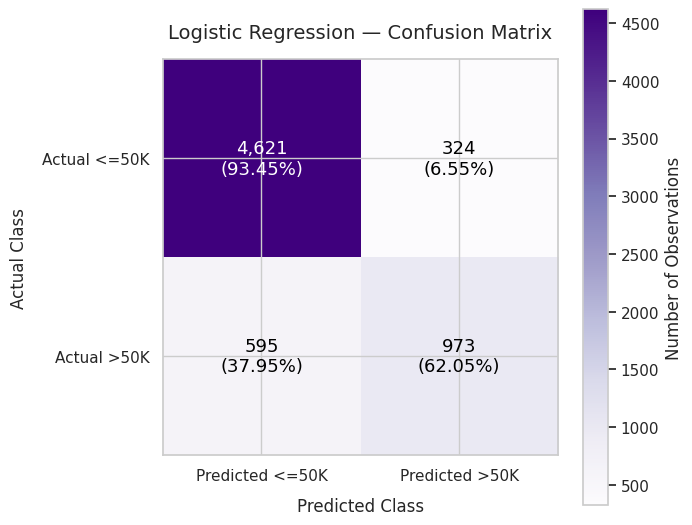

In [ ]:
# Visualize the Logistic Regression confusion matrix
import numpy as np
import matplotlib.pyplot as plt

# Confusion matrix values
cm = logistic_cm

# Calculate percentages within each actual class
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
fig, ax = plt.subplots(figsize=(7, 6))

# Heatmap
im = ax.imshow(cm, cmap="Purples")

# Add counts and percentages
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Use white text for the dark top-left quadrant
        text_color = "white" if (i == 0 and j == 0) else "black"
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}\n({cm_percent[i, j]:.2f}%)",
            ha="center",
            va="center",
            fontsize=13,
            color=text_color
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Predicted <=50K", "Predicted >50K"])
ax.set_yticklabels(["Actual <=50K", "Actual >50K"])

ax.set_title("Logistic Regression — Confusion Matrix", fontsize=14, pad=15)

ax.set_xlabel("Predicted Class", labelpad=10)
ax.set_ylabel("Actual Class", labelpad=10)

# Colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of Observations")

plt.tight_layout()
plt.show()

## 2.5 — ROC Curve
### Rationale

The ROC curve evaluates how well Logistic Regression distinguishes between the <=50K and >50K income classes across different classification thresholds. It complements the single-threshold metrics by showing the tradeoff between the true-positive rate and false-positive rate, while the area under the curve (ROC-AUC) provides a threshold-independent measure of discrimination.

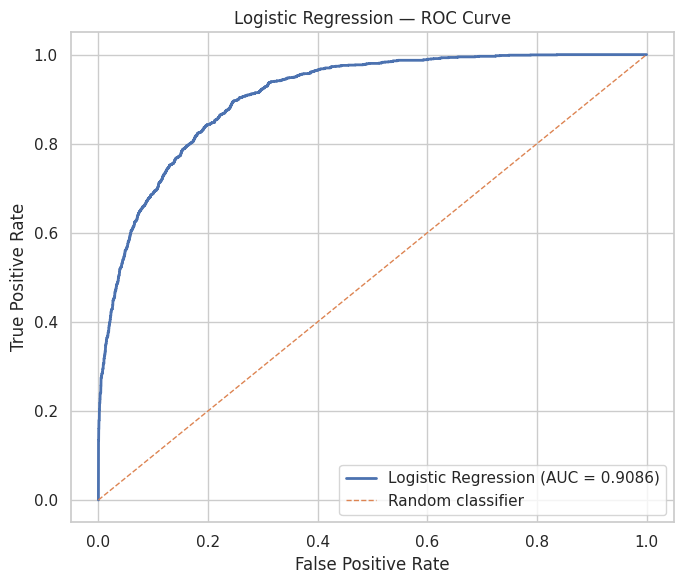

ROC-AUC: 0.9086


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, logistic_y_prob)

# Calculate ROC-AUC
logistic_roc_auc = roc_auc_score(y_test, logistic_y_prob)

# Plot ROC curve
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {logistic_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {logistic_roc_auc:.4f}")

### Analysis

The Logistic Regression ROC curve lies well above the random-classifier reference line across most false-positive rates, indicating strong separation between the <=50K and >50K income classes. The holdout ROC-AUC of 0.9086 confirms that the model has strong overall discriminatory ability across classification thresholds. This performance supports Logistic Regression as a strong baseline for comparison with the tree-based models.

## 2.6 — Classification Report
### Rationale

A classification report provides class-specific precision, recall, and F1 scores for both income categories. Because the project's primary interest is identifying individuals earning more than $50K, examining the minority class separately helps determine whether the overall model performance is masking weaker performance for high-income predictions.

In [ ]:
from sklearn.metrics import classification_report

logistic_report = classification_report(
    y_test,
    logistic_y_pred,
    target_names=["<=50K", ">50K"],
    digits=4
)

print("Logistic Regression — Classification Report:")
print(logistic_report)

Logistic Regression — Classification Report:
              precision    recall  f1-score   support

       <=50K     0.8859    0.9345    0.9096      4945
        >50K     0.7502    0.6205    0.6792      1568

    accuracy                         0.8589      6513
   macro avg     0.8181    0.7775    0.7944      6513
weighted avg     0.8532    0.8589    0.8541      6513



### Analysis

The classification report shows that Logistic Regression performs substantially better on the majority `<=50K` class than on the `>50K` class. For `<=50K`, the model achieves 88.59% precision, 93.45% recall, and a 90.96% F1 score, while performance for the `>50K` class is lower at 75.02% precision, 62.05% recall, and a 67.92% F1 score. The lower recall for the >50K class indicates that the model misses a meaningful portion of higher-income individuals, which is consistent with the confusion matrix and highlights the tradeoff created by the class imbalance.

## 2.7 — Coefficient Interpretation
### Rationale
Logistic Regression provides interpretable coefficients that indicate how each predictor is associated with the likelihood of an individual being classified as earning more than $50K. Examining the largest positive and negative coefficients will help identify the features contributing most strongly to the model's predictions and connect the modeling results back to patterns identified during the midpoint EDA.

In [ ]:
# Extract Logistic Regression coefficients
logistic_estimator = logistic_model.named_steps["logistic"]

coefficient_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": logistic_estimator.coef_[0]
})

# Sort by coefficient
coefficient_df["abs_coefficient"] = coefficient_df["coefficient"].abs()

# Largest positive coefficients
top_positive = (
    coefficient_df
    .sort_values("coefficient", ascending=False)
    .head(10)
)

# Largest negative coefficients
top_negative = (
    coefficient_df
    .sort_values("coefficient", ascending=True)
    .head(10)
)

print("Top 10 Positive Coefficients:")
print(top_positive[["feature", "coefficient"]].to_string(index=False))

print("\nTop 10 Negative Coefficients:")
print(top_negative[["feature", "coefficient"]].to_string(index=False))

Top 10 Positive Coefficients:
                          feature  coefficient
                     capital.gain     2.174327
                      net.capital     2.121084
marital.status_Married-civ-spouse     1.121525
                     capital.loss     0.845308
                  age.group_36-45     0.639480
                  age.group_46-55     0.552104
                hours.group_41-60     0.492323
                  age.group_26-35     0.489790
                              age     0.381343
                   hours.group_40     0.368394

Top 10 Negative Coefficients:
                     feature  coefficient
          has.capital.change    -0.698756
    education.group_Below-HS    -0.658363
     education.group_HS-grad    -0.512468
  occupation_Priv-house-serv    -0.336774
education.group_Some-college    -0.310555
    occupation_Other-service    -0.281391
      relationship_Own-child    -0.257720
  workclass_Self-emp-not-inc    -0.236308
           workclass_Private    -0.217911
  

### Analysis

The Logistic Regression coefficients indicate that capital-related variables, marital status, age, and work-hour patterns have strong positive associations with the probability of earning >$50K, while lower education levels and several occupations have negative associations. `capital.gain` has the largest positive coefficient (2.1743), followed closely by `net.capital` (2.1211), while being classified in the `Below-HS` education group has a strong negative coefficient (-0.6584). The positive coefficient for `Married-civ-spouse` (1.1215) and the negative coefficients for lower education groups are consistent with patterns identified during the midpoint EDA. Coefficients represent conditional associations within the model and should not be interpreted as causal effects; the overlapping capital-related predictors may also affect the individual coefficient values.

## 2.8 — Odds Ratios

In [ ]:
# Calculate odds ratios
coefficient_df["odds_ratio"] = np.exp(coefficient_df["coefficient"])

# Top positive associations by odds ratio
top_positive_or = (
    coefficient_df
    .sort_values("coefficient", ascending=False)
    .head(10)
)

# Top negative associations by odds ratio
top_negative_or = (
    coefficient_df
    .sort_values("coefficient", ascending=True)
    .head(10)
)

print("Top 10 Positive Associations:")
print(
    top_positive_or[["feature", "coefficient", "odds_ratio"]]
    .to_string(index=False)
)

print("\nTop 10 Negative Associations:")
print(
    top_negative_or[["feature", "coefficient", "odds_ratio"]]
    .to_string(index=False)
)

Top 10 Positive Associations:
                          feature  coefficient  odds_ratio
                     capital.gain     2.174327    8.796267
                      net.capital     2.121084    8.340170
marital.status_Married-civ-spouse     1.121525    3.069531
                     capital.loss     0.845308    2.328696
                  age.group_36-45     0.639480    1.895495
                  age.group_46-55     0.552104    1.736903
                hours.group_41-60     0.492323    1.636113
                  age.group_26-35     0.489790    1.631974
                              age     0.381343    1.464250
                   hours.group_40     0.368394    1.445411

Top 10 Negative Associations:
                     feature  coefficient  odds_ratio
          has.capital.change    -0.698756    0.497204
    education.group_Below-HS    -0.658363    0.517698
     education.group_HS-grad    -0.512468    0.599015
  occupation_Priv-house-serv    -0.336774    0.714070
education.group_Some

### Analysis

The odds ratios provide an interpretable view of the Logistic Regression coefficients by expressing the multiplicative change in the odds of being classified as >$50K. Among the positive associations, `capital.gain` has an odds ratio of 8.80 and `net.capital` has an odds ratio of 8.34, while `marital.status_Married-civ-spouse` has an odds ratio of 3.07. Among the negative associations, `has.capital.change` has an odds ratio of 0.50, while `education.group_Below-HS` and `education.group_HS-grad` have odds ratios of 0.52 and 0.60, respectively. These values describe conditional associations within the fitted model and should not be interpreted as causal effects, particularly because several capital-related variables overlap in the information they represent.

## 2.9 — Visualize the strongest coefficients
### Rationale
A coefficient plot provides a compact visual summary of the Logistic Regression model's strongest associations with the >$50K outcome. Showing both positive and negative coefficients helps identify which features are associated with higher or lower predicted income while making the relative magnitude of the model's effects easier to communicate.

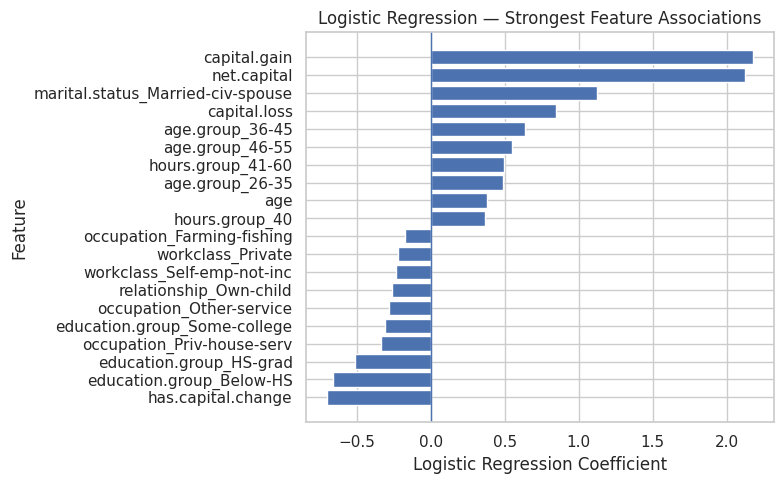

In [ ]:
# Select the 10 strongest positive and 10 strongest negative coefficients
top_positive = (
    coefficient_df
    .sort_values("coefficient", ascending=False)
    .head(10)
)

top_negative = (
    coefficient_df
    .sort_values("coefficient", ascending=True)
    .head(10)
)

top_coefficients = pd.concat([
    top_negative,
    top_positive
]).sort_values("coefficient")

plt.figure(figsize=(8, 5))

plt.barh(
    top_coefficients["feature"],
    top_coefficients["coefficient"]
)

plt.axvline(0, linewidth=1)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression — Strongest Feature Associations")
plt.tight_layout()
plt.show()

### Analysis

The coefficient plot highlights the features with the strongest positive and negative associations with the predicted >$50K outcome. Capital-related variables and marital status show the strongest positive coefficients, while lower education groups and several occupations show negative coefficients. The direction of these associations is broadly consistent with the midpoint EDA, reinforcing the importance of education, employment characteristics, age, marital status, and capital activity in predicting income.

## 2.10 Logistic Regression — Assumption Checks
### 2.10.1 Multicollinearity - Initial VIF Analysis
### Rationale
Logistic Regression assumes that predictors do not exhibit problematic levels of multicollinearity. Highly correlated predictors can make coefficient estimates unstable and make individual feature effects difficult to interpret. Variance Inflation Factor (VIF) will be used to identify predictors with potentially problematic redundancy.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

# Add intercept for VIF calculation
X_vif = sm.add_constant(X_train.astype(float))

vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# Remove intercept and sort by VIF
vif_df = (
    vif_df[vif_df["feature"] != "const"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 VIF values:")
print(vif_df.head(15).to_string(index=False))

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Top 15 VIF values:
                          feature       VIF
                     capital.gain       inf
                      net.capital       inf
                     capital.loss       inf
           workclass_Never-worked       inf
                workclass_Unknown       inf
               occupation_Unknown       inf
marital.status_Married-civ-spouse 40.849523
       relationship_Not-in-family 30.894190
                              age 22.666004
           relationship_Own-child 21.409798
                  net.capital.log 20.896498
               has.capital.change 18.105436
                hours.group_41-60 17.498058
           relationship_Unmarried 16.502438
                  age.group_56-65 15.343180


### Analysis

The initial VIF analysis indicates substantial multicollinearity among several predictors. Six variables have infinite VIF values, indicating exact linear dependence within the predictor matrix, while several other variables have VIF values well above commonly used thresholds for potential multicollinearity concerns. The strongest sources appear to be the capital-related variables, age and age-group variables, and the relationship/work-status variables, suggesting that some engineered features contain overlapping information with their underlying variables. These results indicate that the predictor set should be reviewed for redundant representations before finalizing the Logistic Regression model.

### 2.10.2 — Reduce redundant continuous predictors
### Rationale
The initial VIF results identified perfect multicollinearity among the capital variables and substantial redundancy between continuous variables and their corresponding binned representations. For the Logistic Regression model, a single representation of each underlying concept provides a more stable and interpretable coefficient structure while retaining the feature engineering developed during the midpoint analysis.

| Concept    | Current variables                                                | Logistic Regression choice                                                             |
| ---------- | ---------------------------------------------------------------- | -------------------------------------------------------------------------------------- |
| Age        | `age` + `age.group_*`                                            | Keep `age.group_*`; remove `age`                                                       |
| Work hours | `hours.per.week` + `hours.group_*`                               | Keep `hours.group_*`; remove `hours.per.week`                                          |
| Education  | `education.num` + `education.group_*`                            | Already keeping `education.group_*`                                                    |
| Capital    | `capital.gain`, `capital.loss`, `net.capital`, `net.capital.log` | Keep `net.capital.log` and `has.capital.change`; remove the redundant raw/net versions |


In [ ]:
columns_to_remove = [
    "age",
    "hours.per.week",
    "capital.gain",
    "capital.loss",
    "net.capital"
]

print("Columns found:")
for col in columns_to_remove:
    print(f"{col}: {col in X_model.columns}")

Columns found:
age: True
hours.per.week: True
capital.gain: True
capital.loss: True
net.capital: True


In [ ]:
# Create a Logistic Regression-specific predictor set
X_logistic = X_model.copy()

columns_to_remove = [
    "age",
    "hours.per.week",
    "capital.gain",
    "capital.loss",
    "net.capital"
]

X_logistic = X_logistic.drop(columns=columns_to_remove)

print("Original X_model shape:", X_model.shape)
print("X_logistic shape:", X_logistic.shape)

print("\nRemoved columns:")
print(columns_to_remove)

print("\nRemaining removed columns check:")
print([
    col for col in columns_to_remove
    if col in X_logistic.columns
])

Original X_model shape: (32561, 59)
X_logistic shape: (32561, 54)

Removed columns:
['age', 'hours.per.week', 'capital.gain', 'capital.loss', 'net.capital']

Remaining removed columns check:
[]


### Analysis

A Logistic Regression-specific predictor set was created to reduce redundancy identified during the initial multicollinearity assessment. Five predictors were removed: `age`, `hours.per.week`, `capital.gain`, `capital.loss`, and `net.capital`, while the corresponding engineered representations remain available through the age and hours group indicators, `net.capital.log`, and `has.capital.change`. The shared `X_model` dataset remains unchanged so that the other team members can continue using the common modeling dataset.

In [ ]:
# Create the Logistic Regression training set using the same observations
X_train_logistic = X_logistic.loc[X_train.index]

print("X_train_logistic shape:", X_train_logistic.shape)
print("y_train shape:", y_train.shape)

print("\nSame number of training observations:",
      len(X_train_logistic) == len(y_train))

X_train_logistic shape: (26048, 54)
y_train shape: (26048,)

Same number of training observations: True


In [ ]:
# Recalculate VIF after removing redundant continuous predictors
X_vif_logistic = sm.add_constant(X_train_logistic.astype(float))

vif_logistic_df = pd.DataFrame({
    "feature": X_vif_logistic.columns,
    "VIF": [
        variance_inflation_factor(X_vif_logistic.values, i)
        for i in range(X_vif_logistic.shape[1])
    ]
})

vif_logistic_df = (
    vif_logistic_df[vif_logistic_df["feature"] != "const"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 VIF values after feature reduction:")
print(vif_logistic_df.head(15).to_string(index=False))

/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Top 15 VIF values after feature reduction:
                          feature       VIF
           workclass_Never-worked       inf
                workclass_Unknown       inf
               occupation_Unknown       inf
marital.status_Married-civ-spouse 40.846181
       relationship_Not-in-family 30.890169
           relationship_Own-child 21.397449
           relationship_Unmarried 16.500547
                       race_White 13.753508
                       race_Black 10.460692
                workclass_Private  8.016065
      relationship_Other-relative  4.683949
          race_Asian-Pac-Islander  4.536676
                   hours.group_40  3.977503
       workclass_Self-emp-not-inc  3.688463
                hours.group_41-60  3.671137


### 2.10.3 — Investigate `Unknown` indicators
### Rationale
The remaining infinite VIF values suggest exact or near-exact relationships among several categorical indicators. Before removing any variables, we will examine the corresponding categories to determine whether the redundancy results from mutually exclusive dummy encoding, overlapping missingness indicators, or another structural relationship.

In [ ]:
# Examine the relationship among the variables with infinite VIF
infinite_vif_features = [
    "workclass_Never-worked",
    "workclass_Unknown",
    "occupation_Unknown"
]

print(
    X_train_logistic[infinite_vif_features].sum()
)

print("\nCross-tabulation:")
print(
    pd.crosstab(
        X_train_logistic["workclass_Unknown"],
        X_train_logistic["occupation_Unknown"]
    )
)

workclass_Never-worked       4
workclass_Unknown         1472
occupation_Unknown        1476
dtype: int64

Cross-tabulation:
occupation_Unknown      0     1
workclass_Unknown              
0                   24572     4
1                       0  1472


### Analysis

The remaining infinite VIF values are driven primarily by the strong structural relationship between the `workclass_Unknown` and `occupation_Unknown` indicators. The training data contain 1,472 observations in which both indicators are 1, with only four additional observations where `occupation_Unknown` is 1 while `workclass_Unknown` is 0. This near-deterministic relationship indicates that the two missingness indicators provide largely redundant information in the Logistic Regression model. The midpoint analysis identified the same missingness pattern and intentionally preserved these observations as `Unknown`, so any reduction should retain the information while avoiding unnecessary redundancy.

In [ ]:
exception_rows = X_train_logistic[
    (X_train_logistic["workclass_Unknown"] == 0) &
    (X_train_logistic["occupation_Unknown"] == 1)
]

print("Number of exception rows:", len(exception_rows))

print("\nException rows:")
print(
    exception_rows[
        ["workclass_Unknown", "occupation_Unknown", "workclass_Never-worked"]
    ]
)

Number of exception rows: 4

Exception rows:
       workclass_Unknown  occupation_Unknown  workclass_Never-worked
13675                  0                   1                       1
21934                  0                   1                       1
32331                  0                   1                       1
17089                  0                   1                       1


In [ ]:
# Create a revised Logistic Regression feature set
X_logistic_v2 = X_logistic.drop(
    columns=["workclass_Unknown"]
)

print("Previous Logistic Regression predictors:",
      X_logistic.shape[1])

print("Revised Logistic Regression predictors:",
      X_logistic_v2.shape[1])

print("\nworkclass_Unknown present:",
      "workclass_Unknown" in X_logistic_v2.columns)

print("occupation_Unknown present:",
      "occupation_Unknown" in X_logistic_v2.columns)

Previous Logistic Regression predictors: 54
Revised Logistic Regression predictors: 53

workclass_Unknown present: False
occupation_Unknown present: True


### Analysis

The revised Logistic Regression predictor set contains 53 features after removing `workclass_Unknown` while retaining `occupation_Unknown`. This change removes one highly redundant missingness indicator while preserving information about missing employment-related data. The shared `X_model` dataset remains unchanged, so this adjustment applies only to the Logistic Regression model.

### 2.10.4 — Recalculate VIF after removing `workclass_Unknown`

In [ ]:
# Create the revised training predictor set
X_train_logistic_v2 = X_logistic_v2.loc[X_train.index]

# Calculate VIF
X_vif_logistic_v2 = sm.add_constant(
    X_train_logistic_v2.astype(float)
)

vif_logistic_v2 = pd.DataFrame({
    "feature": X_vif_logistic_v2.columns,
    "VIF": [
        variance_inflation_factor(
            X_vif_logistic_v2.values, i
        )
        for i in range(X_vif_logistic_v2.shape[1])
    ]
})

vif_logistic_v2 = (
    vif_logistic_v2[vif_logistic_v2["feature"] != "const"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 VIF values after removing workclass_Unknown:")
print(
    vif_logistic_v2.head(15).to_string(index=False)
)

Top 15 VIF values after removing workclass_Unknown:
                          feature       VIF
marital.status_Married-civ-spouse 40.846181
       relationship_Not-in-family 30.890169
           relationship_Own-child 21.397449
           relationship_Unmarried 16.500547
                       race_White 13.753508
                       race_Black 10.460692
                workclass_Private  8.016065
      relationship_Other-relative  4.683949
          race_Asian-Pac-Islander  4.536676
                   hours.group_40  3.977503
       workclass_Self-emp-not-inc  3.688463
                hours.group_41-60  3.671137
     marital.status_Never-married  3.257161
               occupation_Unknown  3.197275
              workclass_Local-gov  3.174678


### Analysis

After removing `workclass_Unknown`, the revised Logistic Regression predictor set no longer contains any infinite VIF values. The highest VIF is 40.85 for `marital.status_Married-civ-spouse`, followed by several relationship and race indicators, indicating that substantial multicollinearity remains among some categorical predictors. However, the most severe issue of perfect multicollinearity has been eliminated, and the remaining elevated VIFs reflect overlapping information among related categorical variables rather than exact redundancy.

### 2.10.5 — Evaluate Revised Logistic Regression
### Rationale

The revised predictor set should be evaluated to determine whether reducing multicollinearity affects predictive performance. The revised model will use the same Logistic Regression pipeline, cross-validation strategy, evaluation metrics, and holdout observations as the original model so that performance can be compared directly.

In [ ]:
# Shape check

print("X_train_logistic_v2:", X_train_logistic_v2.shape)

X_test_logistic_v2 = X_logistic_v2.loc[X_test.index]

print("X_test_logistic_v2:", X_test_logistic_v2.shape)

print("\nTraining/test row counts:")
print("Training:", len(X_train_logistic_v2))
print("Test:", len(X_test_logistic_v2))

X_train_logistic_v2: (26048, 53)
X_test_logistic_v2: (6513, 53)

Training/test row counts:
Training: 26048
Test: 6513


In [ ]:
# Revised Logistic Regression model
logistic_model_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Cross-validation
logistic_cv_results_v2, logistic_cv_summary_v2 = evaluate_model_cv(
    logistic_model_v2,
    X_train_logistic_v2,
    y_train
)

print("Revised Logistic Regression — 5-Fold CV Results:")
for metric, value in logistic_cv_summary_v2.items():
    print(f"{metric}: {value:.4f}")

# Holdout test
logistic_test_results_v2, logistic_y_pred_v2, logistic_y_prob_v2 = (
    evaluate_model_test(
        logistic_model_v2,
        X_train_logistic_v2,
        y_train,
        X_test_logistic_v2,
        y_test
    )
)

print("\nRevised Logistic Regression — Holdout Test Results:")
for metric, value in logistic_test_results_v2.items():
    print(f"{metric}: {value:.4f}")

Revised Logistic Regression — 5-Fold CV Results:
Accuracy: 0.8480
Precision: 0.7208
Recall: 0.6026
F1: 0.6563
ROC-AUC: 0.9038

Revised Logistic Regression — Holdout Test Results:
Accuracy: 0.8508
Precision: 0.7254
Recall: 0.6116
F1: 0.6637
ROC-AUC: 0.8994


### Analysis
The revised Logistic Regression predictor set reduced the number of features from 59 to 53 and eliminated the infinite VIF values identified in the initial multicollinearity assessment. Although predictive performance decreased modestly, the revised model retained strong classification performance with a holdout F1 score of 0.6637 and ROC-AUC of 0.8994. Given the improvement in predictor independence and interpretability, the 53-feature model was selected as the final Logistic Regression specification.

This refinement also identified an opportunity to improve the earlier feature-engineering process. The midpoint notebook created engineered representations of age, work hours, and capital activity but retained the original variables alongside those derived features. The resulting redundancy contributed to the high VIF values observed during Logistic Regression diagnostics. In hindsight, the original variables should have been removed when their corresponding engineered representations were created, or their retention should have been explicitly justified during the midpoint feature-engineering stage.

## 2.1b — Model Setup on Revised Predictor Set
### Rationale

The revised Logistic Regression model uses the 53-feature predictor set developed after the multicollinearity assessment. The model will retain StandardScaler within the pipeline because Logistic Regression is sensitive to feature scale, while the predictor matrix itself remains unscaled outside the pipeline. This revised model will be evaluated using the same cross-validation and holdout procedures established in Phase 1.

In [ ]:
# Revised Logistic Regression model using the 53-feature predictor set
logistic_model_v2 = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

print(logistic_model_v2)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic',
                 LogisticRegression(max_iter=1000, random_state=42))])


### Analysis

The revised Logistic Regression model was configured using the 53-feature predictor set identified during the multicollinearity assessment. Standardization remains inside the modeling pipeline so that scaling is applied as part of model fitting rather than to the shared dataset in advance. The model retains the same `max_iter=1000` and `random_state=42` settings used in the original Logistic Regression specification.

## 2.2b — Cross-Validation Evaluation on Revised Predictor Set
### Rationale
The revised model will be evaluated using the same 5-fold stratified cross-validation framework as the original Logistic Regression model. Using the identical cross-validation configuration allows the change in feature set to be evaluated fairly without introducing differences in the validation procedure.

In [ ]:
# Evaluate revised Logistic Regression using the common CV framework
logistic_cv_results_v2, logistic_cv_summary_v2 = evaluate_model_cv(
    logistic_model_v2,
    X_train_logistic_v2,
    y_train
)

print("Revised Logistic Regression — 5-Fold CV Results:")
for metric, value in logistic_cv_summary_v2.items():
    print(f"{metric}: {value:.4f}")

Revised Logistic Regression — 5-Fold CV Results:
Accuracy: 0.8480
Precision: 0.7208
Recall: 0.6026
F1: 0.6563
ROC-AUC: 0.9038


### Analysis

The revised Logistic Regression model achieved a mean cross-validation accuracy of 84.80%, with precision of 72.08%, recall of 60.26%, and an F1 score of 65.63%. The model achieved a ROC-AUC of 90.38%, indicating strong discrimination between the two income classes despite the reduction in predictors. Compared with the original 59-feature model, performance decreased across all five metrics, providing evidence that the removed predictors contributed useful predictive information.

## 2.3b — Holdout Test Evaluation on Revised Predictor Set
### Rationale
The revised Logistic Regression model will next be evaluated on the same untouched 20% holdout test set used for the original model. This provides a direct comparison of out-of-sample performance while keeping the observations and evaluation procedure consistent.

In [ ]:
# Final revised Logistic Regression evaluation on the holdout test set
logistic_test_results_v2, logistic_y_pred_v2, logistic_y_prob_v2 = (
    evaluate_model_test(
        logistic_model_v2,
        X_train_logistic_v2,
        y_train,
        X_test_logistic_v2,
        y_test
    )
)

print("Revised Logistic Regression — Holdout Test Results:")
for metric, value in logistic_test_results_v2.items():
    print(f"{metric}: {value:.4f}")

Revised Logistic Regression — Holdout Test Results:
Accuracy: 0.8508
Precision: 0.7254
Recall: 0.6116
F1: 0.6637
ROC-AUC: 0.8994


### Analysis

The revised Logistic Regression model achieved 85.08% accuracy, 72.54% precision, 61.16% recall, and an F1 score of 66.37% on the holdout test set. The ROC-AUC of 89.94% indicates that the model continues to provide strong discrimination between the <=50K and >50K income classes. Compared with the original 59-feature model, the revised model shows a modest decline in holdout performance, but the reduction in predictor redundancy provides a more interpretable and stable feature set for Logistic Regression.

### Model Performance Summary

| Model | CV Accuracy | CV Precision | CV Recall | CV F1 | CV ROC-AUC | Test Accuracy | Test Precision | Test Recall | Test F1 | Test ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Logistic Regression — Original | 0.8582 | 0.7480 | 0.6203 | 0.6781 | 0.9148 | 0.8589 | 0.7502 | 0.6205 | 0.6792 | 0.9086 |
| Logistic Regression — Revised | 0.8480 | 0.7208 | 0.6026 | 0.6563 | 0.9038 | 0.8508 | 0.7254 | 0.6116 | 0.6637 | 0.8994 |
| Decision Tree | — | — | — | — | — | — | — | — | — | — |
| Random Forest | — | — | — | — | — | — | — | — | — | — |
| Gradient Boosting | — | — | — | — | — | — | — | — | — | — |

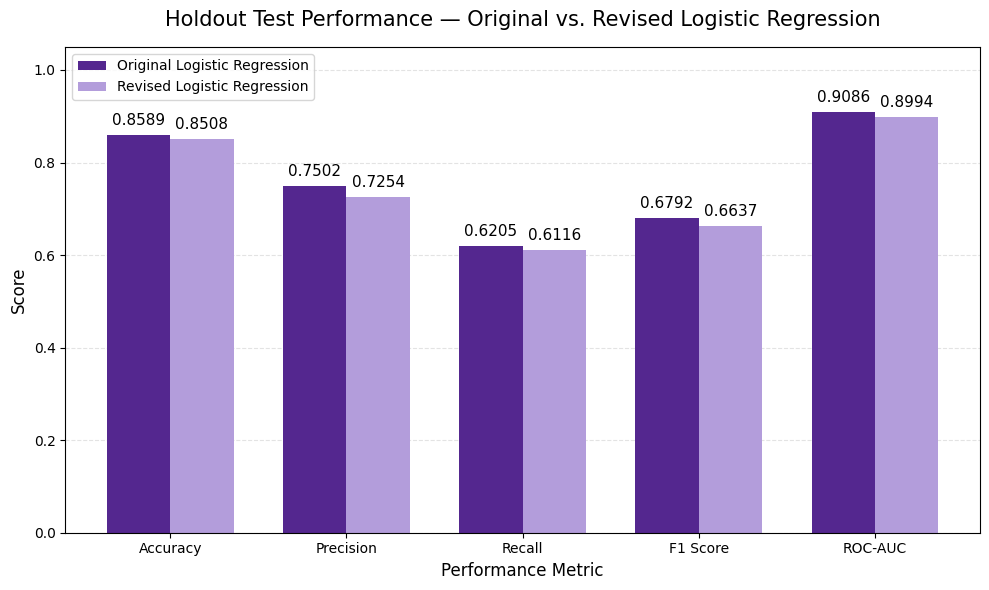

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Holdout test metrics
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

original_scores = [0.8589, 0.7502, 0.6205, 0.6792, 0.9086]
revised_scores = [0.8508, 0.7254, 0.6116, 0.6637, 0.8994]

x = np.arange(len(metrics))
width = 0.36

# Purple color scheme
purple_dark = "#54278f"
purple_light = "#b39ddb"

fig, ax = plt.subplots(figsize=(10, 6))

bars_original = ax.bar(
    x - width / 2,
    original_scores,
    width,
    label="Original Logistic Regression",
    color=purple_dark
)

bars_revised = ax.bar(
    x + width / 2,
    revised_scores,
    width,
    label="Revised Logistic Regression",
    color=purple_light
)

# Add value labels
for bars in [bars_original, bars_revised]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

ax.set_title(
    "Holdout Test Performance — Original vs. Revised Logistic Regression",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Performance Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylim(0, 1.05)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)
ax.legend()

plt.tight_layout()
plt.show()

## 2.4b — Confusion Matrix on Revised Predictor Set
### Rationale
A confusion matrix will be used to examine the types of classification errors made by the revised Logistic Regression model on the holdout test set. This provides class-specific insight into correct and incorrect predictions and allows comparison with the original Logistic Regression model.

In [ ]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix for revised Logistic Regression
logistic_cm_v2 = confusion_matrix(
    y_test,
    logistic_y_pred_v2
)

print("Revised Logistic Regression — Confusion Matrix:")
print(logistic_cm_v2)

Revised Logistic Regression — Confusion Matrix:
[[4582  363]
 [ 609  959]]


### Analysis

The revised Logistic Regression model correctly classified 4,582 individuals earning <=50K and 959 individuals earning >50K. The model produced 363 false positives and 609 false negatives, indicating that it missed more >50K individuals than it incorrectly classified as >50K. Compared with the original model, the revised model produced slightly more false positives and false negatives, consistent with its modest reduction in precision, recall, and F1 score.

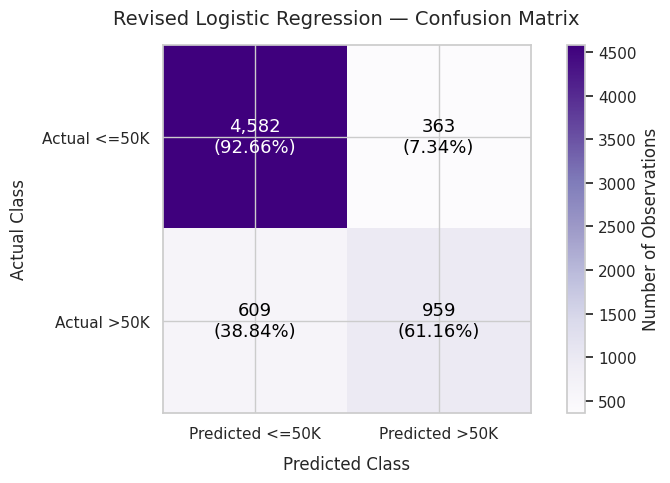

In [ ]:
# Revised Logistic Regression confusion matrix values
cm = logistic_cm_v2

# Calculate percentages within each actual class
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))

# Heatmap
im = ax.imshow(cm, cmap="Purples")

# Add counts and percentages
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # White text for the dark top-left quadrant
        text_color = "white" if (i == 0 and j == 0) else "black"

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}\n({cm_percent[i, j]:.2f}%)",
            ha="center",
            va="center",
            fontsize=13,
            color=text_color
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Predicted <=50K", "Predicted >50K"])
ax.set_yticklabels(["Actual <=50K", "Actual >50K"])

ax.set_title(
    "Revised Logistic Regression — Confusion Matrix",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Predicted Class", labelpad=10)
ax.set_ylabel("Actual Class", labelpad=10)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of Observations")

plt.tight_layout()
plt.show()

## 2.5b — ROC Curve on Revised Predictor Set
### Rationale

The ROC curve will evaluate how well the revised Logistic Regression model distinguishes between the <=50K and >50K income classes across different classification thresholds. Comparing its ROC-AUC with the original model will show whether the reduction in predictor redundancy materially affected the model's overall discriminatory ability.

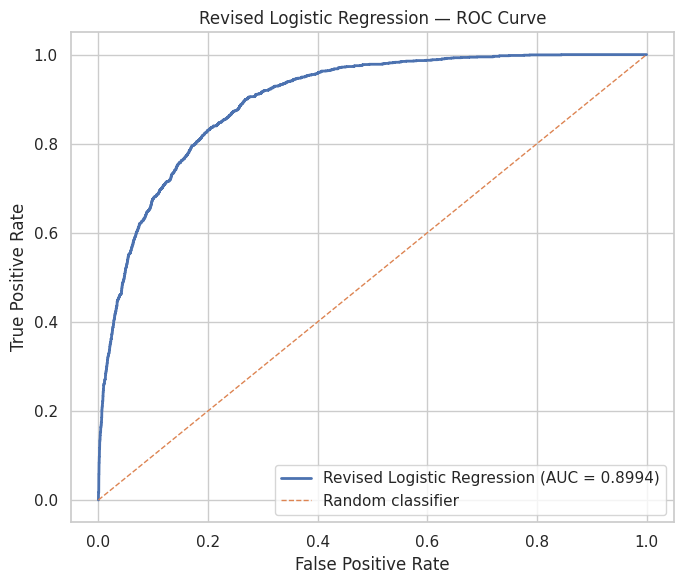

ROC-AUC: 0.8994


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve for revised Logistic Regression
fpr_v2, tpr_v2, thresholds_v2 = roc_curve(
    y_test,
    logistic_y_prob_v2
)

# Calculate ROC-AUC
logistic_roc_auc_v2 = roc_auc_score(
    y_test,
    logistic_y_prob_v2
)

# Plot ROC curve
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_v2,
    tpr_v2,
    linewidth=2,
    label=f"Revised Logistic Regression (AUC = {logistic_roc_auc_v2:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Revised Logistic Regression — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {logistic_roc_auc_v2:.4f}")

### Analysis

The revised Logistic Regression ROC curve remains well above the random-classifier reference line across the range of false-positive rates. The holdout ROC-AUC of 0.8994 indicates that the revised model retains strong ability to distinguish between the <=50K and >50K income classes despite the reduction in predictors. Compared with the original model's ROC-AUC of 0.9086, the modest decline suggests that the removed redundant predictors contributed some predictive information but were not essential to maintaining strong overall discrimination.

## 2.6b — Classification Report on Revised Predictor Set
### Rationale
A classification report will provide class-specific precision, recall, and F1 scores for the revised Logistic Regression model. Examining performance separately for the <=50K and >50K classes will show whether the reduction in predictors affected the model's ability to identify higher-income individuals, which is particularly important given the target class imbalance.

In [ ]:
from sklearn.metrics import classification_report

logistic_report_v2 = classification_report(
    y_test,
    logistic_y_pred_v2,
    target_names=["<=50K", ">50K"],
    digits=4
)

print("Revised Logistic Regression — Classification Report:")
print(logistic_report_v2)

Revised Logistic Regression — Classification Report:
              precision    recall  f1-score   support

       <=50K     0.8827    0.9266    0.9041      4945
        >50K     0.7254    0.6116    0.6637      1568

    accuracy                         0.8508      6513
   macro avg     0.8040    0.7691    0.7839      6513
weighted avg     0.8448    0.8508    0.8462      6513



### Analysis

The revised Logistic Regression model correctly identifies the majority `<=50K` class more effectively than the `>50K` class. For `<=50K`, the model achieves 88.27% precision, 92.66% recall, and a 90.41% F1 score, while the `>50K` class has lower precision of 72.54%, recall of 61.16%, and F1 score of 66.37%. The lower recall for the >50K class indicates that the revised model still misses a meaningful portion of higher-income individuals, consistent with the holdout F1 and ROC-AUC results.

## 2.7b — Coefficient Interpretation on Revised Predictor Set
### Rationale
Logistic Regression coefficients show the direction and relative strength of each predictor's association with the probability of an income above $50K. Examining the strongest positive and negative coefficients will identify which features contribute most strongly to the revised model's predictions and allow comparison with the coefficient patterns from the original model.

In [ ]:
# Extract coefficients from the revised Logistic Regression model
logistic_estimator_v2 = logistic_model_v2.named_steps["logistic"]

coefficient_df_v2 = pd.DataFrame({
    "feature": X_train_logistic_v2.columns,
    "coefficient": logistic_estimator_v2.coef_[0]
})

# Calculate absolute coefficient magnitude
coefficient_df_v2["abs_coefficient"] = (
    coefficient_df_v2["coefficient"].abs()
)

# Largest positive coefficients
top_positive_v2 = (
    coefficient_df_v2
    .sort_values("coefficient", ascending=False)
    .head(10)
)

# Largest negative coefficients
top_negative_v2 = (
    coefficient_df_v2
    .sort_values("coefficient", ascending=True)
    .head(10)
)

print("Top 10 Positive Coefficients:")
print(
    top_positive_v2[["feature", "coefficient"]]
    .to_string(index=False)
)

print("\nTop 10 Negative Coefficients:")
print(
    top_negative_v2[["feature", "coefficient"]]
    .to_string(index=False)
)

Top 10 Positive Coefficients:
                          feature  coefficient
marital.status_Married-civ-spouse     1.063587
                  age.group_36-45     0.802192
                  age.group_46-55     0.796176
                hours.group_41-60     0.586093
                  age.group_26-35     0.535497
                  age.group_56-65     0.531526
               has.capital.change     0.459646
                   hours.group_40     0.432579
                         sex_Male     0.353213
                relationship_Wife     0.277682

Top 10 Negative Coefficients:
                     feature  coefficient
    education.group_Below-HS    -0.667375
     education.group_HS-grad    -0.526250
education.group_Some-college    -0.323435
    occupation_Other-service    -0.285530
      relationship_Own-child    -0.235758
  workclass_Self-emp-not-inc    -0.229417
           workclass_Private    -0.222614
          occupation_Unknown    -0.185199
         workclass_Local-gov    -0.175875
  

### Analysis

The revised Logistic Regression coefficients show that marital status, age groups, work-hour groups, and capital activity have the strongest positive associations with the >$50K outcome. `marital.status_Married-civ-spouse` has the largest positive coefficient at 1.0636, followed by `age.group_36-45` (0.8022) and `age.group_46-55` (0.7962). The strongest negative coefficients are associated with lower education groups, particularly `education.group_Below-HS` (-0.6674) and `education.group_HS-grad` (-0.5263), while several occupation and workclass categories also have negative associations. Compared with the original model, the revised coefficients are more focused on the retained engineered features because the redundant continuous variables were removed.

## 2.8b — Odds Ratios on Revised Predictor Set
### Rationale
Odds ratios provide a more interpretable representation of Logistic Regression coefficients by expressing the multiplicative change in the odds of the >$50K outcome. Examining the strongest positive and negative associations will help translate the revised model coefficients into terms that are easier to communicate to a management audience.

In [ ]:
# Calculate odds ratios for the revised Logistic Regression model
coefficient_df_v2["odds_ratio"] = np.exp(
    coefficient_df_v2["coefficient"]
)

# Top positive associations
top_positive_or_v2 = (
    coefficient_df_v2
    .sort_values("coefficient", ascending=False)
    .head(10)
)

# Top negative associations
top_negative_or_v2 = (
    coefficient_df_v2
    .sort_values("coefficient", ascending=True)
    .head(10)
)

print("Top 10 Positive Associations:")
print(
    top_positive_or_v2[
        ["feature", "coefficient", "odds_ratio"]
    ].to_string(index=False)
)

print("\nTop 10 Negative Associations:")
print(
    top_negative_or_v2[
        ["feature", "coefficient", "odds_ratio"]
    ].to_string(index=False)
)

Top 10 Positive Associations:
                          feature  coefficient  odds_ratio
marital.status_Married-civ-spouse     1.063587    2.896743
                  age.group_36-45     0.802192    2.230425
                  age.group_46-55     0.796176    2.217047
                hours.group_41-60     0.586093    1.796954
                  age.group_26-35     0.535497    1.708297
                  age.group_56-65     0.531526    1.701526
               has.capital.change     0.459646    1.583514
                   hours.group_40     0.432579    1.541228
                         sex_Male     0.353213    1.423634
                relationship_Wife     0.277682    1.320066

Top 10 Negative Associations:
                     feature  coefficient  odds_ratio
    education.group_Below-HS    -0.667375    0.513053
     education.group_HS-grad    -0.526250    0.590816
education.group_Some-college    -0.323435    0.723659
    occupation_Other-service    -0.285530    0.751616
      relationship_O

### Analysis

The revised Logistic Regression odds ratios show that marital status, age, work hours, and capital activity have the strongest positive associations with the >50K outcome. Being in the `Married-civ-spouse` category is associated with 2.90 times the odds of the >50K outcome relative to the reference category, while the `age.group_36-45` and `age.group_46-55` indicators have odds ratios of 2.23 and 2.22, respectively. The strongest negative associations are observed for `education.group_Below-HS` (odds ratio 0.51), `education.group_HS-grad` (0.59), and `education.group_Some-college` (0.72), indicating lower modeled odds of the >$50K outcome relative to the omitted education reference category. These are conditional associations within the fitted model and should not be interpreted as causal effects.

## 2.9b — Coefficient Visualization on Revised Predictor Set
### Rationale
A coefficient plot provides a visual summary of the strongest positive and negative associations in the revised Logistic Regression model. This makes the direction and relative magnitude of the modeled relationships easier to communicate and allows the revised coefficients to be compared with those from the original model.

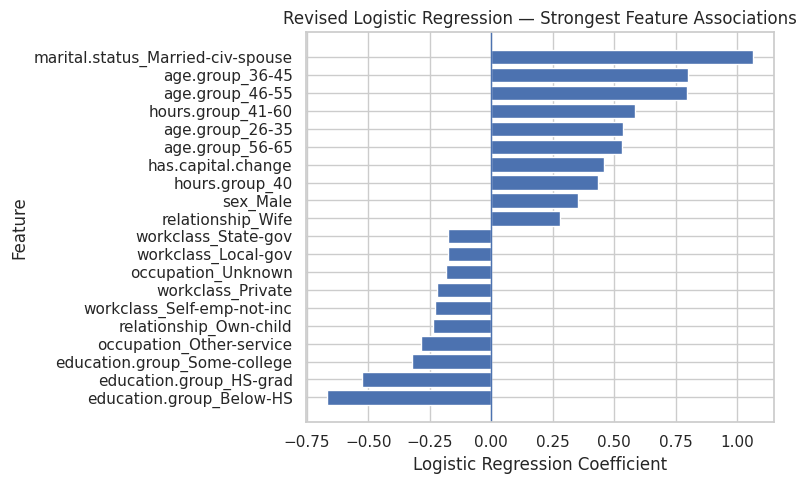

In [ ]:
# Select the 10 strongest positive and negative coefficients
top_positive_v2 = (
    coefficient_df_v2
    .sort_values("coefficient", ascending=False)
    .head(10)
)

top_negative_v2 = (
    coefficient_df_v2
    .sort_values("coefficient", ascending=True)
    .head(10)
)

top_coefficients_v2 = pd.concat([
    top_negative_v2,
    top_positive_v2
]).sort_values("coefficient")

plt.figure(figsize=(8, 5))

plt.barh(
    top_coefficients_v2["feature"],
    top_coefficients_v2["coefficient"]
)

plt.axvline(0, linewidth=1)
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title(
    "Revised Logistic Regression — Strongest Feature Associations"
)

plt.tight_layout()
plt.show()

### Analysis

The revised coefficient plot shows that `marital.status_Married-civ-spouse` has the strongest positive association with the >$50K outcome, followed by the `age.group` indicators and longer work-hour categories. The strongest negative associations are concentrated among the lower education groups, particularly `education.group_Below-HS`, `education.group_HS-grad`, and `education.group_Some-college`. The visualization provides a concise summary of the revised model's most influential conditional associations and is suitable for inclusion in the final report or presentation.

## 2.11 — Logistic Regression Linearity Assumption
### Rationale
Logistic Regression assumes that continuous predictors have a linear relationship with the log-odds of the binary outcome. The revised model retains continuous predictors such as `fnlwgt` and `net.capital.log`, so their relationships with the model's predicted log-odds should be examined to determine whether the assumption is reasonably satisfied.

In [ ]:
# Identify continuous numeric predictors in the revised Logistic Regression model
continuous_predictors = [
    col for col in X_train_logistic_v2.columns
    if X_train_logistic_v2[col].nunique() > 10
]

print("Continuous predictors:")
print(continuous_predictors)

print("\nNumber of continuous predictors:",
      len(continuous_predictors))

Continuous predictors:
['fnlwgt', 'net.capital.log']

Number of continuous predictors: 2


### 2.11.1 — Create the Log-Odds Diagnostic Data
### Rationale
The Logistic Regression linearity assumption concerns the relationship between each continuous predictor and the model's linear predictor, or log-odds. Calculating the fitted log-odds provides the basis for assessing whether the relationship is approximately linear for fnlwgt and net.capital.log.

In [ ]:
# Get the fitted logistic regression estimator
logistic_estimator_v2 = logistic_model_v2.named_steps["logistic"]

# Transform training data using the fitted scaler
X_train_scaled_v2 = logistic_model_v2.named_steps["scaler"].transform(
    X_train_logistic_v2
)

# Calculate the model's linear predictor (log-odds)
log_odds_v2 = (
    X_train_scaled_v2 @ logistic_estimator_v2.coef_[0]
    + logistic_estimator_v2.intercept_[0]
)

# Create diagnostic DataFrame
linearity_df = X_train_logistic_v2[
    continuous_predictors
].copy()

linearity_df["log_odds"] = log_odds_v2

print("Linearity diagnostic dataset shape:", linearity_df.shape)
print("\nColumns:")
print(linearity_df.columns.tolist())

print("\nFirst five rows:")
print(linearity_df.head())

Linearity diagnostic dataset shape: (26048, 3)

Columns:
['fnlwgt', 'net.capital.log', 'log_odds']

First five rows:
       fnlwgt  net.capital.log  log_odds
11219  176831        -0.127743 -2.815805
28304  217602        -0.127743 -3.191780
30810  106347        -0.127743 -1.095761
10958   82531        -0.127743 -4.115795
26814   98630        -0.127743 -3.635657


### Analysis

The diagnostic dataset contains the two continuous predictors retained in the revised Logistic Regression model, `fnlwgt` and `net.capital.log`, along with the model's fitted log-odds for each training observation. This provides the basis for evaluating whether the relationship between each continuous predictor and the model's log-odds is approximately linear, as required by the Logistic Regression specification.

### 2.11.2 — Visual Linearity Check: `fnlwgt`

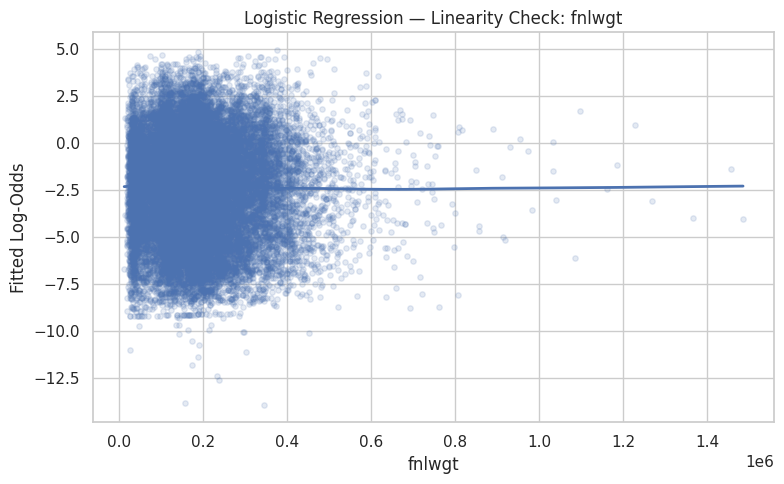

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.regplot(
    data=linearity_df,
    x="fnlwgt",
    y="log_odds",
    scatter_kws={"alpha": 0.15, "s": 15},
    line_kws={"linewidth": 2},
    lowess=True
)

plt.xlabel("fnlwgt")
plt.ylabel("Fitted Log-Odds")
plt.title("Logistic Regression — Linearity Check: fnlwgt")
plt.tight_layout()
plt.show()

### Analysis

The `fnlwgt` diagnostic shows a broadly flat fitted relationship between the predictor and the model's log-odds, with only a slight positive trend across the observed range. No substantial curvature or systematic nonlinear pattern is apparent, suggesting that the linearity assumption is reasonably satisfied for `fnlwgt`. The wide dispersion of fitted log-odds also indicates that other predictors account for most of the variation in the model's predicted outcome.

### 2.11.3 — Linearity Check: net.capital.log

/usr/local/lib/python3.13/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


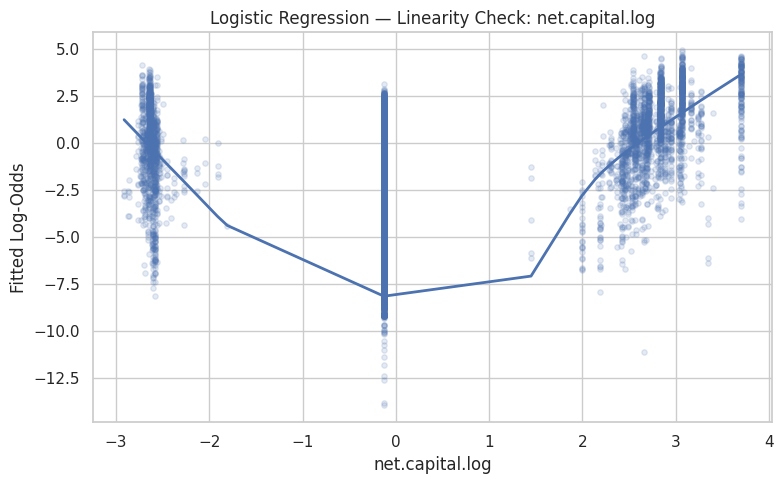

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=linearity_df,
    x="net.capital.log",
    y="log_odds",
    scatter_kws={"alpha": 0.15, "s": 15},
    line_kws={"linewidth": 2},
    lowess=True
)

plt.xlabel("net.capital.log")
plt.ylabel("Fitted Log-Odds")
plt.title("Logistic Regression — Linearity Check: net.capital.log")
plt.tight_layout()
plt.show()

### Analysis

The `net.capital.log` diagnostic shows a clearly nonlinear relationship with the fitted log-odds. The relationship changes substantially across negative, zero, and positive values, with a particularly pronounced pattern around zero. This suggests that the linearity-of-the-log-odds assumption is not fully satisfied for `net.capital.log`, even after the signed log transformation. The result indicates that the engineered capital variable may benefit from a more flexible representation, such as separate indicators or nonlinear terms, although the current model is retained for consistency with the established feature-engineering workflow.

## 2.12 — Logistic Regression Assumption Summary
The Logistic Regression diagnostics indicate that some model assumptions are reasonably satisfied while others present limitations. The `fnlwgt` linearity check showed no substantial curvature in its relationship with the fitted log-odds, suggesting that the linearity assumption is reasonably satisfied for this predictor. In contrast, `net.capital.log` displayed a clearly nonlinear relationship with the fitted log-odds, indicating a potential violation of the linearity assumption despite the earlier log transformation.

The initial VIF analysis also identified substantial multicollinearity, including infinite VIF values caused by redundant feature representations. Feature refinement removed the most severe redundancy and eliminated the infinite VIFs, although several categorical predictors retained elevated VIF values. The revised model was selected because it provides a better balance between predictor independence and predictive performance, while the remaining multicollinearity and nonlinear capital relationship should be acknowledged as limitations when interpreting individual coefficients.

## 2.13 — Final Logistic Regression Results Summary

In [ ]:
# Final Logistic Regression results summary
logistic_final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "5-Fold CV": [
        logistic_cv_summary_v2["Accuracy"],
        logistic_cv_summary_v2["Precision"],
        logistic_cv_summary_v2["Recall"],
        logistic_cv_summary_v2["F1"],
        logistic_cv_summary_v2["ROC-AUC"]
    ],
    "Holdout Test": [
        logistic_test_results_v2["Accuracy"],
        logistic_test_results_v2["Precision"],
        logistic_test_results_v2["Recall"],
        logistic_test_results_v2["F1"],
        logistic_test_results_v2["ROC-AUC"]
    ]
})

logistic_final_summary.round(4)

,Metric,5-Fold CV,Holdout Test
0,Accuracy,0.8480,0.8508
1,Precision,0.7208,0.7254
2,Recall,0.6026,0.6116
3,F1,0.6563,0.6637
4,ROC-AUC,0.9038,0.8994


### Analysis
The final 53-feature Logistic Regression model achieved 84.80% mean cross-validation accuracy, with precision of 72.08%, recall of 60.26%, F1 score of 65.63%, and ROC-AUC of 90.38%. On the holdout test set, the model achieved 85.08% accuracy, 72.54% precision, 61.16% recall, F1 of 66.37%, and ROC-AUC of 89.94%. The close CV and holdout results indicate consistent generalization, while the relatively lower recall for the >50K class shows that identifying higher-income individuals remains the primary challenge.

# ----- Notes for Team -----

The revised 53-feature predictor set will be treated as the finalized modeling feature set for all four models.

- The original 59-feature set contained redundant representations of several engineered features.
- The revised set removes:
  - `age`
  - `hours.per.week`
  - `capital.gain`
  - `capital.loss`
  - `net.capital`
  - `workclass_Unknown`
- The revised set retains the corresponding engineered/grouped representations, including:
  - `age.group_*`
  - `hours.group_*`
  - `net.capital.log`
  - `has.capital.change`
  - `education.group_*`

For consistency, Decision Tree, Random Forest, and Gradient Boosting should use the same 53 predictors as the final Logistic Regression model.

The evaluation framework remains unchanged across all four models:
- Same training/test observations
- Same 80/20 stratified split
- Same `random_state=42`
- Same 5-fold `StratifiedKFold`
- Same evaluation metrics: Accuracy, Precision, Recall, F1, and ROC-AUC
- Same untouched holdout test set

Model-specific preprocessing remains separate:
- Logistic Regression → `StandardScaler` inside the pipeline
- Decision Tree → no scaling
- Random Forest → no scaling
- Gradient Boosting → no scaling

Example of using the revised predictor set as follows:

```python
X_tree = X_logistic_v2.copy()

X_train_tree = X_tree.loc[X_train.index]
X_test_tree = X_tree.loc[X_test.index]

# Phase 3 — Decision Tree

## 3.1 — Model Setup
### Rationale
A Decision Tree classifier will be developed as the second model in the project using the finalized 53-feature predictor set. Decision Trees can capture nonlinear relationships and interactions among predictors without requiring feature scaling, providing a useful contrast to Logistic Regression while maintaining consistency in the feature set used across the project.

In [ ]:
# Create Decision Tree predictor sets from the finalized 53-feature matrix
X_tree = X_logistic_v2.copy()

X_train_tree = X_tree.loc[X_train.index]
X_test_tree = X_tree.loc[X_test.index]

print("X_train_tree shape:", X_train_tree.shape)
print("X_test_tree shape:", X_test_tree.shape)

X_train_tree shape: (26048, 53)
X_test_tree shape: (6513, 53)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

print(decision_tree_model)

DecisionTreeClassifier(random_state=42)


### Analysis

The Decision Tree was configured using the finalized 53-feature predictor set and the same 26,048 training and 6,513 holdout observations established by the common 80/20 stratified split. The baseline model uses `random_state=42` for reproducibility and does not require feature scaling because Decision Trees determine splits using feature thresholds rather than predictor magnitude. This baseline establishes a reference point for evaluating the impact of subsequent hyperparameter tuning while maintaining consistency with the other models.

## 3.2 — Baseline Cross-Validation Evaluation
### Rationale
The baseline Decision Tree will be evaluated using the common 5-fold StratifiedKFold framework established in Phase 1. Using the same folds and evaluation metrics as the other models allows the baseline tree to be compared fairly with Logistic Regression and the team's other classifiers before hyperparameter tuning.

In [ ]:
# Evaluate baseline Decision Tree using the common CV framework
decision_tree_cv_results, decision_tree_cv_summary = evaluate_model_cv(
    decision_tree_model,
    X_train_tree,
    y_train
)

print("Decision Tree — Baseline 5-Fold CV Results:")
for metric, value in decision_tree_cv_summary.items():
    print(f"{metric}: {value:.4f}")

Decision Tree — Baseline 5-Fold CV Results:
Accuracy: 0.8122
Precision: 0.6077
Recall: 0.6203
F1: 0.6139
ROC-AUC: 0.7467


### Analysis

The baseline Decision Tree achieved a mean 5-fold cross-validation accuracy of 81.22%, with precision of 60.77%, recall of 62.03%, and an F1 score of 61.39%. The ROC-AUC of 74.67% indicates substantially weaker class discrimination than the revised Logistic Regression model, which achieved a CV ROC-AUC of 90.38%. The baseline tree therefore provides a useful reference point, but its performance suggests that hyperparameter tuning may improve its generalization and predictive ability.

## 3.3 — Hyperparameter Tuning
### Rationale
Hyperparameter tuning will be used to identify a Decision Tree configuration that improves predictive performance while controlling model complexity. The tuning process will focus on a limited set of parameters that directly influence tree depth and splitting behavior, using the same 5-fold StratifiedKFold cross-validation framework and F1 score as the primary selection criterion.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Decision Tree
decision_tree_param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"]
}

decision_tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=decision_tree_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

print("Number of parameter combinations:",
      len(decision_tree_grid.param_grid["max_depth"])
      * len(decision_tree_grid.param_grid["min_samples_split"])
      * len(decision_tree_grid.param_grid["min_samples_leaf"])
      * len(decision_tree_grid.param_grid["criterion"]))

Number of parameter combinations: 108


In [ ]:
# Run Decision Tree hyperparameter tuning
decision_tree_grid.fit(
    X_train_tree,
    y_train
)

print("Best parameters:")
print(decision_tree_grid.best_params_)

print("\nBest cross-validation F1 score:")
print(f"{decision_tree_grid.best_score_:.4f}")

Best parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best cross-validation F1 score:
0.6596


### Analysis

The hyperparameter search evaluated 108 Decision Tree configurations using 5-fold stratified cross-validation. The best configuration used the `gini` splitting criterion, a maximum depth of 5, `min_samples_split=2`, and `min_samples_leaf=1`, achieving a cross-validation F1 score of 0.6596. The selected maximum depth of 5 indicates that the tuning process favored a relatively constrained tree rather than a highly complex structure, suggesting that limiting tree depth improves generalization for this dataset.

In [ ]:
DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

DecisionTreeClassifier(max_depth=5, random_state=42)

## 3.4 — Final Model Cross-Validation Evaluation
### Rationale
The selected Decision Tree configuration will be evaluated independently using the common 5-fold StratifiedKFold framework. This confirms the performance of the tuned model using the same evaluation procedure applied to the other models and provides the final cross-validation metrics before holdout testing.

In [ ]:
# Create the final tuned Decision Tree
decision_tree_final = DecisionTreeClassifier(
    criterion=decision_tree_grid.best_params_["criterion"],
    max_depth=decision_tree_grid.best_params_["max_depth"],
    min_samples_split=decision_tree_grid.best_params_["min_samples_split"],
    min_samples_leaf=decision_tree_grid.best_params_["min_samples_leaf"],
    random_state=42
)

# Evaluate the final tuned model using the common CV framework
decision_tree_final_cv_results, decision_tree_final_cv_summary = (
    evaluate_model_cv(
        decision_tree_final,
        X_train_tree,
        y_train
    )
)

print("Decision Tree — Final 5-Fold CV Results:")
for metric, value in decision_tree_final_cv_summary.items():
    print(f"{metric}: {value:.4f}")

Decision Tree — Final 5-Fold CV Results:
Accuracy: 0.8371
Precision: 0.6789
Recall: 0.6601
F1: 0.6596
ROC-AUC: 0.8804


### Analysis

The tuned Decision Tree achieved a mean 5-fold cross-validation accuracy of 83.71%, with precision of 67.89%, recall of 66.01%, and an F1 score of 65.96%. The model achieved a ROC-AUC of 88.04%, indicating substantially stronger discrimination than the baseline Decision Tree's ROC-AUC of 74.67%. The improvement in F1 from 61.39% to 65.96% shows that limiting the tree to a maximum depth of 5 improved the balance between precision and recall while reducing unnecessary model complexity.

## 3.5 — Final Holdout Test Evaluation
### Rationale
The final tuned Decision Tree will be evaluated on the untouched holdout test set to measure out-of-sample performance after hyperparameter selection. This test set was not used during tuning, allowing the final results to provide an independent estimate of how the selected tree is likely to perform on unseen observations.

In [ ]:
# Final Decision Tree evaluation on the holdout test set
decision_tree_test_results, decision_tree_y_pred, decision_tree_y_prob = (
    evaluate_model_test(
        decision_tree_final,
        X_train_tree,
        y_train,
        X_test_tree,
        y_test
    )
)

print("Decision Tree — Final Holdout Test Results:")
for metric, value in decision_tree_test_results.items():
    print(f"{metric}: {value:.4f}")

Decision Tree — Final Holdout Test Results:
Accuracy: 0.8207
Precision: 0.6094
Recall: 0.7105
F1: 0.6561
ROC-AUC: 0.8672


### Analysis

The final tuned Decision Tree achieved 82.07% accuracy, 60.94% precision, 71.05% recall, and an F1 score of 65.61% on the holdout test set. Its ROC-AUC of 86.72% indicates good discrimination between the <=50K and >50K income classes. Compared with cross-validation, holdout accuracy and precision were lower while recall was higher, producing a very similar F1 score (65.61% vs. 65.96%), which suggests that the tuned tree generalized reasonably well while placing greater emphasis on identifying the >50K class in the holdout set.

## 3.6 — Confusion Matrix
### Rationale
A confusion matrix will be used to examine the types of classification errors made by the final tuned Decision Tree on the holdout test set. This provides class-specific insight into correct and incorrect predictions and shows how the model balances identifying >$50K individuals against false-positive predictions.

In [ ]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix for the final tuned Decision Tree
decision_tree_cm = confusion_matrix(
    y_test,
    decision_tree_y_pred
)

print("Decision Tree — Confusion Matrix:")
print(decision_tree_cm)

Decision Tree — Confusion Matrix:
[[4231  714]
 [ 454 1114]]


### Analysis

The final tuned Decision Tree correctly classified 4,231 individuals earning <=50K and 1,114 individuals earning >50K. The model produced 714 false positives and 454 false negatives, meaning it identified more >50K individuals correctly than it missed. This is consistent with the model's holdout recall of 71.05%, which is higher than the revised Logistic Regression recall of 61.16%, although the Decision Tree produces substantially more false positives and therefore has lower precision.

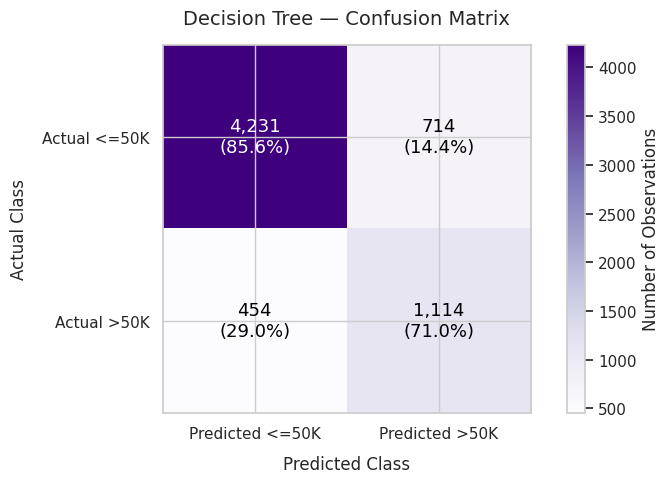

In [ ]:
# Decision Tree confusion matrix values
cm = decision_tree_cm

# Calculate percentages within each actual class
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(8, 5))

# Heatmap
im = ax.imshow(cm, cmap="Purples")

# Add counts and percentages
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # White text for the dark top-left quadrant
        text_color = "white" if (i == 0 and j == 0) else "black"

        ax.text(
            j,
            i,
            f"{cm[i, j]:,}\n({cm_percent[i, j]:.1f}%)",
            ha="center",
            va="center",
            fontsize=13,
            color=text_color
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Predicted <=50K", "Predicted >50K"])
ax.set_yticklabels(["Actual <=50K", "Actual >50K"])

ax.set_title(
    "Decision Tree — Confusion Matrix",
    fontsize=14,
    pad=15
)

ax.set_xlabel("Predicted Class", labelpad=10)
ax.set_ylabel("Actual Class", labelpad=10)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Number of Observations")

plt.tight_layout()
plt.show()

## 3.7 — ROC Curve
### Rationale
The ROC curve will evaluate how well the final tuned Decision Tree distinguishes between the <=50K and >50K income classes across classification thresholds. The ROC-AUC provides a threshold-independent measure of discrimination and allows the Decision Tree to be compared directly with the Logistic Regression and other models.

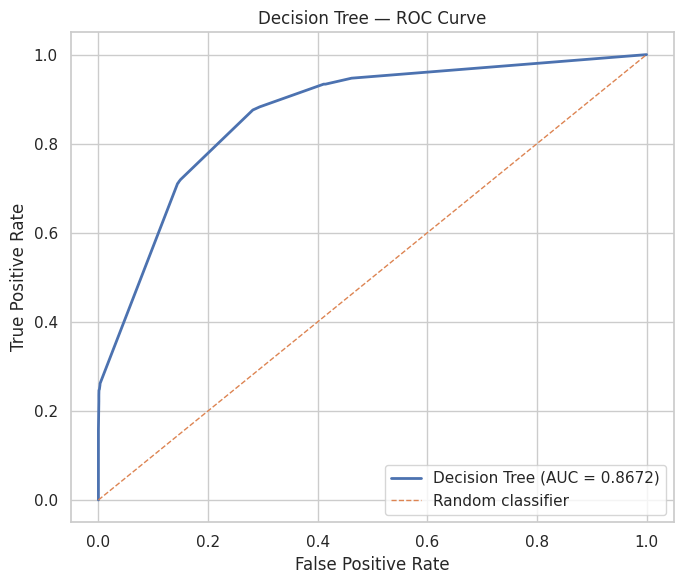

ROC-AUC: 0.8672


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC curve for the final Decision Tree
decision_tree_fpr, decision_tree_tpr, decision_tree_thresholds = roc_curve(
    y_test,
    decision_tree_y_prob
)

# Calculate ROC-AUC
decision_tree_roc_auc = roc_auc_score(
    y_test,
    decision_tree_y_prob
)

# Plot ROC curve
plt.figure(figsize=(7, 6))

plt.plot(
    decision_tree_fpr,
    decision_tree_tpr,
    linewidth=2,
    label=f"Decision Tree (AUC = {decision_tree_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree — ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {decision_tree_roc_auc:.4f}")

### Analysis
The final tuned Decision Tree achieved a holdout ROC-AUC of 0.8672, indicating good discrimination between the <=50K and >50K income classes. The ROC curve remains consistently above the random-classifier reference line, demonstrating that the model provides meaningful separation between the two income groups across classification thresholds. However, its ROC-AUC remains below the revised Logistic Regression model's 0.8994, indicating weaker overall discriminatory performance.

## 3.8 — Classification Report
### Rationale
A classification report will provide class-specific precision, recall, and F1 scores for the final tuned Decision Tree. Examining both income classes will show how the model balances identification of the minority >50K class against performance on the majority <=50K class.

In [ ]:
from sklearn.metrics import classification_report

decision_tree_report = classification_report(
    y_test,
    decision_tree_y_pred,
    target_names=["<=50K", ">50K"],
    digits=4
)

print("Decision Tree — Classification Report:")
print(decision_tree_report)

Decision Tree — Classification Report:
              precision    recall  f1-score   support

       <=50K     0.9031    0.8556    0.8787      4945
        >50K     0.6094    0.7105    0.6561      1568

    accuracy                         0.8207      6513
   macro avg     0.7563    0.7830    0.7674      6513
weighted avg     0.8324    0.8207    0.8251      6513



### Analysis

The classification report shows that the Decision Tree performs better on the majority `<=50K` class than on the `>50K` class. For `<=50K`, the model achieves 90.31% precision, 85.56% recall, and an F1 score of 87.87%, while the `>50K` class has lower precision of 60.94%, recall of 71.05%, and F1 score of 65.61%. The higher recall for the >50K class indicates that the Decision Tree identifies more high-income individuals than the revised Logistic Regression, although this comes with more false positives and lower precision.

## 3.9 — Feature Importance
### Rationale
Feature importance will be used to identify the predictors that contribute most to the final Decision Tree's classification decisions. This provides an interpretable summary of the model and allows the most influential features to be compared with the Logistic Regression findings and the relationships identified during the midpoint EDA.

In [ ]:
# Extract Decision Tree feature importances
decision_tree_importance = pd.DataFrame({
    "feature": X_train_tree.columns,
    "importance": decision_tree_final.feature_importances_
})

# Sort by importance
decision_tree_importance = (
    decision_tree_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Decision Tree Feature Importances:")
print(
    decision_tree_importance.head(15).to_string(index=False)
)

Top 15 Decision Tree Feature Importances:
                              feature  importance
    marital.status_Married-civ-spouse    0.479337
                      net.capital.log    0.366647
              education.group_HS-grad    0.066550
             education.group_Below-HS    0.058095
education.group_Graduate/Professional    0.016118
                    hours.group_41-60    0.010539
                    workclass_Private    0.001470
             occupation_Other-service    0.000413
           occupation_Farming-fishing    0.000358
                        age.group_65+    0.000269
          occupation_Transport-moving    0.000175
                      age.group_56-65    0.000030
               workclass_Never-worked    0.000000
             marital.status_Separated    0.000000
                  workclass_Local-gov    0.000000


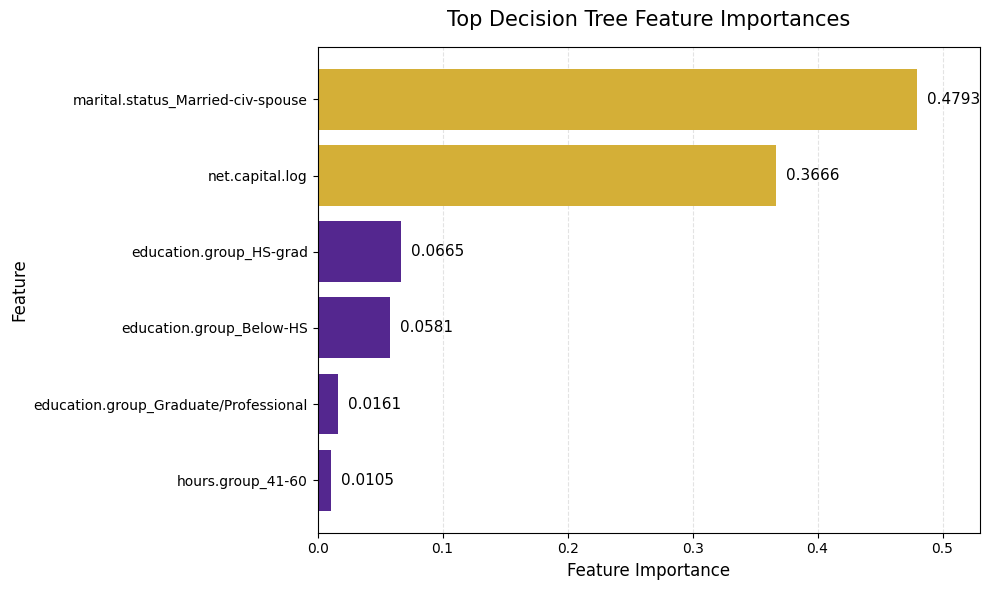

In [ ]:
import matplotlib.pyplot as plt

# Decision Tree feature importance data
features = [
    "marital.status_Married-civ-spouse",
    "net.capital.log",
    "education.group_HS-grad",
    "education.group_Below-HS",
    "education.group_Graduate/Professional",
    "hours.group_41-60"
]

importance = [
    0.479337,
    0.366647,
    0.066550,
    0.058095,
    0.016118,
    0.010539
]

# Colors: gold for top two, purple for remaining features
colors = [
    "#D4AF37",
    "#D4AF37",
    "#54278f",
    "#54278f",
    "#54278f",
    "#54278f"
]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    features[::-1],
    importance[::-1],
    color=colors[::-1]
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        fontsize=11
    )

ax.set_title(
    "Top Decision Tree Feature Importances",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)
ax.set_xlim(0, 0.53)

plt.tight_layout()
plt.show()

### Analysis

The final Decision Tree relies heavily on a small number of predictors. `marital.status_Married-civ-spouse` is the most important feature at 0.4793, followed by `net.capital.log` at 0.3666. Education-related features also contribute meaningfully, particularly `education.group_HS-grad` (0.0666), `education.group_Below-HS` (0.0581), and `education.group_Graduate/Professional` (0.0161), while the remaining predictors have relatively small or near-zero importance. These results are broadly consistent with the midpoint EDA, which identified marital status, education, and capital activity as important factors associated with income.

## 3.10 — Decision Tree Assumption and Complexity Assessment
### Rationale
Decision Trees do not require the linearity and feature-scaling assumptions associated with Logistic Regression, but model complexity must still be assessed to identify potential overfitting. The final tree's depth, number of leaves, and training versus cross-validation performance will be examined to determine whether the selected hyperparameters provide an appropriate balance between model complexity and generalization.

In [ ]:
# Fit the final Decision Tree on the full training data
decision_tree_final.fit(
    X_train_tree,
    y_train
)

print("Decision Tree depth:", decision_tree_final.get_depth())
print("Number of leaves:", decision_tree_final.get_n_leaves())

Decision Tree depth: 5
Number of leaves: 26


### Analysis

The tuned Decision Tree reached the selected maximum depth of 5 and contains 26 terminal leaves. This confirms that the tuning process produced a constrained tree rather than an unrestricted structure, reducing the risk of excessive complexity and overfitting. The combination of limited depth and a manageable number of leaves provides a balance between capturing nonlinear patterns and maintaining a model that can be interpreted and evaluated for generalization.

In [ ]:
# Calculate training performance for the final Decision Tree
decision_tree_train_results = evaluate_model_test(
    decision_tree_final,
    X_train_tree,
    y_train,
    X_train_tree,
    y_train
)[0]

print("Decision Tree — Training Performance:")
for metric, value in decision_tree_train_results.items():
    print(f"{metric}: {value:.4f}")

print("\nDecision Tree — Cross-Validation Performance:")
for metric, value in decision_tree_final_cv_summary.items():
    print(f"{metric}: {value:.4f}")

Decision Tree — Training Performance:
Accuracy: 0.8299
Precision: 0.6249
Recall: 0.7344
F1: 0.6753
ROC-AUC: 0.8814

Decision Tree — Cross-Validation Performance:
Accuracy: 0.8371
Precision: 0.6789
Recall: 0.6601
F1: 0.6596
ROC-AUC: 0.8804


### Analysis

The final Decision Tree has a depth of 5 and 26 terminal leaves, providing a relatively constrained model structure. Training performance is comparable to cross-validation performance, with training F1 of 0.6753 versus cross-validation F1 of 0.6596 and training ROC-AUC of 0.8814 versus cross-validation ROC-AUC of 0.8804. The small differences between training and cross-validation performance provide no strong indication of severe overfitting, supporting the selected tree complexity as a reasonable balance between model flexibility and generalization.

## 3.11 — Final Decision Tree Results Summary
### Rationale
The final results summary consolidates the performance and complexity findings for the selected Decision Tree model. This provides a single reference point for the team's overall model comparison and documents the final model configuration, cross-validation performance, holdout performance, and key complexity characteristics.

In [ ]:
# Final Decision Tree results summary
decision_tree_final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "5-Fold CV": [
        decision_tree_final_cv_summary["Accuracy"],
        decision_tree_final_cv_summary["Precision"],
        decision_tree_final_cv_summary["Recall"],
        decision_tree_final_cv_summary["F1"],
        decision_tree_final_cv_summary["ROC-AUC"]
    ],
    "Holdout Test": [
        decision_tree_test_results["Accuracy"],
        decision_tree_test_results["Precision"],
        decision_tree_test_results["Recall"],
        decision_tree_test_results["F1"],
        decision_tree_test_results["ROC-AUC"]
    ]
})

print("Final Decision Tree Configuration:")
print(f"Criterion: {decision_tree_final.criterion}")
print(f"Max depth: {decision_tree_final.max_depth}")
print(f"Min samples split: {decision_tree_final.min_samples_split}")
print(f"Min samples leaf: {decision_tree_final.min_samples_leaf}")
print(f"Number of leaves: {decision_tree_final.get_n_leaves()}")

print("\nFinal Performance:")
display(decision_tree_final_summary.round(4))

Final Decision Tree Configuration:
Criterion: gini
Max depth: 5
Min samples split: 2
Min samples leaf: 1
Number of leaves: 26

Final Performance:


,Metric,5-Fold CV,Holdout Test
0,Accuracy,0.8371,0.8207
1,Precision,0.6789,0.6094
2,Recall,0.6601,0.7105
3,F1,0.6596,0.6561
4,ROC-AUC,0.8804,0.8672


### Analysis

The final Decision Tree uses the `gini` criterion with a maximum depth of 5, `min_samples_split=2`, and `min_samples_leaf=1`, resulting in 26 terminal leaves. The model achieved a mean 5-fold cross-validation accuracy of 83.71%, F1 score of 65.96%, and ROC-AUC of 88.04%, while holdout performance was 82.07% accuracy, 65.61% F1, and 86.72% ROC-AUC. The close F1 and ROC-AUC values between cross-validation and holdout testing indicate reasonably consistent generalization, while the holdout results show higher recall (71.05%) but lower precision (60.94%) for the >50K class.

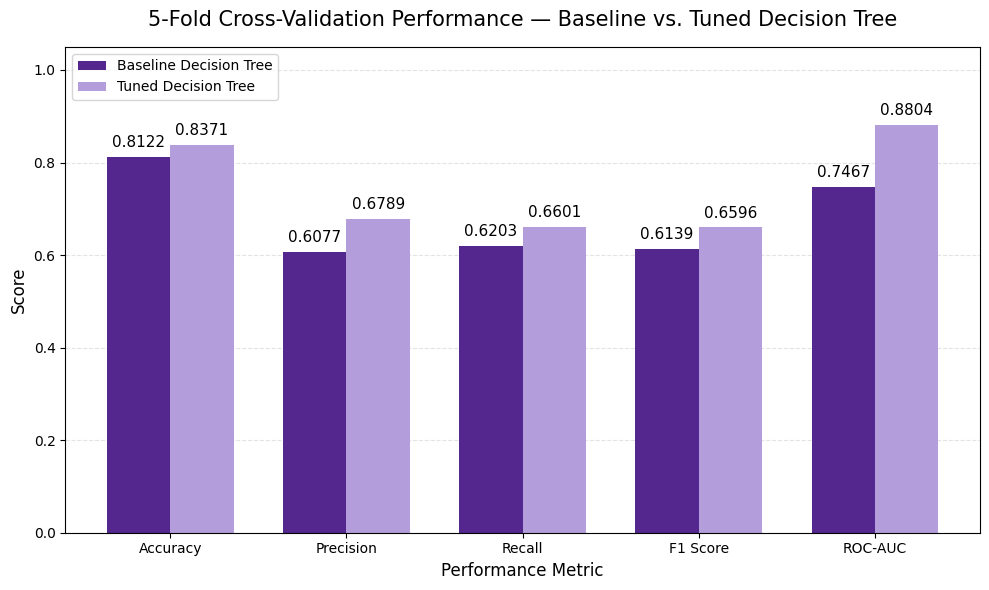

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 5-Fold Cross-Validation metrics
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

baseline_scores = [0.8122, 0.6077, 0.6203, 0.6139, 0.7467]
tuned_scores = [0.8371, 0.6789, 0.6601, 0.6596, 0.8804]

x = np.arange(len(metrics))
width = 0.36

# Purple color scheme used throughout the notebook
purple_dark = "#54278f"
purple_light = "#b39ddb"

fig, ax = plt.subplots(figsize=(10, 6))

bars_baseline = ax.bar(
    x - width / 2,
    baseline_scores,
    width,
    label="Baseline Decision Tree",
    color=purple_dark
)

bars_tuned = ax.bar(
    x + width / 2,
    tuned_scores,
    width,
    label="Tuned Decision Tree",
    color=purple_light
)

# Add value labels
for bars in [bars_baseline, bars_tuned]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.015,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

ax.set_title(
    "5-Fold Cross-Validation Performance — Baseline vs. Tuned Decision Tree",
    fontsize=15,
    pad=15
)

ax.set_xlabel("Performance Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(metrics)

ax.set_ylim(0, 1.05)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.set_axisbelow(True)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

### Model Performance Summary

| Model | CV Accuracy | CV Precision | CV Recall | CV F1 | CV ROC-AUC | Test Accuracy | Test Precision | Test Recall | Test F1 | Test ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Logistic Regression — Original | 0.8582 | 0.7480 | 0.6203 | 0.6781 | 0.9148 | 0.8589 | 0.7502 | 0.6205 | 0.6792 | 0.9086 |
| Logistic Regression — Revised | 0.8480 | 0.7208 | 0.6026 | 0.6563 | 0.9038 | 0.8508 | 0.7254 | 0.6116 | 0.6637 | 0.8994 |
| Decision Tree — Baseline | 0.8122 | 0.6077 | 0.6203 | 0.6139 | 0.7467 | — | — | — | — | — |
| Decision Tree — Tuned | 0.8371 | 0.6789 | 0.6601 | 0.6596 | 0.8804 | 0.8207 | 0.6094 | 0.7105 | 0.6561 | 0.8672 |
| Random Forest | — | — | — | — | — | — | — | — | — | — |
| Gradient Boosting | — | — | — | — | — | — | — | — | — | — |

# Phase 4 — Random Forest
### 4.1 Baseline Model
#### Rationale
A Random Forest classifier will be developed using the finalized 53-feature predictor set established after the multicollinearity assessment. RF aggregates many decorrelated decision trees, typically reducing the variance associated with a single Decision Tree but still able to capture nonlinear relationships and interactions among predictors.

In [ ]:
# Create Random Forest predictor sets
X_rf = X_logistic_v2.copy()

X_train_rf = X_rf.loc[X_train.index]
X_test_rf = X_rf.loc[X_test.index]

print("X_train_rf shape:", X_train_rf.shape)
print("X_test_rf shape:", X_test_rf.shape)

X_train_rf shape: (26048, 53)
X_test_rf shape: (6513, 53)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(random_state=42)

print(random_forest_model)

RandomForestClassifier(random_state=42)


## Analysis
The Random Forest was configured using the finalized 53-feature predictor set and the same 26,048 training and 6,513 hold out observations established by the 80/20 stratified split. The baseline model uses random_state=42 for reproducibility and does not require feature scaling because tree-based splits are invariant to the magnitude of the predictors. This establishes a reference point for evaluating the impact of subsequent hyperparameter tuning.

## 4.2 Basline Cross-Validation Evaluation
### Rationale
The baseline RF will be evaluated using the 5-fold Stratified KFold framework. Using the same folds and evaluation metrics as the other models allow the baseline forest to be compared fairly with other classifiers before hyperparameter tuning.

In [ ]:
# Evaluate baseline Random Forest with common CV framework
random_forest_cv_results, random_forest_cv_summary = (
    evaluate_model_cv(
        random_forest_model,
        X_train_rf,
        y_train
    )
)
print("Random Forest — Baseline 5-Fold CV Results:")
for metric, value in random_forest_cv_summary.items():
    print(f"{metric}: {value:.4f}")

Random Forest — Baseline 5-Fold CV Results:
Accuracy: 0.8399
Precision: 0.6898
Recall: 0.6094
F1: 0.6470
ROC-AUC: 0.8854


### Analysis
The baseline Random Forest achieved a mean 5-fold cross-validation accuracy of 83.99%, with precision of 68.98%, recall of 60.94%, and an F1 score of 64.70%. The model achieved a ROC-AUC of 88.54%, indicating strong discrimination between the <=50K and >50K income classes despite using default hyperparameters. Compared with the revised Logistic Regression (CV F1 0.6563, ROC-AUC 0.9038), the baseline Random Forest shows a slightly lower F1 score and a lower ROC-AUC. Compared with the tuned Decision Tree (CV F1 0.6596, ROC-AUC 0.8804), the baseline Random Forest achieves a marginally lower F1 but a higher ROC-AUC, suggesting that even without tuning, aggregating multiple trees improves the model's overall ability to rank observations by predicted probability relative to a single tree. This baseline provides a reasonable starting point, with hyperparameter tuning expected to further improve F1 and precision-recall balance.

## 4.3 Hyperparameter Tuning
### Rationale
Hyperparameter tuning will be used to identify a Random Forest configuration that improves predictive performance while controlling model complexity and training time. The tuning process focuses on parameters that are most influential to forest size, tree depth, and leaf size. The approach will be consistent to the one used for the Decision Tree.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid for Random Forest
random_forest_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split":[2, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_forest_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=random_forest_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)

print("Number of parameter combos:",
    len(random_forest_param_grid["n_estimators"])
    * len(random_forest_param_grid["max_depth"])
    * len(random_forest_param_grid["min_samples_leaf"])
    * len(random_forest_param_grid["min_samples_split"])
)

Number of parameter combos: 36


In [ ]:
# Run Random Forest hyperparameter tuning
random_forest_grid.fit(
    X_train_rf,
    y_train
)

print("Best parameters:")
print(random_forest_grid.best_params_)

print("\nBest cross-validation F1 score:")
print(f"{random_forest_grid.best_score_:.4f}")

Best parameters:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

Best cross-validation F1 score:
0.6707


### Analysis
The grid search selected `max_depth=None`, `min_samples_leaf=4`, `min_samples_split=2`, and `n_estimators=200` as the best-performing configuration, achieving a cross-validation F1 score of 0.6707. Unlike the Decision Tree, which favored a constrained maximum depth of 5 to control overfitting, the tuned Random Forest performs best with unlimited tree depth, since averaging predictions across 200 trees provides its own form of variance reduction, allowing individual trees to grow deeper without the same overfitting risk a single tree would face. The modest `min_samples_leaf=4` requirement adds a small amount of regularization at the leaf level. This tuned F1 of 0.6707 represents an improvement over the baseline Random Forest's CV F1 of 0.6470 from Section 4.2, confirming that hyperparameter tuning meaningfully improved the model's balance between precision and recall for the >50K class.

## 4.4 Final Model Cross-Validation Evaluation
### Rationale
The selected Random Forest configuration will be evaluated independently using the common 5-fold Stratified KFold framework. This confirms the performance of the tuned model using the same evaluation procedure applied to the other models. This will also provide the final metrics before holdout testing.

In [ ]:
# Create final tuned RF
random_forest_final = RandomForestClassifier(
    n_estimators=random_forest_grid.best_params_["n_estimators"],
    max_depth=random_forest_grid.best_params_["max_depth"],
    min_samples_split=random_forest_grid.best_params_["min_samples_split"],
    min_samples_leaf=random_forest_grid.best_params_["min_samples_leaf"],
    random_state=42
)

# Evaluate final tuned Random Forest with common CV framework
random_forest_final_cv_results, random_forest_final_cv_summary = (
    evaluate_model_cv(
        random_forest_final,
        X_train_rf,
        y_train
    )
)
print("Random Forest Final 5-Fold CV Results:")
for metric, value in random_forest_final_cv_summary.items():
    print(f"{metric}: {value:.4f}")


Random Forest Final 5-Fold CV Results:
Accuracy: 0.8590
Precision: 0.7668
Recall: 0.5962
F1: 0.6707
ROC-AUC: 0.9126


 ### Analysis
The final tuned Random Forest achieved a mean 5-fold cross-validation accuracy of 85.90%, with precision of 76.68%, recall of 59.62%, and an F1 score of 67.07%. The model achieved a ROC-AUC of 91.26%, a substantial improvement over the baseline Random Forest's ROC-AUC of 88.54% from Section 4.2. Compared with the baseline, the tuned model traded some recall (60.94% → 59.62%) for a notable gain in precision (68.98% → 76.68%), resulting in a higher overall F1 score (64.70% → 67.07%). This tuned Random Forest now slightly exceeds the revised Logistic Regression on both F1 (0.6707 vs. 0.6563) and ROC-AUC (0.9126 vs. 0.9038), and clearly outperforms the tuned Decision Tree on F1 (0.6707 vs. 0.6596) and ROC-AUC (0.9126 vs. 0.8804). These results suggest that, among the models evaluated so far, the tuned Random Forest provides the strongest overall balance of discrimination and classification performance.
 ## 4.5 Final Holdout Test Evaluation
 ### Rationale
 The final tuned RF will be evaluated on the holdout test set to measure out of sample performance after hyperparameter selection. This test set was not used during tuning so the final results will provide an estimate of how the selected forest is likelyto perform on new observations.

In [ ]:
# Final RF evaluation on the holdout test set
random_forest_test_results, random_forest_y_pred, random_forest_y_prob = (
    evaluate_model_test(
        random_forest_final,
        X_train_rf,
        y_train,
        X_test_rf,
        y_test
    )
)

print("Random Forest Final Holdout Test Results:")
for metric, value in random_forest_test_results.items():
    print(f"{metric}: {value:.4f}")

Random Forest Final Holdout Test Results:
Accuracy: 0.8581
Precision: 0.7688
Recall: 0.5874
F1: 0.6659
ROC-AUC: 0.9082


### Analysis
The final tuned Random Forest achieved 85.81% accuracy, 76.88% precision, 58.74% recall, and an F1 score of 66.59% on the holdout test set. The ROC-AUC of 90.82% indicates strong discrimination between the <=50K and >50K income classes. These holdout results are very close to the cross-validation results from Section 4.4 (Accuracy 85.90%, Precision 76.68%, Recall 59.62%, F1 67.07%, ROC-AUC 91.26%), with only minor decreases across all five metrics, suggesting the tuned model generalizes well to unseen data rather than overfitting to the training folds. Compared with the tuned Decision Tree's holdout results (Accuracy 82.07%, F1 65.61%, ROC-AUC 86.72%), the Random Forest achieves higher accuracy, F1, and ROC-AUC, though the Decision Tree's higher recall (71.05% vs. 58.74%) means it identifies a greater share of true >50K individuals at the cost of more false positives. The Random Forest's higher precision indicates it is more conservative in predicting the >50K class, prioritizing correctness of positive predictions over catching every high-income individual in the holdout set.
## 4.6 Confusion Matrix
### Rationale
A confusion matrix will be used to examine the types of classification errors made by the final tuned RF on the holdout test set. This provides class-specific insight into correct vs incorrect predictions and shows how the model balances identifying over $50k individuals against false positive predictions.

In [ ]:
from sklearn.metrics import confusion_matrix

random_forest_cm = confusion_matrix(
    y_test,
    random_forest_y_pred
)

print("Random Forest Confusion Matrix:")
print(random_forest_cm)

Random Forest Confusion Matrix:
[[4668  277]
 [ 647  921]]


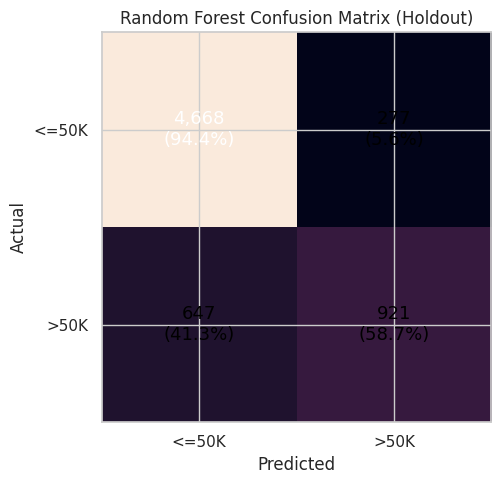

In [ ]:
cm = random_forest_cm

cm_percent = cm/cm.sum(axis=1, keepdims=True)*100

fig,ax = plt.subplots(figsize=(8,5))

im = ax.imshow(cm)

for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    text_color = "white" if (i==0 and j==0) else "black"

    ax.text(
        j,i,
        f"{cm[i,j]:,}\n({cm_percent[i,j]:.1f}%)",
        ha="center",va="center",
        fontsize=13,
        color=text_color
    )
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["<=50K", ">50K"])
ax.set_yticklabels(["<=50K", ">50K"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest Confusion Matrix (Holdout)")

plt.tight_layout()
plt.show()


### Analysis
The confusion matrix shows that the Random Forest correctly classified 4,668 individuals earning <=50K and 921 individuals earning >50K on the holdout set. The model produced 277 false positives and 647 false negatives, meaning it missed substantially more >50K individuals than it incorrectly classified as >50K. This pattern is consistent with the model's holdout recall of 58.74%, which is notably lower than its precision of 76.88%: when the Random Forest predicts >50K, it is right about 77% of the time, but it only identifies about 59% of all actual >50K individuals in the data. Compared with the tuned Decision Tree, which produced 714 false positives and 454 false negatives, the Random Forest shows the opposite error pattern: it is more conservative, generating fewer false positives (277 vs. 714) but more false negatives (647 vs. 454). This reflects the precision/recall tradeoff visible in the two models: the Decision Tree favors catching more true >50K cases at the cost of misclassifying more <=50K individuals, while the Random Forest favors being correct when it does predict >50K, at the cost of missing a larger share of the minority class.
## 4.7 ROC Curve
### Rationale
The ROC curve will evaluate how well the final tuned model distinguishes between the <= 50k and > 50k income classes across classification thresholds. The ROC-AUC provides a threshold-independent measure of discrimination and allow the Random Forest to be compared directly with other classifiers.

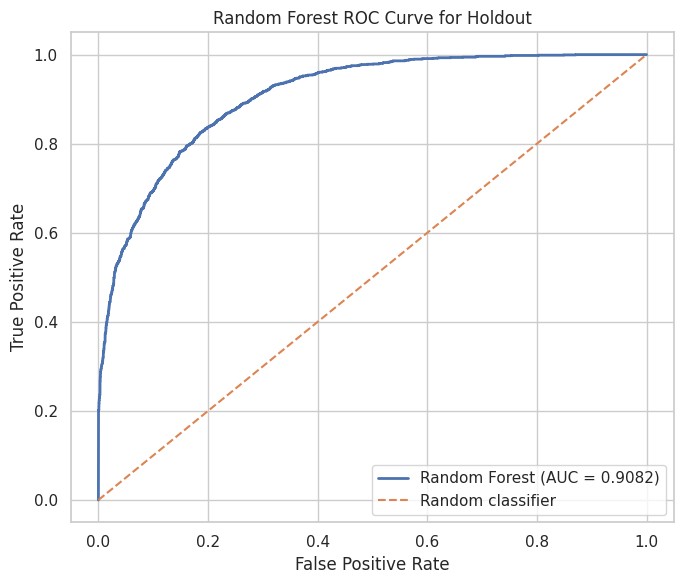

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
random_forest_fpr, random_forest_tpr, random_forest_thresholds = roc_curve(
    y_test,
    random_forest_y_prob
)

# Calculate ROC-AUC
random_forest_roc_auc = roc_auc_score(
    y_test,
    random_forest_y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    random_forest_fpr,
    random_forest_tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {random_forest_roc_auc:.4f})"
)

plt.plot([0,1],[0,1], linestyle = "--", label = "Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve for Holdout")
plt.legend()
plt.tight_layout()
plt.show()


### Analysis
The Random Forest ROC curve lies well above the random-classifier reference line across the entire range of false-positive rates, indicating strong separation between the <=50K and >50K income classes. The holdout ROC-AUC of 0.9082 confirms that the model has strong overall discriminatory ability across classification thresholds, exceeding both the revised Logistic Regression's holdout ROC-AUC of 0.8994 and the tuned Decision Tree's holdout ROC-AUC of 0.8672. The curve rises particularly steeply at low false-positive rates, showing that a substantial share of true positives can be captured while keeping false positives to a minimum, this reinforces that the recall limitations observed in the confusion matrix reflect the default 0.5 classification threshold rather than a lack of underlying separability, and suggest that adjusting the decision threshold could recover additional recall if the business use case prioritizes catching more >50K individuals over minimizing false positives.
##4.8 Classification Report
### Rationale
A classification report will provide class-specific precision, recall, and F1 scores for the final tuned RF. Examining both income classes will show how the model balances identification of the minority against performance on the majority.

In [ ]:
from sklearn.metrics import classification_report

random_forest_report = classification_report(
    y_test,
    random_forest_y_pred,
    target_names=["<=50k", ">50k"],
    digits=4
)
print("Random Forest Classification Report")
print(random_forest_report)

Random Forest Classification Report
              precision    recall  f1-score   support

       <=50k     0.8783    0.9440    0.9099      4945
        >50k     0.7688    0.5874    0.6659      1568

    accuracy                         0.8581      6513
   macro avg     0.8235    0.7657    0.7879      6513
weighted avg     0.8519    0.8581    0.8512      6513



### Analysis
The classification report shows that the Random Forest performs substantially better on the majority `<=50K` class than on the `>50K` class. For `<=50K`, the model achieves 87.83% precision, 94.40% recall, and a 90.99% F1 score, while performance for the `>50K` class is lower at 76.88% precision, 58.74% recall, and a 66.59% F1 score. The gap between the two classes' recall values (94.40% vs. 58.74%) is the most notable pattern: the model correctly identifies the vast majority of <=50K individuals but misses over 40% of actual >50K individuals. This is consistent with the confusion matrix results from Section 4.6 and reflects the model's conservative approach to predicting the minority class. The macro average F1 of 0.7879, which weights both classes equally, is noticeably lower than the weighted average F1 of 0.8512, which is dominated by the majority class's strong performance. This gap underscores why F1 and ROC-AUC on the >50K class specifically, rather than overall accuracy, are the more meaningful metrics for evaluating this model against the project's objective of identifying higher-income individuals.
## 4.9 Feature Importance
###Rationale
Feature importance will be used to identify the predictors that contribute the most to the final Random Forest's classification decisions. Because RF aggregates across many trees, its rankings are typically more stable than a single Decision Tree's and comparing the two gives more insight into which relationships are robust vs. tree specific.

In [ ]:
# Extract RF feature importances
random_forest_importance = pd.DataFrame({
    "feature": X_train_rf.columns,
    "importance": random_forest_final.feature_importances_
})

# Sort by importance
random_forest_importance = (
    random_forest_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Random Forest Feature Importances:")
print(
    random_forest_importance.head(15).to_string(index=False)
)

Top 15 Random Forest Feature Importances:
                              feature  importance
                      net.capital.log    0.178884
    marital.status_Married-civ-spouse    0.167539
                   has.capital.change    0.060029
                               fnlwgt    0.056930
         marital.status_Never-married    0.056705
           occupation_Exec-managerial    0.039333
             education.group_Below-HS    0.036448
                    hours.group_41-60    0.035246
            occupation_Prof-specialty    0.028801
              education.group_HS-grad    0.027991
           relationship_Not-in-family    0.027177
                             sex_Male    0.026260
education.group_Graduate/Professional    0.025280
               relationship_Own-child    0.021755
                      age.group_46-55    0.018124


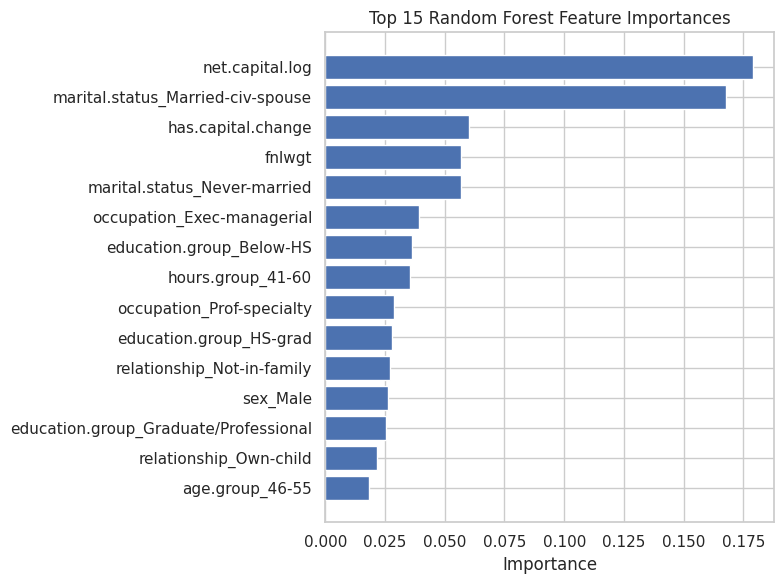

In [ ]:
# Visualizations
top_rf_importance = random_forest_importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(
    top_rf_importance["feature"][::-1],
    top_rf_importance["importance"][::-1]
)

plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

### Analysis
The top predictors identified by the Random Forest are `net.capital.log` and `marital.status_Married-civ-spouse`, which together stand out well above the rest of the feature set, followed by `has.capital.change`, `fnlwgt`, and `marital.status_Never-married`. This partially overlaps with the Decision Tree's top features (`marital.status_Married-civ-spouse` and `net.capital.log`), confirming that capital activity and marital status are robust predictors of income that are not specific to a single tree's structure. However, unlike the Decision Tree, where these two features dominated with combined importance near 0.85, the Random Forest spreads importance more evenly across a broader set of predictors: occupation categories (`Exec-managerial`, `Prof-specialty`), education groups, `hours.group_41-60`, and relationship/sex indicators all contribute meaningfully. This is expected behavior for Random Forest, since averaging across many decorrelated trees prevents any single feature from dominating every tree's splits the way it can in a single Decision Tree, and provides a more distributed, and arguably more stable, view of which factors drive income prediction across the dataset.
## 4.10 Final Random Forest Results Summary
### Rationale
The final results summary consolidates the performance findings for the selected RF model. This is a single reference point for our team's overall model comparison and documents the final model configuration, cross-validatiion performance, and holdout performance.

In [ ]:
random_forest_final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "5-Fold CV": [
        random_forest_final_cv_summary["Accuracy"],
        random_forest_final_cv_summary["Precision"],
        random_forest_final_cv_summary["Recall"],
        random_forest_final_cv_summary["F1"],
        random_forest_final_cv_summary["ROC-AUC"]
    ],
    "Holdout Test": [
        random_forest_test_results["Accuracy"],
        random_forest_test_results["Precision"],
        random_forest_test_results["Recall"],
        random_forest_test_results["F1"],
        random_forest_test_results["ROC-AUC"]
    ]
})

random_forest_final_summary

,Metric,5-Fold CV,Holdout Test
0,Accuracy,0.859030,0.858130
1,Precision,0.766813,0.768781
2,Recall,0.596208,0.587372
3,F1,0.670706,0.665944
4,ROC-AUC,0.912594,0.908182


### Analysis
The final Random Forest was tuned with `max_depth=None`, `min_samples_leaf=4`, `min_samples_split=2`, and `n_estimators=200`. The model achieved a mean 5-fold cross-validation accuracy of 85.90%, F1 score of 67.07%, and ROC-AUC of 91.26%, while holdout performance was 85.81% accuracy, 66.59% F1, and 90.82% ROC-AUC. The close agreement between cross-validation and holdout metrics across all five measures indicates that the model generalizes well and is not overfit to the training folds. Among the three models evaluated so far, Random Forest achieves the highest F1 and ROC-AUC on both cross-validation and the holdout set, outperforming the revised Logistic Regression (holdout F1 0.6637, ROC-AUC 0.8994) and the tuned Decision Tree (holdout F1 0.6561, ROC-AUC 0.8672). This improvement comes primarily from higher precision rather than higher recall. The Random Forest is more conservative in predicting the >50K class than the Decision Tree, but substantially more accurate when it does so.

### Model Performance Summary

| Model | CV Accuracy | CV Precision | CV Recall | CV F1 | CV ROC-AUC | Test Accuracy | Test Precision | Test Recall | Test F1 | Test ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Logistic Regression — Revised | 0.8480 | 0.7208 | 0.6026 | 0.6563 | 0.9038 | 0.8508 | 0.7254 | 0.6116 | 0.6637 | 0.8994 |
| Decision Tree — Final | 0.8371 | 0.6789 | 0.6601 | 0.6596 | 0.8804 | 0.8207 | 0.6094 | 0.7105 | 0.6561 | 0.8672 |
| Random Forest — Final | 0.8590 | 0.7668 | 0.5962 | 0.6707 | 0.9126 | 0.8581 | 0.7688 | 0.5874 | 0.6659 | 0.9082 |

## 4.11 Business Impact, Practicality, and Extensions
### Rationale
Beyond predictive performance, Random Forest model depends on how it can realistically be used by a business, what it would cost or save in time and resources, and whether the approach generalized to similar problems.

### $/Hours Impact

### Practicality

### Possible Extensions


# Phase 5 Gradient Boosting
## 5.1 Model Setup
### Rationale
A gradient boosting classifier will be developed using the same predictor set as prior. Unlike RF, Gradient Boosting will build the trees sequentially, each tree correcting the errors of the previous. This provides a useful contrast to the other models while maintaining consistency in the feature set.

In [ ]:
X_gb = X_logistic_v2.copy()

X_train_gb = X_gb.loc[X_train.index]
X_test_gb = X_gb.loc[X_test.index]

print("X_train_gb shape:", X_train_gb.shape)
print("X_test_gb shape:", X_test_gb.shape)

X_train_gb shape: (26048, 53)
X_test_gb shape: (6513, 53)


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gradent_boosting_model = GradientBoostingClassifier(random_state=42)

print(gradent_boosting_model)

GradientBoostingClassifier(random_state=42)


### Analysis
The Gradient Boosting model was configured using the finalized predictor set. The baseline model used random_state=42 for reproducibility and does not require feature scaling because it splits on feature thresholds rather than predictor magnitude.

## 5.2 Baseline Cross Validation Evaluation
### Rationale
The baseline Gradient Boosting model will be evaluated with the 5-fold Stratified KFold framwork allowing it to be compared to the other models before hyperparameter tuning.

In [ ]:
gradient_boosting_cv_results, gradient_boosting_cv_summary = (
    evaluate_model_cv(
        gradent_boosting_model,
        X_train_gb,
        y_train
    )
)
print("Gradient Boosting Baseline 5 Fold CV Results:")
for metric, value in gradient_boosting_cv_summary.items():
  print(f"{metric}: {value:.4f}")

Gradient Boosting Baseline 5 Fold CV Results:
Accuracy: 0.8655
Precision: 0.7901
Recall: 0.6013
F1: 0.6828
ROC-AUC: 0.9191


### Analysis
The baseline Gradient Boosting model achieved a mean 5-fold cross-validation accuracy of 86.55%, with precision of 79.01%, recall of 60.13%, and an F1 score of 68.28%. The model achieved a ROC-AUC of 91.91%, the strongest baseline ROC-AUC of any model evaluated so far, even before hyperparameter tuning. Compared with the baseline Random Forest (CV F1 0.6470, ROC-AUC 0.8854) from Section 4.2, the baseline Gradient Boosting already outperforms it on every metric, and its baseline F1 (0.6828) and ROC-AUC (0.9191) even exceed the *tuned* Random Forest's results (F1 0.6707, ROC-AUC 0.9126) from Section 4.4. This is consistent with Gradient Boosting's sequential, error-correcting approach, which often extracts more predictive signal from structured tabular data than bagging-based methods like Random Forest, even without tuning. This strong baseline suggests hyperparameter tuning may yield more modest additional gains than it did for the other two tree-based models.
## 5.3 Hyperparameter Tuning
### Rationale
Hyperparameter tuning will be used to identify a Gradient Boosting configuration that improves predictive performance while controlling overfitting. The tuning process focuses on n_estimators, learning_rate, and max_depth since boosting performance is particularely sensitive to the relationship between the number of boosting stages, step size, and depth of each tree. The tuning approach is consistent applied to the previous models.

In [ ]:
from sklearn.model_selection import GridSearchCV

gradient_boosting_param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4]
}

gradient_boosting_grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gradient_boosting_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True
)


print("Number of parameter combos:",
      len(gradient_boosting_param_grid["n_estimators"])
      * len(gradient_boosting_param_grid["learning_rate"])
      * len(gradient_boosting_param_grid["max_depth"])
)

Number of parameter combos: 12


In [ ]:
gradient_boosting_grid.fit(
    X_train_gb,
    y_train
)

print("Best parameters:")
print(gradient_boosting_grid.best_params_)

print("\nBest cross-validation F1 score:")
print(f"{gradient_boosting_grid.best_score_:.4f}")

Best parameters:
{'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400}

Best cross-validation F1 score:
0.7061


### Analysis
The grid search selected `learning_rate=0.05`, `max_depth=4`, and `n_estimators=400` as the best-performing configuration, achieving a cross-validation F1 score of 0.7061. This is the highest CV F1 score of any model evaluated in the project so far, surpassing the tuned Random Forest's CV F1 of 0.6707 from Section 4.3 and the revised Logistic Regression's CV F1 of 0.6563. The tuning process favored a lower learning rate paired with a larger number of boosting stages (400 estimators) and moderately deep individual trees (max_depth=4), a combination that typically produces a more stable and accurate ensemble than a higher learning rate with fewer estimators, since each tree makes smaller, more conservative corrections to the ensemble's errors. This represents a substantial improvement over the baseline Gradient Boosting's CV F1 of 0.6828 from Section 5.2, confirming that tuning meaningfully improved the model's balance between precision and recall for the >50K class.
## 5.4 Final Model Cross Validation Evaluation
### Rationale
The selected Gradient Boosting configuration will be evaluated using the 5-fold Stratified KFold framework, confirming that the model's performance can be applied to the other models before holdout testing.

In [ ]:
gradient_boosting_final = GradientBoostingClassifier(
    n_estimators=gradient_boosting_grid.best_params_["n_estimators"],
    learning_rate=gradient_boosting_grid.best_params_["learning_rate"],
    max_depth=gradient_boosting_grid.best_params_["max_depth"],
    random_state=42
)

gradient_boosting_final_cv_results, gradient_boosting_final_cv_summary = evaluate_model_cv(
    gradient_boosting_final,
    X_train_gb,
    y_train
)
print("Gradient Boosting Final 5-Fold CV Results:")
for metric, value in gradient_boosting_final_cv_summary.items():
  print(f"{metric}: {value:.4f}")

Gradient Boosting Final 5-Fold CV Results:
Accuracy: 0.8711
Precision: 0.7831
Recall: 0.6429
F1: 0.7061
ROC-AUC: 0.9261


### Analysis
The final tuned Gradient Boosting model achieved a mean 5-fold cross-validation accuracy of 87.11%, with precision of 78.31%, recall of 64.29%, and an F1 score of 70.61%. The model achieved a ROC-AUC of 92.61%, the highest of any model developed in the project. Compared with the baseline Gradient Boosting from Section 5.2, tuning improved recall substantially (60.13% → 64.29%) while precision decreased only slightly (79.01% → 78.31%), producing a clear overall gain in F1 (68.28% → 70.61%) and ROC-AUC (91.91% → 92.61%). This tuned model now outperforms every other model evaluated in the project: it exceeds the tuned Random Forest on F1 (0.7061 vs. 0.6707) and ROC-AUC (0.9261 vs. 0.9126), and shows a markedly better recall than the Random Forest's 0.5962, meaning the Gradient Boosting model identifies a substantially larger share of actual >50K individuals while still maintaining strong precision. These results position Gradient Boosting as the strongest-performing model in the team's evaluation framework so far.
## 5.5 Final Holdout Test Evaluation
### Rationale
The final tuned Gradient Boosting model will be evaluated on the untouched holdout test set to measure out of sample performance after the hyperparameter selection. This will give us an estimate of how the model is likely to perform on new observations.

In [ ]:
gradient_boosting_test_results, gradient_boosting_y_pred, gradient_boosting_y_prob = evaluate_model_test(
    gradient_boosting_final,
    X_train_gb,
    y_train,
    X_test_gb,
    y_test
)

print("Gradient Boosting Final Holdout Test Results:")
for metric, value in gradient_boosting_test_results.items():
  print(f"{metric}: {value:.4f}")

Gradient Boosting Final Holdout Test Results:
Accuracy: 0.8701
Precision: 0.7865
Recall: 0.6320
F1: 0.7008
ROC-AUC: 0.9224


### Analysis
The final tuned Gradient Boosting model achieved 87.01% accuracy, 78.65% precision, 63.20% recall, and an F1 score of 70.08% on the holdout test set. The ROC-AUC of 92.24% indicates the strongest discrimination between the <=50K and >50K income classes of any model developed in the project. These holdout results are very close to the cross-validation results from Section 5.4 (Accuracy 87.11%, Precision 78.31%, Recall 64.29%, F1 70.61%, ROC-AUC 92.61%), with only small decreases across all five metrics, indicating the tuned model generalizes well to unseen data rather than overfitting to the training folds. Compared with the tuned Random Forest's holdout results (Accuracy 85.81%, Precision 76.88%, Recall 58.74%, F1 66.59%, ROC-AUC 90.82%), Gradient Boosting outperforms on every metric,  notably achieving both higher precision and substantially higher recall (63.20% vs. 58.74%), rather than trading one for the other. This makes Gradient Boosting the best-performing model across all four developed in the project, on both cross-validation and holdout evaluation.
##5.6 Confusion Matrix
### Rationale
A confusion matrix will be used to examine the types of classification errors made by the final tuned model on the holdout test set. This will give us insights into correct and incorrect predictions.

In [ ]:
from sklearn.metrics import confusion_matrix

gradient_boosting_cm = confusion_matrix(
    y_test,
    gradient_boosting_y_pred
)

print("Gradient Boosting Confusion Matrix:")
print(gradient_boosting_cm)

Gradient Boosting Confusion Matrix:
[[4676  269]
 [ 577  991]]


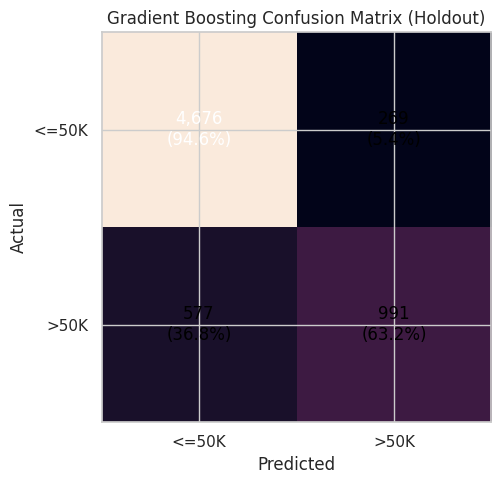

In [ ]:
cm = gradient_boosting_cm

cm_percent = cm/cm.sum(axis=1, keepdims=True)*100
fig,ax = plt.subplots(figsize=(8,5))

im = ax.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text_color = "white" if (i == 0 and j == 0) else "black"

        ax.text(
            j, i,
            f"{cm[i, j]:,}\n({cm_percent[i, j]:.1f}%)",
            ha="center", va="center",
            color=text_color, fontsize=12
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["<=50K", ">50K"])
ax.set_yticklabels(["<=50K", ">50K"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Gradient Boosting Confusion Matrix (Holdout)")

plt.tight_layout()
plt.show()

### Analysis
The confusion matrix shows that the tuned Gradient Boosting model correctly classified 4,676 individuals earning <=50K and 991 individuals earning >50K on the holdout set. The model produced 269 false positives and 577 false negatives, meaning it still misses more >50K individuals than it misclassifies as >50K, but by a narrower margin than the other tree-based models. Compared with the Random Forest (277 false positives, 647 false negatives), Gradient Boosting achieves a nearly identical false-positive count while substantially reducing false negatives, correctly identifying 70 more true >50K individuals. Compared with the Decision Tree (714 false positives, 454 false negatives), Gradient Boosting trades a modest increase in false negatives for a much larger reduction in false positives. Overall, Gradient Boosting achieves the best balance of the three tree-based models, avoiding the heavy false-positive cost of the Decision Tree while improving on the Random Forest's weaker recall, consistent with its highest holdout F1 score (70.08%) among all four models evaluated.
## 5.7 ROC Curve
### Rationale
The ROC curve will evaluate how well the final model is able to distinguish between the income classes across classification thresholds. This allows direct comparison with the other three models.

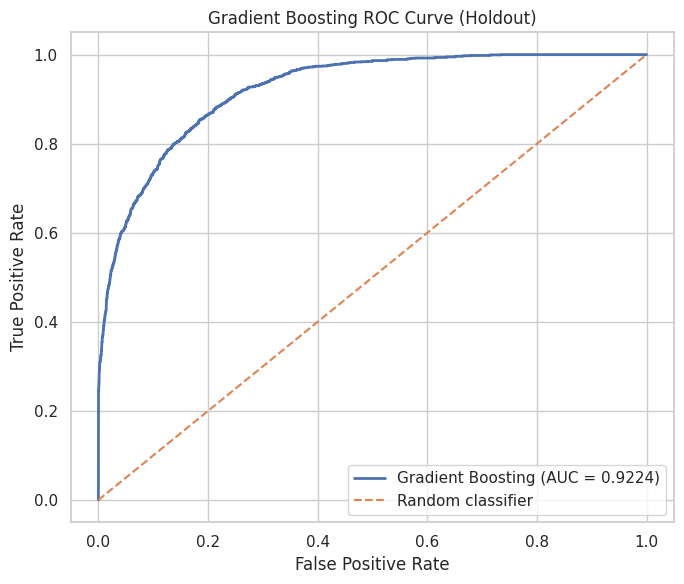

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

gradient_boosting_fpr, gradient_boosting_tpr, gradient_boosting_thresholds = roc_curve(
    y_test,
    gradient_boosting_y_prob
)

gradient_boosting_roc_auc = roc_auc_score(
    y_test,
    gradient_boosting_y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    gradient_boosting_fpr,
    gradient_boosting_tpr,
    linewidth=2,
    label=f"Gradient Boosting (AUC = {gradient_boosting_roc_auc:.4f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve (Holdout)")
plt.legend()
plt.tight_layout()
plt.show()

### Analysis
The Gradient Boosting ROC curve lies well above the random-classifier reference line across the entire range of false-positive rates, and visibly hugs the top-left corner more closely than any of the other three models' curves. The holdout ROC-AUC of 0.9224 is the highest achieved in the project, exceeding the Random Forest (0.9082), the revised Logistic Regression (0.8994), and the tuned Decision Tree (0.8672). The curve's steep initial rise indicates that Gradient Boosting can capture a large share of true positives while keeping the false-positive rate low, confirming that its sequential error-correction approach produces the strongest overall class separability of the four models evaluated. As with Random Forest, this strong ROC-AUC suggests there is room to shift the classification threshold below 0.5 to further improve recall on the >50K class, if the business use case calls for prioritizing identification of high-income individuals over minimizing false positives.

## 5.8 Classification Report
### Rationale
A classification report will provide class specific precision, recall, and F1 scores for the final model. It will show how it balances identification of the minority class against the performanc on the majority class.

In [ ]:
from sklearn.metrics import classification_report

gradient_boosting_report = classification_report(
    y_test,
    gradient_boosting_y_pred,
    target_names=["<=50K", ">50K"],
    digits=4
)

print("Gradient Boosting Classification Report:")
print(gradient_boosting_report)

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

       <=50K     0.8902    0.9456    0.9170      4945
        >50K     0.7865    0.6320    0.7008      1568

    accuracy                         0.8701      6513
   macro avg     0.8383    0.7888    0.8089      6513
weighted avg     0.8652    0.8701    0.8650      6513



### Analysis
The classification report shows that Gradient Boosting performs better on the majority `<=50K` class than on the `>50K` class, though the gap between the two classes is narrower than for any other model developed in the project. For `<=50K`, the model achieves 89.02% precision, 94.56% recall, and a 91.70% F1 score, while the `>50K` class achieves 78.65% precision, 63.20% recall, and a 70.08% F1 score. The macro average F1 of 0.8089 and weighted average F1 of 0.8650 are both the highest among the four models evaluated, and the smaller gap between macro and weighted averages compared with Random Forest (0.7879 vs. 0.8512) indicates more balanced performance across both classes rather than performance driven primarily by the majority class. This makes Gradient Boosting the strongest model in the project both overall and specifically on the >50K class that the evaluation framework prioritizes, though a recall of 63.20% still means over a third of actual >50K individuals are misclassified, leaving room for further improvement through threshold adjustment or additional tuning.
## 5.9 Feature Importance
### Rationale
Feature importance will be used to identify the predictors that contribute the most to the final model's classification decisions. Comparing these rankings with other models will show which relationships are consistently identified as important across the different approaches vs what variables are specific to the model.

In [ ]:
gradient_boosting_importance = pd.DataFrame({
    "feature": X_train_gb.columns,
    "importance": gradient_boosting_final.feature_importances_
})

gradient_boosting_importance = (
    gradient_boosting_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 Gradient Boosting Feature Importances:")
print(
    gradient_boosting_importance.head(15).to_string(index=False)
)


Top 15 Gradient Boosting Feature Importances:
                              feature  importance
    marital.status_Married-civ-spouse    0.376321
                      net.capital.log    0.310826
             education.group_Below-HS    0.043000
              education.group_HS-grad    0.037384
           occupation_Exec-managerial    0.030824
            occupation_Prof-specialty    0.029451
                               fnlwgt    0.022600
                    hours.group_41-60    0.021711
         education.group_Some-college    0.016618
education.group_Graduate/Professional    0.015178
                      age.group_46-55    0.012871
                      age.group_36-45    0.010165
              education.group_Masters    0.006467
             occupation_Other-service    0.006245
                      age.group_56-65    0.004962


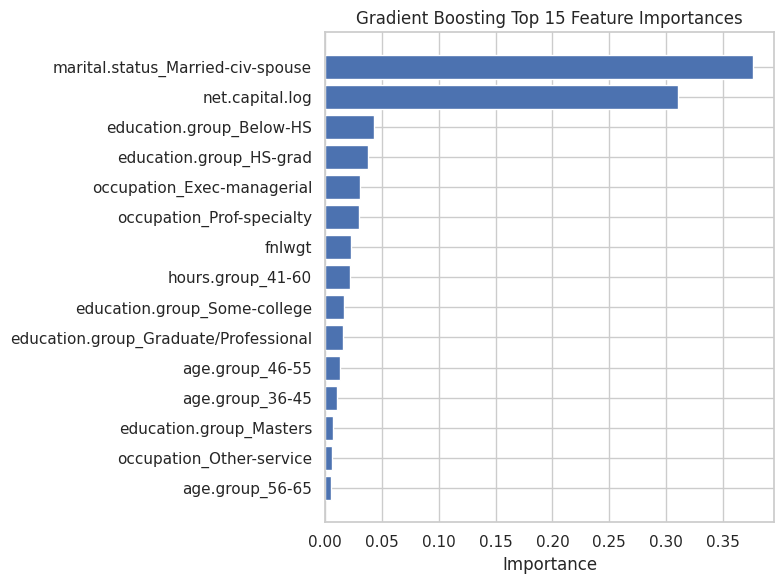

In [ ]:
top_gb_importance = gradient_boosting_importance.head(15)

plt.figure(figsize=(8, 6))
plt.barh(
    top_gb_importance["feature"][::-1],
    top_gb_importance["importance"][::-1],
)
plt.xlabel("Importance")
plt.title("Gradient Boosting Top 15 Feature Importances")
plt.tight_layout()
plt.show()

### Analysis
The top predictors for Gradient Boosting are `marital.status_Married-civ-spouse` and `net.capital.log`, which together account for the large majority of total importance, a pattern that closely mirrors the Decision Tree, where the same two features dominated, but is notably more concentrated than the Random Forest, where importance was spread more evenly across a broader set of features. This convergence across all three tree-based models on `marital.status_Married-civ-spouse` and `net.capital.log` as the two strongest predictors is a strong signal that these relationships are robust and not an artifact of any single algorithm. Beyond the top two, Gradient Boosting's next-most-important features are education groups (`Below-HS`, `HS-grad`), occupation categories (`Exec-managerial`, `Prof-specialty`), and `hours.group_41-60`, largely consistent with the Random Forest's broader importance rankings, reinforcing that education, occupation, and hours worked are secondary but meaningful contributors to predicted income across the different modeling approaches.
## 5.10 Final Gradient Boosting Results Summary
###Rationale
The final results will consolidate the performance findings for the model, providing a single reference point for our team's model comparison.

In [ ]:
gradient_boosting_final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "5-Fold CV": [
        gradient_boosting_final_cv_summary["Accuracy"],
        gradient_boosting_final_cv_summary["Precision"],
        gradient_boosting_final_cv_summary["Recall"],
        gradient_boosting_final_cv_summary["F1"],
        gradient_boosting_final_cv_summary["ROC-AUC"]
    ],
    "Holdout Test": [
        gradient_boosting_test_results["Accuracy"],
        gradient_boosting_test_results["Precision"],
        gradient_boosting_test_results["Recall"],
        gradient_boosting_test_results["F1"],
        gradient_boosting_test_results["ROC-AUC"]
    ]
})

gradient_boosting_final_summary

,Metric,5-Fold CV,Holdout Test
0,Accuracy,0.871084,0.870106
1,Precision,0.783089,0.786508
2,Recall,0.642917,0.632015
3,F1,0.706055,0.700849
4,ROC-AUC,0.926066,0.922448


### Analysis
The final Gradient Boosting model was tuned with `learning_rate=0.05`, `max_depth=4`, and `n_estimators=400`. The model achieved a mean 5-fold cross-validation accuracy of 87.11%, F1 score of 70.61%, and ROC-AUC of 92.61%, while holdout performance was 87.01% accuracy, 70.08% F1, and 92.24% ROC-AUC. The close agreement between cross-validation and holdout metrics across all five measures indicates that the model generalizes well and is not overfit to the training folds. Among all four models developed in the project, Gradient Boosting achieves the highest F1 and ROC-AUC on both cross-validation and the holdout set, outperforming the tuned Random Forest (holdout F1 0.6659, ROC-AUC 0.9082), the revised Logistic Regression (holdout F1 0.6637, ROC-AUC 0.8994), and the tuned Decision Tree (holdout F1 0.6561, ROC-AUC 0.8672). Unlike Random Forest, which improved primarily through higher precision at the cost of recall, Gradient Boosting achieves its stronger performance with meaningfully higher recall as well, making it the best-balanced and best-performing model in the team's overall evaluation framework.

### Model Performance Summary — All Four Models

| Model | CV Accuracy | CV Precision | CV Recall | CV F1 | CV ROC-AUC | Test Accuracy | Test Precision | Test Recall | Test F1 | Test ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Logistic Regression — Revised | 0.8480 | 0.7208 | 0.6026 | 0.6563 | 0.9038 | 0.8508 | 0.7254 | 0.6116 | 0.6637 | 0.8994 |
| Decision Tree — Final | 0.8371 | 0.6789 | 0.6601 | 0.6596 | 0.8804 | 0.8207 | 0.6094 | 0.7105 | 0.6561 | 0.8672 |
| Random Forest — Final | 0.8590 | 0.7668 | 0.5962 | 0.6707 | 0.9126 | 0.8581 | 0.7688 | 0.5874 | 0.6659 | 0.9082 |
| Gradient Boosting — Final | 0.8711 | 0.7831 | 0.6429 | 0.7061 | 0.9261 | 0.8701 | 0.7865 | 0.6320 | 0.7008 | 0.9224 |

## 5.11 Model Deployment and Automation Strategy
### Rationale
Beyond model performance, a practical deployment plan describes how the best performing model would be put into production, updated, and monitored over time.

### Serving Approach
Because predicting income from demographic and employment attributes is not a latency-sensitive task, the model is well suited to **batch scoring** rather than a real-time API. New or updated records would be scored on a recurring schedule (e.g., nightly or weekly), with the fitted `gradient_boosting_final` pipeline serialized using `joblib` and loaded by a scoring script that reads new records, applies the same 53-feature preprocessing used in this notebook (fillna/consolidation/encoding steps from Phases 0–1, restricted to the `X_logistic_v2` feature set), and writes predictions and predicted probabilities to a results table. If a lower-latency, on-demand use case emerges (e.g., scoring a single applicant during an interactive workflow), the same serialized pipeline could be wrapped in a lightweight REST API (Flask/FastAPI) that accepts a record's raw predictors, applies the same preprocessing, and returns a classification and probability.

### Retraining Cadence
Because this dataset reflects U.S. Census data that is inherently slow-moving (demographic and employment patterns shift gradually), an **annual retraining cadence** aligned with new Census/ACS data releases is a reasonable default. In addition to the scheduled cadence, retraining should be **triggered early** if monitoring (below) detects meaningful performance degradation, since economic shifts (e.g., recessions, policy changes affecting wages) could shift the relationship between predictors and income faster than an annual schedule would catch.

### Monitoring
Two types of drift should be tracked in production:
- **Prediction drift** — tracking the proportion of records predicted as `>50K` over time; a sudden shift could indicate the model's assumptions no longer match the current population.
- **Feature drift** — tracking the distribution of key predictors identified in Section 5.9 (`net.capital.log`, `marital.status_Married-civ-spouse`, education and occupation groups) to detect if the incoming population differs meaningfully from the training population.

Periodically, a labeled holdout sample should be re-scored using the same `evaluate_model_test()` function and metrics (Accuracy, Precision, Recall, F1, ROC-AUC) established in Phase 1, so that production performance monitoring stays directly comparable to the evaluation framework used throughout model development, rather than introducing a separate, inconsistent set of metrics.

### Tooling
A practical stack for this deployment would include: a **scheduled pipeline**  to run batch scoring and periodic monitoring jobs, a simple **model registry or versioned storage** to track which serialized model version is in production and support rollback if a retrained model underperforms, and a lightweight **logging/alerting layer** to flag when monitored metrics cross a defined threshold, prompting the retraining trigger described above.

## 5.12 Lessons Learned and Our recommendations
### Rationale
This section summarizes the takeaways form our team and our recommendations based on our findings.

### Next Steps
Across all four models, precision consistently outpaced recall for the >50K class (e.g. Gradient Boosting's holdout precision of 78.65% vs. recall of 63.20%), meaning every model is more conservative than it needs to be about predicting higher income. **Threshold tuning** — lowering the default 0.5 classification cutoff and evaluating the resulting precision/recall tradeoff via a precision-recall curve, is a natural next step, particularly for Gradient Boosting, to recover additional recall if the business use case prioritizes catching more true >50K individuals over minimizing false positives. A **broader hyperparameter search** (RandomizedSearchCV or Bayesian optimization) over a wider grid than the team's initial GridSearchCV runs could also be explored, since time constraints limited the grids used for Random Forest and Gradient Boosting to a handful of values per parameter. Finally, **model stacking or ensembling** across the team's four models, for example, averaging or logistic-regression-blending the predicted probabilities from Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting, could be tested to see whether combining diverse model types improves on Gradient Boosting's standalone performance.

## Additional Methods to Explore
**XGBoost or LightGBM** are natural extensions of the team's Gradient Boosting work, since both are optimized reimplementations of the same boosting approach and often achieve further performance gains with faster training, which would also make more extensive hyperparameter search practical within the same time budget. A simple **neural network/MLP baseline** could also be tested for comparison, though given the dataset's moderate size (~32K records) and largely categorical feature set, it is unlikely to outperform the tuned Gradient Boosting model without substantial additional tuning.

